<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>51095 מודלי יסוד: ארכיטקטורות, אימון ויישור</p>
<p>פרויקט סופי — Agentic RAG: בניית והערכת סוכן RAG עם קריאה לכלים</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבנה המחברת:</p>
<ul>
<li>חלק א׳ — קורפוס ו-⁠retrieval: חוק ה-⁠AI האירופי, 126 מסמכים, שתי אסטרטגיות chunking, BM25 / dense / hybrid, עם ובלי reranking</li>
<li>חלק ב׳ — RAG מול closed-book על 18 שאילתות קבועות, עם שופט groundedness ברמת הטענה</li>
<li>חלק ג׳ — סוכן עם חמישה כלים: function calling מובנה מול לולאת ReAct, 10 משימות קבועות, 7 מהן רב-שלביות</li>
<li>חלק ד׳ — תיוג כשלי הסוכן לפי הטקסונומיה של הרצאה 8: אוטומטי מהעקבה, ידני לכל ריצה כושלת, וטבלת תדירויות</li>
<li>חלק ה׳ — LLM-as-a-Judge: עקביות בין שני סדרי ראיות, קאפא מול תיוג ידני, בדיקת הטיית אריכות</li>
<li>חלק ו׳ — אבלציה: LLM בלבד מול RAG בלבד מול סוכן מלא, 28 פריטים, 3 seeds</li>
<li>בונוס — dense מול BM25 מול hybrid וההשפעה במורד הזרם על ה-⁠groundedness; אחריו סינתזה, מגבלות וסיכום</li>
</ul>
<p>מודלים: Qwen2.5-7B-Instruct (סוכן), Phi-4 (שופט), e5-base-v2, bge-reranker-v2-m3; הכול מקומי, בלי API. נספח בסוף; README ו-⁠requirements.txt בקבצים נפרדים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תקציר מנהלים:</p>
<ul>
<li>מערכת — RAG על 126 מסמכי חוק ה-⁠AI וסוכן עם 5 כלים; 18 שאילתות, 10 משימות, 3 seeds. שופט Phi-4, בדיקות אוטומטיות היכן שיש תשובה חדה, ותיוג ידני של 89 מסמכים, 29 כשלים ו-⁠24 פריטי groundedness</li>
<li>אחזור — MRR 0.944, nDCG@5 0.897; reranking הגורם העיקרי, chunking משני. precision@5 0.40 מול תיוג ידני, 0.22 מול הזהב</li>
<li>RAG מול LLM בלבד — GROUNDED 52 מול 21 מתוך 54; נכונות 14 מול 2 מתוך 21 ב-⁠7 השאילתות החדות. הזיות closed-book בעיקר במספרים ובתאריכים</li>
<li>function calling מול ReAct — 18 מול 13 מתוך 30, רווחים חופפים; function calling מהיר פי 2.3, אפס שגיאות פורמט. ReAct נכשל בחיזוי הכלי ב-⁠15 מתוך 17 כשלים, function calling ב-⁠9 מתוך 12</li>
<li>אבלציה — RAG 0.76, סוכן 0.73, LLM בלבד 0.25. הסוכן מוביל במשימות (0.60 מול 0.40), בזכות המרשם והתאריך, ונמוך בשאילתות לפי השופט (0.80 מול 0.96): חלק מהפער בשאילתת החיפוש שהוא מנסח, וחלק בהעתקה ובשופט</li>
<li>שופט — קאפא 0.66 בין סדרי ראיות, 0.40 מול תיוג ידני (n=24); תפס 19 מתוך 20 תשובות מרופדות. מקל עם closed-book, מחמיר עם תשובות סוכן קצרות שהמספר בהן מחושב ומוצג לו כמספר חשוף. GROUNDED אינו נכונות: 6 מתוך 20 תשובות RAG מבוססות בשאילתות החדות שגויות</li>
</ul>
<p>מסקנה: RAG עם reranking מספיק כשהתשובה בקורפוס; סוכן, האיטי פי 1.7 בממוצע, מצדיק את מחירו רק כשנדרש נתון שאינו בטקסט, כמו מרשם או תאריך. רוב הפערים בין RAG לסוכן בתוך רווחי הסמך.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התקנת ספריות: שלוש בגרסה נעוצה, שתיים עם גרסת מינימום ושתיים בלי גרסה; הגרסאות שהותקנו בפועל ב-⁠requirements.txt:</p>
<ul>
<li>transformers, accelerate, bitsandbytes — הסוכן והשופט, טעינה ב-⁠4-bit</li>
<li>sentence-transformers — הטמעות ו-⁠cross-encoder ל-⁠reranking</li>
<li>rank_bm25 — אחזור לפי מילות מפתח</li>
<li>huggingface_hub, pyarrow — הורדת הדאטהסט וקריאת parquet</li>
</ul>
<p>אם Colab מבקש הפעלה מחדש של ה-⁠runtime, לאשר ולהריץ מהתא הראשון. הודעת ה-⁠ERROR של pip על cudf-cu13 והגרסה של pyarrow אינה נוגעת לפרויקט: זו חבילה שמותקנת מראש ב-⁠Colab ואינה בשימוש&nbsp;כאן.</p>
</div>

In [ ]:
!pip install -q -U "transformers==5.16.1" "sentence-transformers==6.0.1" "accelerate==1.15.0" "bitsandbytes>=0.47" "huggingface_hub>=1.0" rank_bm25 pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 148.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 49.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu13 26.6.0 requires pyarrow<24,>=19.0.0, but you have pyarrow 25.0.1 which is incompatible.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא והגדרות; כל הייבואים כאן, חוץ מ-⁠Colab secrets ב-⁠read_api:</p>
<ul>
<li>os — נתיבים, תיקיות ומשתני סביבה</li>
<li>re — ביטויים רגולריים: פירוק סעיפים, חילוץ ציטוטים ופענוח קריאות כלים</li>
<li>json — יומן הקריאות, פלטי השופט וקובץ התוצאות</li>
<li>time — מדידת זמן כל קריאה</li>
<li>math — רווחי Wilson ו-⁠nDCG</li>
<li>random — קיבוע seed</li>
<li>ast, operator — המחשבון הבטוח: פענוח הביטוי לעץ והפעלת פעולות מותרות בלבד, בלי eval</li>
<li>hashlib — מפתח ה-⁠cache: hash של כל בקשה למודל</li>
<li>warnings — השתקת אזהרות</li>
<li>gc — שחרור זיכרון בין טעינות מודלים</li>
<li>glob — איתור תיקיית הפרויקט ב-⁠Drive לפי קובץ ההנחיות</li>
<li>shutil — העתקת יומן קריאות מתיקיית ריצה קודמת</li>
<li>datetime — תאריך הריצה וכלי today</li>
<li>Counter, defaultdict — ספירת פסקים וצבירת ציוני RRF</li>
<li>SimpleNamespace — מצב היומן והמודלים הטעונים</li>
<li>numpy, pandas — חישובים וטבלאות</li>
<li>torch — GPU, dtype ושחרור זיכרון</li>
<li>matplotlib — גרפים; LinearSegmentedColormap ו-⁠ListedColormap למפות החום, MaxNLocator לצירים במספרים שלמים</li>
<li>transformers — הסוכן והשופט: AutoTokenizer, AutoModelForCausalLM, ו-⁠BitsAndBytesConfig לטעינה ב-⁠4-bit</li>
<li>sentence_transformers — SentenceTransformer להטמעות, CrossEncoder ל-⁠reranking</li>
<li>rank_bm25 — BM25Okapi, אחזור לפי מילות מפתח</li>
<li>huggingface_hub — hf_hub_download להורדת הדאטהסט, model_info ו-⁠dataset_info למזהה ה-⁠commit</li>
<li>bitsandbytes — אופציונלי; בלעדיו המודלים נטענים בלי כימות</li>
<li>google.colab — אופציונלי, חיבור Drive</li>
<li>openai — אופציונלי, API תואם רק אם מוגדר מפתח</li>
</ul>
<p>בסוף התא: display חלופי מחוץ ל-⁠Jupyter, הקצאת זיכרון GPU גמישה, השתקת אזהרות ורוחב תצוגה לטבלאות.</p>
</div>

In [ ]:
import os, re, json, time, math, random, ast, operator, hashlib, warnings, gc, glob, shutil
import datetime as dt
from collections import Counter, defaultdict
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.ticker import MaxNLocator

import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import sentence_transformers
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from huggingface_hub import hf_hub_download, model_info, dataset_info

try:
    import bitsandbytes as bnb
    HAS_BNB = True
except Exception:
    HAS_BNB = False
try:
    from google.colab import drive as colab_drive
    IN_COLAB = True
except Exception:
    colab_drive, IN_COLAB = None, False
try:
    from openai import OpenAI
except Exception:
    OpenAI = None
try:
    display
except NameError:
    display = print

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סגנון הגרפים, אחיד לכל המחברת:</p>
<ul>
<li>COLOR, מתוך PAL — צבע קבוע לכל ישות: LLM בלבד כחול, RAG כתום, function calling ירוק, ReAct ענבר; גם ל-⁠chunking ולמצבי האחזור</li>
<li>VERDICT_COLOR — פסקי השופט, עם מקרא: GROUNDED ירוק, PARTIALLY_GROUNDED צהוב, NOT_GROUNDED אדום, INVALID אפור</li>
<li>SEQ_CMAP — סולם כחול אחד, מבהיר לכהה, למפות החום; PASS_CMAP — אפור וירוק, למפת pass/fail של חלק ג׳</li>
<li>SURFACE, INK, GRID ו-⁠rcParams — רקע וטקסט, רשת דקה, בלי מסגרת עליונה וימנית, מקרא בלי מסגרת, גדלי כתב אחידים</li>
<li>COND_NAME — שמות התנאים בגרפים</li>
</ul>
<p>בתאים הבאים: ערך כתוב בכל משבצת של מפת חום, רווח דק בין עמודות, ושמירת כל גרף כ-⁠PNG ב-⁠figures.</p>
</div>

In [ ]:
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SURFACE, INK, INK2, MUTED, GRID, BASE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
COLOR = {"llm_only": PAL[0], "rag": PAL[1], "agent_fc": PAL[2], "agent_react": PAL[3], "function_calling": PAL[2], "react": PAL[3],
         "structural": PAL[0], "window": PAL[1], "hybrid": PAL[0], "dense": PAL[1], "bm25": PAL[2]}
COND_NAME = {"llm_only": "LLM only", "rag": "RAG only", "agent_fc": "full agent", "agent_react": "ReAct agent"}
VERDICT_COLOR = {"GROUNDED": "#0ca30c", "PARTIALLY_GROUNDED": "#fab219", "NOT_GROUNDED": "#d03b3b", "INVALID": "#c3c2b7"}
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
PASS_CMAP = ListedColormap(["#f0efec", "#0ca30c"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": BASE, "axes.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10.5, "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.labelsize": 9,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "text.color": INK, "legend.frameon": False, "legend.fontsize": 8, "legend.title_fontsize": 8,
    "axes.prop_cycle": plt.cycler(color=PAL), "lines.linewidth": 2, "lines.markersize": 6,
})

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>finish: מסיימת גרף. פריסה הדוקה, שמירה כ-⁠PNG בתיקיית figures, הצגה במחברת וסגירה לשחרור זיכרון.</p>
</div>

In [ ]:
def finish(fig, name):
    fig.tight_layout()
    os.makedirs(os.path.join(RUN_DIR, "figures"), exist_ok=True)
    fig.savefig(os.path.join(RUN_DIR, "figures", f"{name}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ci_text: מעצבת רווח Wilson שכבר חושב כטקסט לטבלאות: השיעור ואחריו הרווח בסוגריים, בשתי ספרות, למשל 0.73 [0.62-0.81].</p>
</div>

In [ ]:
def ci_text(t):
    return f"{t[0]:.2f} [{t[1]:.2f}-{t[2]:.2f}]"

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>bars_ci: מציירת שיעור כעמודה, ורווח Wilson כקו שגיאה לא סימטרי. מסגרת בצבע הרקע מפרידה בין עמודות.</p>
</div>

In [ ]:
def bars_ci(ax, x, rates, color, label=None, width=0.36, alpha=1.0):
    p_ = np.array([r[0] for r in rates])
    lo = np.array([r[0] - r[1] for r in rates])
    hi = np.array([r[2] - r[0] for r in rates])
    ax.bar(x, p_, width=width, color=color, label=label, alpha=alpha, edgecolor=SURFACE, linewidth=1.5, yerr=[lo, hi],
           error_kw=dict(ecolor=INK2, elinewidth=1, capsize=3))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>draw_heat: מפת חום עם הערך בכל משבצת; הכתב לבן על משבצת כהה ושחור על בהירה, כדי שיישאר קריא.</p>
</div>

In [ ]:
def draw_heat(ax, values, rows, cols, cmap=None, vmin=0, vmax=1, fmt="{:.2f}", fontsize=7, cbar_label=None, text=None):
    vals = np.asarray(values, dtype=float)
    im = ax.imshow(vals, aspect="auto", cmap=cmap or SEQ_CMAP, vmin=vmin, vmax=vmax)
    ax.grid(False)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=fontsize + 1)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=fontsize + 1)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isnan(v):
                continue
            shade = (v - vmin) / (vmax - vmin + 1e-12)
            label = text[i][j] if text is not None else fmt.format(v)
            ax.text(j, i, label, ha="center", va="center", fontsize=fontsize, color="white" if shade > 0.55 else INK)
    if cbar_label:
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02).set_label(cbar_label, fontsize=8)
    return im

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>verdict_legend: מקרא לצבעי פסקי השופט, בגרפים שבהם הצבע הוא הפסק.</p>
</div>

In [ ]:
def verdict_legend(ax, loc="upper right"):
    handles = [plt.Rectangle((0, 0), 1, 1, color=VERDICT_COLOR[v]) for v in VERDICT_COLOR]
    ax.legend(handles, list(VERDICT_COLOR), loc=loc, fontsize=7)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מתגי ההרצה, המודלים וההיפר-פרמטרים:</p>
<ul>
<li>SMOKE — הרצה זעירה על CPU עם מודלים קטנים וערכי CFG מוקטנים, לבדיקת הקוד בלבד</li>
<li>GLOBAL_SEED — seed הבסיס של כל הריצה</li>
<li>DATASET_REPO, DATASET_REV — הדאטהסט ומזהה ה-⁠commit הנעוץ שלו</li>
<li>AGENT_MODEL, JUDGE_MODEL — Qwen2.5-7B-Instruct, אותו סוכן בכל התנאים; Phi-4 לשופט, ממשפחה שונה כנדרש בהנחיות</li>
<li>EMBED_MODEL, RERANK_MODEL — e5-base-v2 ו-⁠bge-reranker-v2-m3</li>
<li>CFG — ההיפר-פרמטרים המרכזיים, בטבלה לפי הקבוצות של CFG_GROUPS ומוסברים מתחתיה; אורך הקלט, 512 טוקנים, נקבע בטעינת ה-⁠embedder וה-⁠reranker</li>
</ul>
</div>

In [ ]:
SMOKE = os.environ.get("PROJ_SMOKE", "0") == "1"

GLOBAL_SEED  = 51095
DATASET_REPO = "jeroenherczeg/eu-ai-act"
DATASET_REV  = "019a2a72ea17c983fa4b854426c17505ce9456d4"
AGENT_MODEL  = "Qwen/Qwen2.5-0.5B-Instruct" if SMOKE else "Qwen/Qwen2.5-7B-Instruct"
JUDGE_MODEL  = "HuggingFaceTB/SmolLM2-360M-Instruct" if SMOKE else "microsoft/phi-4"
EMBED_MODEL  = "intfloat/multilingual-e5-small" if SMOKE else "intfloat/e5-base-v2"
RERANK_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2" if SMOKE else "BAAI/bge-reranker-v2-m3"

CFG = dict(
    chunk_words=200, chunk_overlap=50, struct_max_words=250, struct_overlap=50,
    k_candidates=20, k_final=5, rrf_k=60,
    max_steps=6, max_new_agent=384, max_new_answer=320, seeds=[1, 2, 3],
    temperature=0.7, top_p=0.8, top_k=20, repetition_penalty=1.05,
    judge_max_new=700, judge_bsz=3, evidence_chars=1500, max_evidence=8, tool_result_chars=9000,
    provision_chars=9000, n_manual=24, n_probe=20,
)
if SMOKE:
    CFG.update(k_candidates=8, k_final=3, max_steps=4, max_new_agent=96, max_new_answer=64, seeds=[1],
               judge_max_new=200, judge_bsz=4, evidence_chars=500, max_evidence=4, tool_result_chars=2000,
               provision_chars=1500, n_manual=4, n_probe=3)
CFG_GROUPS = {"chunking": ["chunk_words", "chunk_overlap", "struct_max_words", "struct_overlap"],
              "retrieval": ["k_candidates", "k_final", "rrf_k"],
              "agent": ["max_steps", "max_new_agent", "max_new_answer", "seeds"],
              "decoding": ["temperature", "top_p", "top_k", "repetition_penalty"],
              "judge": ["judge_max_new", "judge_bsz", "n_manual", "n_probe"],
              "evidence and tools": ["evidence_chars", "max_evidence", "tool_result_chars", "provision_chars"]}
display(pd.DataFrame([dict(parameter=k, group=g, value=str(CFG[k])) for g, ks in CFG_GROUPS.items() for k in ks]).set_index("parameter"))

,group,value
parameter,,
chunk_words,chunking,200
chunk_overlap,chunking,50
struct_max_words,chunking,250
struct_overlap,chunking,50
k_candidates,retrieval,20
k_final,retrieval,5
rrf_k,retrieval,60
max_steps,agent,6
max_new_agent,agent,384


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערכים בטבלה, לפי קבוצה:</p>
<ul>
<li>chunking — חלונות של 200 מילים בחפיפה של 50; בחלוקה המבנית פסקה או פריט נספח ארוכים מ-⁠250 מילים מתפצלים, גם בחפיפה של 50</li>
<li>retrieval — 20 מועמדים נכנסים ל-⁠reranker ו-⁠5 נשארים; rrf_k=60 הוא הקבוע המקובל של RRF</li>
<li>agent — עד 6 צעדים לריצה ו-⁠384 טוקנים לצעד; 320 טוקנים לתשובת closed-book ו-⁠RAG; seeds 1 עד 3</li>
<li>decoding — temperature 0.7, top_p 0.8, top_k 20, repetition_penalty 1.05: ברירות המחדל של Qwen2.5-7B-Instruct</li>
<li>judge — עד 700 טוקנים לפסק, 3 פריטים במנה; 24 פריטים לתיוג ידני ו-⁠20 לבדיקת האריכות</li>
<li>evidence_chars, max_evidence — עד 8 ראיות של 1,500 תווים לשופט; אותו אורך ראיה בהקשר של RAG ובכלי החיפוש</li>
<li>tool_result_chars, provision_chars — 9,000 תווים, כמעט תמיד פלט כלי שלם; סעיפים ארוכים, כמו 3 ו-⁠5, נחתכים עם הערה. 1,500 בהרצה מוקדמת חתכו את החיפוש ועיוותו את ההשוואה מול RAG</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>read_api: קוראת BASE_URL, API_KEY ו-⁠MODEL ממשתני סביבה או מ-⁠Colab secrets; אם חסר אחד, מחזירה None והמודל נטען מקומית.</p>
</div>

In [ ]:
def read_api(prefix):
    d = {k: os.environ.get(f"{prefix}_{k}") for k in ("BASE_URL", "API_KEY", "MODEL")}
    if IN_COLAB:
        try:
            from_colab = __import__("google.colab", fromlist=["userdata"]).userdata
            for k in d:
                try:
                    v = from_colab.get(f"{prefix}_{k}")
                    if v:
                        d[k] = v
                except Exception:
                    pass
        except Exception:
            pass
    return d if all(d.values()) and OpenAI is not None else None

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>AGENT_API, JUDGE_API: הגדרות API לסוכן ולשופט, או None. ההדפסה מראה את מצב הריצה ואת המודל שישמש בפועל בכל תפקיד.</p>
</div>

In [ ]:
AGENT_API, JUDGE_API = read_api("AGENT"), read_api("JUDGE")
print("SMOKE" if SMOKE else "FULL RUN", "| agent:", AGENT_API["MODEL"] if AGENT_API else AGENT_MODEL,
      "| judge:", JUDGE_API["MODEL"] if JUDGE_API else JUDGE_MODEL)

FULL RUN | agent: Qwen/Qwen2.5-7B-Instruct | judge: microsoft/phi-4


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ריצה מלאה: הסוכן והשופט נטענים מקומית, בלי&nbsp;API.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>set_all_seeds: קובעת seed ל-⁠random, numpy, torch ו-⁠CUDA. נקראת לפני כל יצירה מקומית עם ה-⁠seed של הקריאה, כך שהפלט משתחזר.</p>
</div>

In [ ]:
def set_all_seeds(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    transformers.set_seed(seed)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>hub_sha: מחזירה את מזהה ה-⁠commit של מודל או דאטהסט ב-⁠Hub, לשחזוריות כנדרש בהנחיות; אם ה-⁠Hub לא זמין, מוחזרת הודעה.</p>
</div>

In [ ]:
def hub_sha(repo, kind="model"):
    try:
        return (dataset_info(repo) if kind == "dataset" else model_info(repo)).sha
    except Exception as e:
        return f"unavailable ({type(e).__name__})"

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>free_gpu: מפנה את זיכרון הכרטיס אחרי שחרור מודל: איסוף זבל של Python ופינוי ה-⁠cache של&nbsp;CUDA.</p>
</div>

In [ ]:
def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>זיהוי החומרה. המדידות, העקבות ופסקי השופט נאספים ל-⁠RESULTS, שנשמר אחרי כל חלק. טבלאות: הסביבה, והמודלים עם ה-⁠commit והכימות.</p>
</div>

In [ ]:
set_all_seeds()
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
BF16    = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
DTYPE   = torch.bfloat16 if BF16 else (torch.float16 if DEVICE == "cuda" else torch.float32)
GPU_GIB = round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1) if DEVICE == "cuda" else 0.0
ENV = {"torch": torch.__version__, "transformers": transformers.__version__, "sentence_transformers": sentence_transformers.__version__,
       "bitsandbytes": (bnb.__version__ if HAS_BNB else "not installed"), "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu",
       "gpu_total_gib": GPU_GIB, "dtype": str(DTYPE).replace("torch.", ""), "seed": GLOBAL_SEED, "smoke": SMOKE,
       "run_date": dt.date.today().isoformat()}
RESULTS = {"environment": ENV, "config": dict(CFG),
           "models": {"agent": {"name": AGENT_API["MODEL"] if AGENT_API else AGENT_MODEL, "revision": "api" if AGENT_API else hub_sha(AGENT_MODEL),
                                "quantization": "none (api)" if AGENT_API else ("nf4 4-bit, double quantization" if DEVICE == "cuda" and not SMOKE else ENV["dtype"])},
                      "judge": {"name": JUDGE_API["MODEL"] if JUDGE_API else JUDGE_MODEL, "revision": "api" if JUDGE_API else hub_sha(JUDGE_MODEL),
                                "quantization": "none (api)" if JUDGE_API else ("nf4 4-bit" if DEVICE == "cuda" and not SMOKE else ENV["dtype"])},
                      "embedding": {"name": EMBED_MODEL, "revision": hub_sha(EMBED_MODEL)},
                      "reranker": {"name": RERANK_MODEL, "revision": hub_sha(RERANK_MODEL)},
                      "dataset": {"name": DATASET_REPO, "revision": DATASET_REV}},
           "retrieval": {}, "runs": {}, "traces": [], "judge_log": []}
display(pd.Series(ENV, name="value").to_frame())
display(pd.DataFrame(RESULTS["models"]).T.fillna("-"))

,value
torch,2.11.0+cu130
transformers,5.16.1
sentence_transformers,6.0.1
bitsandbytes,0.50.2
gpu,NVIDIA L4
gpu_total_gib,22.0
dtype,bfloat16
seed,51095
smoke,False
run_date,2026-10-07


,name,revision,quantization
agent,Qwen/Qwen2.5-7B-Instruct,a09a35458c702b33eeacc393d103063234e8bc28,"nf4 4-bit, double quantization"
judge,microsoft/phi-4,2db69c1c3e91a05d2c64a3185acfbaf36f744e25,nf4 4-bit
embedding,intfloat/e5-base-v2,f52bf8ec8c7124536f0efb74aca902b2995e5bcd,-
reranker,BAAI/bge-reranker-v2-m3,953dc6f6f85a1b2dbfca4c34a2796e7dde08d41e,-
dataset,jeroenherczeg/eu-ai-act,019a2a72ea17c983fa4b854426c17505ce9456d4,-


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תעודת הזהות של הריצה: כרטיס NVIDIA L4 עם 22 GiB ו-⁠bfloat16. הסוכן והשופט ב-⁠NF4 עם כימות כפול; התווית של השופט בטבלה מקוצרת.</p>
<p>run_date: תאריך הרצת המחברת, לא התאריך הקבוע של today. קריאה מהיומן נושאת את זמנה המקורי, ולכן הזמנים המדווחים הם של L4 גם בהרצה על כרטיס אחר.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>find_project_folder: מאתרת ב-⁠Drive את התיקייה של קובץ ההנחיות Project_AgenticRAG.pdf, עד 8 רמות עומק; אחרת&nbsp;None.</p>
</div>

In [ ]:
def find_project_folder(base="/content/drive/MyDrive"):
    for depth in range(1, 9):
        hits = glob.glob(os.path.join(base, *(["*"] * depth), "Project_AgenticRAG.pdf"))
        if hits:
            return os.path.dirname(hits[0])
    return None

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>mount_run_dir: תיקיית הפלטים outputs, בתיקיית הפרויקט ב-⁠Drive, כך שהיומן והתוצאות שורדים ניתוק; בלי Drive, תיקייה מקומית ואזהרה.</p>
</div>

In [ ]:
def mount_run_dir():
    name = "outputs_smoke" if SMOKE else "outputs"
    base, previous = ".", []
    if IN_COLAB and colab_drive is not None:
        try:
            colab_drive.mount("/content/drive")
            base = os.environ.get("PROJ_RUN_DIR") or find_project_folder() or "/content/drive/MyDrive/agentic_rag"
            sub = "smoke" if SMOKE else "v2"
            previous = [os.path.join(base, "runs", sub), os.path.join("/content/drive/MyDrive/agentic_rag_runs", sub)]
        except Exception as e:
            print("WARNING: Drive not mounted, using a local folder that disappears with the session; the call log will not be found:", type(e).__name__)
    path = os.path.abspath(os.path.join(base, name))
    os.makedirs(os.path.join(path, "figures"), exist_ok=True)
    old = next((d for d in previous if os.path.exists(os.path.join(d, "calls.jsonl"))), None)
    if old and not os.path.exists(os.path.join(path, "calls.jsonl")):
        for f in os.listdir(old):
            if os.path.isfile(os.path.join(old, f)):
                shutil.copy2(os.path.join(old, f), path)
        print("copied the call log and run files from the previous run folder:", old)
    return path

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיבור Drive וקביעת תיקיית הריצה.</p>
</div>

In [ ]:
RUN_DIR = mount_run_dir()
print("run dir:", RUN_DIR)

Mounted at /content/drive
run dir: /content/drive/MyDrive/FM/Final_Project/outputs


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>Drive מחובר: הפלטים נשמרים ב-⁠outputs שבתיקיית הפרויקט, ושורדים ניתוק.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>load_call_log: טוענת את calls.jsonl, יומן הקריאות וה-⁠cache; ריצה חוזרת מקבלת ממנו אותו פלט וזמן מקורי. שורה פגומה מדולגת.</p>
</div>

In [ ]:
def load_call_log(path):
    log = SimpleNamespace(path=path, data={}, hits=0, misses=0, used=set())
    if os.path.exists(path):
        for line in open(path, encoding="utf-8"):
            try:
                rec = json.loads(line)
                log.data[rec["key"]] = rec
            except Exception:
                pass
    print(f"call log: {len(log.data)} cached calls at {path}")
    return log

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת יומן הקריאות מתיקיית הריצה.</p>
</div>

In [ ]:
CACHE = load_call_log(os.path.join(RUN_DIR, "calls.jsonl"))

call log: 0 cached calls at /content/drive/MyDrive/FM/Final_Project/outputs/calls.jsonl


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>היומן ריק בתחילת הריצה הזאת, ולכן כל בקשה חדשה מגיעה למודל ונכתבת אליו עם הפלט והזמן; בקשה זהה שחוזרת, בהמשך הריצה או בהרצה חוזרת, נשלפת ממנו בלי לחשב מחדש.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>cache_key: מפתח היומן, SHA-256 של הבקשה כולה: מודל, הודעות, כלים, תקרת טוקנים, seed ופענוח; כל שינוי יוצר מפתח חדש.</p>
</div>

In [ ]:
def cache_key(payload):
    return hashlib.sha256(json.dumps(payload, sort_keys=True, ensure_ascii=False, default=str).encode("utf-8")).hexdigest()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>cache_get: שולפת קריאה מהיומן, סופרת פגיעות והחטאות ומסמנת מפתח שנמצא; תקציב החישוב סופר רק מפתחות ששימשו בריצה.</p>
</div>

In [ ]:
def cache_get(key):
    rec = CACHE.data.get(key)
    if rec is None:
        CACHE.misses += 1
    else:
        CACHE.hits += 1
        CACHE.used.add(key)
    return rec

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>cache_put: רושמת קריאה חדשה, בקשה ותשובה עם חותמת זמן, בזיכרון ומיד כשורה בסוף הקובץ; קריסה לא מאבדת קריאות קודמות.</p>
</div>

In [ ]:
def cache_put(key, payload, result):
    rec = dict(key=key, time=dt.datetime.now().isoformat(timespec="seconds"), request=payload, response=result)
    CACHE.data[key] = rec
    CACHE.used.add(key)
    with open(CACHE.path, "a", encoding="utf-8") as f:
        f.write(json.dumps(rec, ensure_ascii=False, default=str) + "\n")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>checkpoint: שומרת את כל RESULTS ל-⁠project_results.json אחרי כל חלק ומדפיסה פגיעות והחטאות; כשל שמירה לא עוצר את הריצה.</p>
</div>

In [ ]:
def checkpoint(tag):
    path = os.path.join(RUN_DIR, "project_results.json")
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(RESULTS, f, indent=1, ensure_ascii=False, default=str)
        print(f"[checkpoint after {tag}] {path} ({os.path.getsize(path) / 1e6:.2f} MB) | cache hits {CACHE.hits}, misses {CACHE.misses}")
    except Exception as e:
        print(f"[checkpoint after {tag}] failed: {type(e).__name__}: {e}")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>json_or_text: פענוח JSON סלחני; מחרוזת לא תקינה חוזרת כטקסט, כך שארגומנט שבור של כלי נרשם ככשל ולא מפיל את הריצה.</p>
</div>

In [ ]:
def json_or_text(s):
    if isinstance(s, dict):
        return s
    try:
        return json.loads(s)
    except Exception:
        return str(s)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>TOOL_CALL_RE: מחלץ בלוקי tool_call מפלט Qwen, הפורמט הרשמי שלו לקריאה לכלים: JSON עם name ו-⁠arguments בין תגי&nbsp;tool_call.</p>
</div>

In [ ]:
TOOL_CALL_RE = re.compile(r"<tool_call>\s*(\{.*?\})\s*</tool_call>", re.S)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>load_llm: טוענת מודל מקומית, ב-⁠NF4 עם כימות כפול (הרצאה 4) ו-⁠padding משמאל ליצירה במנות, או API. מחזירה מבנה עם המודל ומוני העלות.</p>
</div>

In [ ]:
def load_llm(name, api=None, four_bit=False):
    llm = SimpleNamespace(name=name, api=api, tok=None, model=None, client=None, model_name=name, calls=0, gen_tokens=0, prompt_tokens=0, seconds=0.0)
    if api:
        llm.client = OpenAI(base_url=api["BASE_URL"], api_key=api["API_KEY"])
        llm.model_name = api["MODEL"]
        return llm
    llm.tok = AutoTokenizer.from_pretrained(name)
    llm.tok.padding_side = "left"
    if llm.tok.pad_token is None:
        llm.tok.pad_token = llm.tok.eos_token
    kw = {"dtype": DTYPE}
    if DEVICE == "cuda":
        kw["device_map"] = {"": 0}
        if four_bit and HAS_BNB:
            kw["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                                           bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=DTYPE)
    llm.model = AutoModelForCausalLM.from_pretrained(name, **kw).eval()
    return llm

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>decoding_params: דגימה בברירות המחדל המתועדות של Qwen2.5 לסוכן ולתשובות, greedy לשופט; הפרמטרים נכנסים גם למפתח היומן.</p>
</div>

In [ ]:
def decoding_params(sample):
    if sample:
        return dict(do_sample=True, temperature=CFG["temperature"], top_p=CFG["top_p"], top_k=CFG["top_k"], repetition_penalty=CFG["repetition_penalty"])
    return dict(do_sample=False, repetition_penalty=1.0)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>account_call: מוסיפה קריאה למוני העלות של המודל: קריאות, טוקני פרומפט ויצירה, וזמן; קריאה מהיומן נספרת בזמן המקורי.</p>
</div>

In [ ]:
def account_call(llm, r):
    llm.calls += 1
    llm.gen_tokens += r["n_tokens"]
    llm.prompt_tokens += r["prompt_tokens"]
    llm.seconds += r["seconds"]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>generate_text: יצירה מקומית מפרומפט מוכן, עם seed ומחרוזות עצירה ל-⁠ReAct; מחזירה רק את הטקסט החדש, טוקני פרומפט ויצירה.</p>
</div>

In [ ]:
@torch.no_grad()
def generate_text(llm, prompt, max_new, sample, seed, stop):
    enc = llm.tok(prompt, return_tensors="pt", add_special_tokens=False).to(llm.model.device)
    set_all_seeds(seed)
    kw = dict(max_new_tokens=max_new, pad_token_id=llm.tok.pad_token_id, **decoding_params(sample))
    if stop:
        kw.update(stop_strings=list(stop), tokenizer=llm.tok)
    out = llm.model.generate(**enc, **kw)[0, enc["input_ids"].shape[1]:]
    return llm.tok.decode(out, skip_special_tokens=True), int(enc["input_ids"].shape[1]), int(len(out))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>chat_local: כל קריאה מקומית, בתבנית השיחה של Qwen; עם כלים הפלט מפורק לבלוקי tool_call, ובלעדיהם, כמו ב-⁠ReAct, נשאר טקסט חופשי.</p>
</div>

In [ ]:
def chat_local(llm, messages, tools, max_new, sample, seed, stop):
    kw = dict(tokenize=False, add_generation_prompt=True)
    if tools:
        kw["tools"] = tools
    prompt = llm.tok.apply_chat_template(messages, **kw)
    raw, n_prompt, n_gen = generate_text(llm, prompt, max_new, sample, seed, stop)
    calls = []
    for k, m in enumerate(TOOL_CALL_RE.finditer(raw)):
        parsed = json_or_text(m.group(1))
        if isinstance(parsed, dict) and "name" in parsed:
            calls.append(dict(id=f"call_{k}", name=str(parsed["name"]), arguments=parsed.get("arguments", {})))
        else:
            calls.append(dict(id=f"call_{k}", name="<unparseable>", arguments=parsed))
    return dict(text=TOOL_CALL_RE.sub("", raw).strip(), raw=raw, tool_calls=calls, n_tokens=n_gen, prompt_tokens=n_prompt)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>chat_api: אותו ממשק דרך API תואם-⁠OpenAI: כלים ב-⁠tools, וקריאות חוזרות ב-⁠tool_calls. לא בשימוש בריצה המוגשת, שכולה מקומית.</p>
</div>

In [ ]:
def chat_api(llm, messages, tools, max_new, sample, seed, stop):
    kw = dict(model=llm.model_name, messages=messages, max_tokens=max_new, seed=seed, temperature=(CFG["temperature"] if sample else 0.0))
    if tools:
        kw.update(tools=tools, tool_choice="auto")
    if stop:
        kw["stop"] = list(stop)
    r = llm.client.chat.completions.create(**kw)
    m = r.choices[0].message
    calls = [dict(id=tc.id, name=tc.function.name, arguments=json_or_text(tc.function.arguments)) for tc in (m.tool_calls or [])]
    return dict(text=(m.content or ""), raw=(m.content or ""), tool_calls=calls,
                n_tokens=(r.usage.completion_tokens if r.usage else 0), prompt_tokens=(r.usage.prompt_tokens if r.usage else 0))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>chat: קריאה למודל דרך היומן; בקשה רשומה חוזרת, ואחרת המודל נקרא והזמן נמדד. הפרמטר stop עוצר את ReAct לפני שימציא&nbsp;Observation.</p>
</div>

In [ ]:
def chat(llm, messages, tools=None, max_new=256, sample=True, seed=GLOBAL_SEED, stop=None):
    payload = dict(model=llm.model_name, messages=messages, tools=tools, max_new=max_new, seed=seed, stop=stop, decoding=decoding_params(sample))
    key = cache_key(payload)
    rec = cache_get(key)
    if rec is None:
        t0 = time.perf_counter()
        r = chat_api(llm, messages, tools, max_new, sample, seed, stop) if llm.api else chat_local(llm, messages, tools, max_new, sample, seed, stop)
        r["seconds"] = round(time.perf_counter() - t0, 2)
        cache_put(key, payload, r)
    else:
        r = dict(rec["response"])
    account_call(llm, r)
    return r

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>chat_batch: תשובות השופט, greedy, לפרומפטים בלתי תלויים במנה; רק החסרים ביומן נשלחים למודל, וזמן קריאת שופט הוא ממוצע המנה.</p>
</div>

In [ ]:
@torch.no_grad()
def chat_batch(llm, system, users, max_new=256, batch_size=4):
    outs, todo, keys = [None] * len(users), [], []
    for i, u in enumerate(users):
        payload = dict(model=llm.model_name, system=system, user=u, max_new=max_new, decoding=decoding_params(False))
        k = cache_key(payload)
        keys.append((k, payload))
        rec = cache_get(k)
        if rec is None:
            todo.append(i)
        else:
            outs[i] = rec["response"]["text"]
            account_call(llm, rec["response"])
    if llm.api:
        for i in todo:
            outs[i] = chat(llm, [{"role": "system", "content": system}, {"role": "user", "content": users[i]}], max_new=max_new, sample=False)["text"]
        return outs
    for b in range(0, len(todo), batch_size):
        idx = todo[b:b + batch_size]
        texts = [llm.tok.apply_chat_template([{"role": "system", "content": system}, {"role": "user", "content": users[i]}],
                                             tokenize=False, add_generation_prompt=True, enable_thinking=False) for i in idx]
        enc = llm.tok(texts, return_tensors="pt", padding=True, add_special_tokens=False).to(llm.model.device)
        set_all_seeds(GLOBAL_SEED)
        t0 = time.perf_counter()
        out = llm.model.generate(**enc, max_new_tokens=max_new, pad_token_id=llm.tok.pad_token_id, **decoding_params(False))
        new = out[:, enc["input_ids"].shape[1]:]
        sec = round((time.perf_counter() - t0) / len(idx), 2)
        for j, i in enumerate(idx):
            r = dict(text=llm.tok.decode(new[j], skip_special_tokens=True).strip(), n_tokens=int((new[j] != llm.tok.pad_token_id).sum()),
                     prompt_tokens=int((enc["input_ids"][j] != llm.tok.pad_token_id).sum()), seconds=sec)
            cache_put(keys[i][0], keys[i][1], r)
            outs[i] = r["text"]
            account_call(llm, r)
    return outs

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>assistant_tool_msg: הודעת assistant עם קריאות הכלים להיסטוריית השיחה, בפורמט Qwen או ה-⁠API; ארגומנט שבור נעטף ב-⁠raw.</p>
</div>

In [ ]:
def assistant_tool_msg(llm, r):
    if llm.api:
        return {"role": "assistant", "content": r["text"] or None,
                "tool_calls": [{"id": c["id"], "type": "function", "function": {"name": c["name"], "arguments": json.dumps(c["arguments"])}} for c in r["tool_calls"]]}
    return {"role": "assistant", "content": r["text"],
            "tool_calls": [{"type": "function", "function": {"name": c["name"], "arguments": c["arguments"] if isinstance(c["arguments"], dict) else {"raw": str(c["arguments"])}}} for c in r["tool_calls"]]}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>tool_result_msg: בונה הודעת tool עם תוצאת הכלי, שחוזרת למודל בצעד הבא; ב-⁠API מקושרת לפי מזהה, ומקומית לפי הסדר בתבנית&nbsp;Qwen.</p>
</div>

In [ ]:
def tool_result_msg(llm, call, result):
    if llm.api:
        return {"role": "tool", "tool_call_id": call["id"], "content": str(result)}
    return {"role": "tool", "name": call["name"], "content": str(result)}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת הסוכן ב-⁠NF4 בכימות כפול. במטלה 1 הכימות הוריד את Qwen2.5-3B מ-⁠0.750 ל-⁠0.708, פריט מ-⁠24: גורם מבלבל אפשרי, שמוזכר במגבלות.</p>
</div>

In [ ]:
AGENT = load_llm(AGENT_MODEL, api=AGENT_API, four_bit=True)
print("agent ready:", AGENT.model_name, "| api" if AGENT_API else "| local")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

agent ready: Qwen/Qwen2.5-7B-Instruct | local


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הסוכן נטען מקומית. האזהרה על HF_TOKEN אינה שגיאה: כל המודלים והדאטהסט ציבוריים, וטוקן רק מעלה את מגבלת הקצב של ההורדה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שופט ה-⁠groundedness, ממשפחה שונה מהסוכן כנדרש בהנחיות, עם נימוק מובנה לפני הציון כמו בהרצאה 8:</p>
<ul>
<li>הנחיית המערכת, GROUND_SYSTEM: כל טענה מול הראיות בלבד, בלי ידע חיצוני ובלי תגמול על אורך</li>
<li>התבנית, GROUND_TEMPLATE: עד 6 טענות וראיותיהן, נימוק ופסק מבין GROUNDED, PARTIALLY_GROUNDED, NOT_GROUNDED</li>
<li>הימנעות מקבלת GROUNDED עם answers_question=false, מבוססת אבל לא הצלחה; ABSTAIN_RE מזהה הימנעות כשהשדה חסר</li>
<li>דוגמת הפורמט בנושא זר, כדי שהשופט לא יעתיק תוכן; בקשה חוזרת אחת ל-⁠JSON</li>
<li>השופט רואה שאלה, תשובה וראיות, בלי העקבה, כדי לא לתגמל אריכות</li>
</ul>
</div>

In [ ]:
GROUND_SYSTEM = ("You are a strict, impartial fact-checker. You receive a question, an answer, and the only evidence available: "
                 "retrieved passages and tool outputs. Judge every factual claim in the answer against the evidence alone. "
                 "Outside knowledge does not count as support. Do not reward an answer for being long, detailed or confident.")
GROUND_TEMPLATE = """[Question]
{q}

[Answer to check]
{a}

[Evidence]
{ev}

Work in this order:
1. Split the answer into its factual claims (at most 6). For each claim name the evidence item that supports it (E1, E2, ...) or write "none".
2. Write a short rationale (2-4 sentences).
3. Decide "answers_question": false if the answer refuses, says the information is unavailable, is empty, or does not address the question.
4. Verdict: GROUNDED if every claim is supported, PARTIALLY_GROUNDED if only some are, NOT_GROUNDED if the main claims are unsupported or contradicted. An answer that declines to answer is GROUNDED with "answers_question": false.
Reply with one JSON object and nothing else:
{{"claims": [{{"claim": "<text>", "support": "E2" or "none"}}], "rationale": "<text>", "answers_question": true or false, "verdict": "GROUNDED" or "PARTIALLY_GROUNDED" or "NOT_GROUNDED"}}

Example of the format only, about an unrelated topic:
{{"claims": [{{"claim": "the museum opened in 1932", "support": "E1"}}, {{"claim": "entry is free on Mondays", "support": "none"}}], "rationale": "The opening year appears in E1; nothing in the evidence mentions free entry.", "answers_question": true, "verdict": "PARTIALLY_GROUNDED"}}"""
RETRY_SUFFIX = ("\n\nYour previous reply was not a single JSON object. Reply again with nothing but the JSON object, "
                "starting with {\"claims\" and ending with }.")
VERDICTS = ["GROUNDED", "PARTIALLY_GROUNDED", "NOT_GROUNDED"]
ABSTAIN_RE = re.compile(r"(do(es)? not (contain|provide|specify|mention)|not (found|mentioned|available|provided|specified)|"
                        r"cannot (find|answer|determine)|no information|unable to)", re.I)
JUDGE_STATE = {"llm": None, "asked": 0, "recovered": 0}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>get_judge: טוענת את השופט רק כשצריך, ומסרבת אם שמו מכיל את משפחת הסוכן, qwen; כך הדרישה נאכפת בקוד ולא רק בטקסט.</p>
</div>

In [ ]:
def get_judge():
    if JUDGE_STATE["llm"] is None:
        name = JUDGE_API["MODEL"] if JUDGE_API else JUDGE_MODEL
        family = AGENT.model_name.lower().split("/")[-1].split("-")[0].split("2")[0]
        assert family not in name.lower(), f"Appendix B: judge {name} must come from a different family than the agent {AGENT.model_name}"
        JUDGE_STATE["llm"] = load_llm(JUDGE_MODEL, api=JUDGE_API, four_bit=True)
    return JUDGE_STATE["llm"]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>free_judge: משחררת את השופט מהזיכרון בין שלבים. בכרטיס עם 40 GiB ומעלה השופט נשאר טעון, כי אין צורך לפנות מקום.</p>
</div>

In [ ]:
def free_judge():
    if GPU_GIB >= 40:
        return
    JUDGE_STATE["llm"] = None
    free_gpu()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>parse_ground: מחלצת מ-⁠JSON, גם שבור, פסק וספירת טענות עם ראיה ובלי; העתקת הדוגמה וכשל חילוץ נספרים INVALID, לא הזיה.</p>
</div>

In [ ]:
def parse_ground(text, answer=""):
    if "free on Mondays" in text or "museum opened" in text:
        return dict(verdict="INVALID", answers_question=True, rationale="the judge copied the format example", n_claims=0, n_unsupported=0)
    obj = None
    try:
        obj = json.loads(text[text.index("{"): text.rindex("}") + 1])
    except Exception:
        obj = None
    if isinstance(obj, dict) and str(obj.get("verdict", "")).upper() in VERDICTS:
        claims = obj.get("claims") if isinstance(obj.get("claims"), list) else []
        n_claims = len(claims)
        n_unsupported = sum(1 for c in claims if isinstance(c, dict) and str(c.get("support", "none")).strip().lower() in ("none", "", "null"))
        ans = obj.get("answers_question")
        answers = bool(ans) if isinstance(ans, bool) else not (not answer.strip() or bool(ABSTAIN_RE.search(answer)))
        return dict(verdict=str(obj["verdict"]).upper(), answers_question=answers, rationale=str(obj.get("rationale", ""))[:400],
                    n_claims=n_claims, n_unsupported=n_unsupported)
    m = re.search(r'"verdict"\s*:\s*"?\s*(GROUNDED|PARTIALLY_GROUNDED|NOT_GROUNDED)', text, re.I) or \
        re.search(r"\b(PARTIALLY_GROUNDED|NOT_GROUNDED|GROUNDED)\b", text, re.I)
    v = m.group(1).upper() if m else "INVALID"
    a = re.search(r'"answers_question"\s*:\s*(true|false)', text, re.I)
    answers = (a.group(1).lower() == "true") if a else not (not answer.strip() or bool(ABSTAIN_RE.search(answer)))
    supports = re.findall(r'"support"\s*:\s*"([^"]*)"', text)
    r = re.search(r'"rationale"\s*:\s*"(.*?)"\s*,', text, re.S)
    return dict(verdict=v, answers_question=answers, rationale=(r.group(1).strip() if r else text[:300])[:400],
                n_claims=len(supports), n_unsupported=sum(1 for s in supports if s.strip().lower() in ("none", "")))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>judge_raw: מריצה את השופט על הפרומפטים; פלט שלא פורק מקבל ניסיון חוזר אחד, כי פסק לא קריא מחליש בשקט כל שיעור שתלוי בו.</p>
</div>

In [ ]:
def judge_raw(prompts):
    j = get_judge()
    out = chat_batch(j, GROUND_SYSTEM, prompts, max_new=CFG["judge_max_new"], batch_size=CFG["judge_bsz"])
    bad = [i for i, t in enumerate(out) if parse_ground(t)["verdict"] == "INVALID"]
    if bad:
        JUDGE_STATE["asked"] += len(bad)
        again = chat_batch(j, GROUND_SYSTEM, [prompts[i] + RETRY_SUFFIX for i in bad], max_new=CFG["judge_max_new"], batch_size=CFG["judge_bsz"])
        for i, t in zip(bad, again):
            if parse_ground(t)["verdict"] != "INVALID":
                out[i] = t
                JUDGE_STATE["recovered"] += 1
    return out

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>judge_groundedness: שופטת שאלה, תשובה ועד 8 ראיות של 1,500 תווים; הדגל reverse הופך את סדר הראיות לחלק ה׳, ו-⁠900 תווי הפלט הראשונים נשמרים ביומן השופט; המלא ב-⁠calls.jsonl.</p>
</div>

In [ ]:
def judge_groundedness(items, reverse=False, label=""):
    prompts = []
    for it in items:
        ev = [e[:CFG["evidence_chars"]] for e in it["evidence"]][:CFG["max_evidence"]] or ["(no evidence was retrieved or produced)"]
        if reverse:
            ev = ev[::-1]
        prompts.append(GROUND_TEMPLATE.format(q=it["q"], a=(it["a"] or "(empty answer)")[:2000],
                                              ev="\n\n".join(f"(E{k + 1}) {e}" for k, e in enumerate(ev))))
    raw = judge_raw(prompts)
    out = []
    for it, t in zip(items, raw):
        v = parse_ground(t, it["a"] or "")
        v["key"] = it["key"]
        out.append(v)
        RESULTS["judge_log"].append(dict(label=label, key=it["key"], reverse=reverse, raw=t[:900]))
    return out

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>wilson: רווח סמך 95% של Wilson, כמו במטלה 2; תקף גם במדגם קטן ובשיעור 0 או 1. רווחים חופפים אינם הכרעה.</p>
</div>

In [ ]:
def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0, 0.0)
    pr = k / n
    d = 1 + z * z / n
    c = pr + z * z / (2 * n)
    h = z * math.sqrt(pr * (1 - pr) / n + z * z / (4 * n * n))
    return (round(pr, 3), round(max(0.0, (c - h) / d), 3), round(min(1.0, (c + h) / d), 3))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>kappa: קאפא של כהן, הסכמה מעל המקרית ומנורמלת; מחזירה הסכמה גולמית וספירת תוויות, כי הרצאה 8 דורשת לדווח את שלושתן יחד.</p>
</div>

In [ ]:
def kappa(a, b):
    labels = sorted(set(a) | set(b))
    n = len(a)
    if n == 0:
        return dict(kappa=float("nan"), agreement=float("nan"), n=0, counts={})
    po = sum(x == y for x, y in zip(a, b)) / n
    pe = sum((a.count(l) / n) * (b.count(l) / n) for l in labels)
    k = (po - pe) / (1 - pe) if pe < 1 else float("nan")
    return dict(kappa=round(k, 3), agreement=round(po, 3), n=n, counts={l: (a.count(l), b.count(l)) for l in labels})

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק א׳ — קורפוס ו-⁠retrieval pipeline</p>
<ul>
<li>קורפוס: חוק ה-⁠AI של האיחוד האירופי, תקנה 2024/1689: 113 סעיפים ו-⁠13 נספחים, 126 מסמכים, כ-⁠53 אלף מילים</li>
<li>צינור דו-שלבי (הרצאה 7): מועמדים ב-⁠embeddings, BM25 או שילובם ב-⁠RRF, ואז reranking עם cross-encoder</li>
<li>שתי אסטרטגיות chunking: מבני, פסקה לכל chunk, מול חלונות של 200 מילים בחפיפה של 50</li>
<li>18 שאילתות קבועות עם מסמכי זהב, ובדיקה ידנית של הרלוונטיות בפועל</li>
<li>מדדים: precision@5, recall@5, MRR ו-⁠nDCG@5 מהרצאה 7, ובנוסף R-precision ו-⁠recall המועמדים, שמזהה כשל אחזור מוחלט</li>
<li>שאלת הניתוח: מה משפיע יותר, chunking או reranking, ואילו שאילתות נכשלות לגמרי (recall אפס) ולמה; לכן 12 תנאים: 2 חלוקות × 3 שיטות אחזור × עם ובלי reranking</li>
</ul>
<p>ציפיות מראש: חיפוש BM25 חזק במספרי סעיפים, embeddings בשפה יומיומית; reranking ישפיע יותר מ-⁠chunking; recall אפס בניסוח עקיף.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>load_act: טוענת מ-⁠Hugging Face את הדאטהסט הנעוץ, טקסט EUR-Lex, שורה לכל יחידה משפטית. תוקנו נספח X, שרשום כ-"?", ו-⁠10^25 בסעיף 51, שנדפס כ-⁠1025.</p>
</div>

In [ ]:
def load_act():
    local = os.path.join("data", "aiact_en_rows.jsonl")
    if os.path.exists(local):
        print("using the local copy of the dataset:", local)
        rows = pd.read_json(local, lines=True)
    else:
        path = hf_hub_download(DATASET_REPO, "ai_act_chunks.parquet", repo_type="dataset", revision=DATASET_REV)
        rows = pd.read_parquet(path)
        rows = rows[rows.language == "en"].copy()
    rows["annex_no"] = rows.annex_no.replace({"?": "X"})
    rows["text"] = rows.text.str.replace("greater than 1025", "greater than 10^25", regex=False)
    rows["text"] = rows.text.str.replace("\u2009", " ", regex=False).str.replace("\u00a0", " ", regex=False)
    return rows

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת השורות, טבלת ההרכב לפי סוג יחידה, וגרף של מספר השורות והמילים בכל סוג. סעיפי המבוא מסומנים באפור, כי הם נשארים מחוץ לקורפוס.</p>
</div>

ai_act_chunks.parquet: reconstructing file:   0%|          |  0.00B /  548kB            

ai_act_chunks.parquet: downloading bytes:           |  0.00B            

english rows: 869 | snapshot v2026-07-20 | celex 32024R1689


,rows,words,in_corpus
chunk_type,,,
annex_item,54,8425,yes
article_full,113,45226,yes
paragraph,522,43723,yes
recital,180,34327,"no, recitals are not binding"


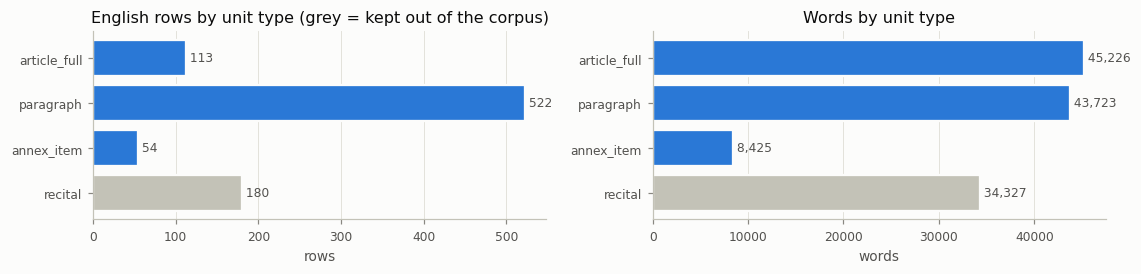

In [ ]:
ROWS = load_act()
print(f"english rows: {len(ROWS)} | snapshot {ROWS.snapshot_version.iloc[0]} | celex {ROWS.celex.iloc[0]}")
unit_tab = ROWS.groupby("chunk_type").agg(rows=("id", "size"), words=("text", lambda s: int(s.str.split().str.len().sum())))
unit_tab["in_corpus"] = ["no, recitals are not binding" if t == "recital" else "yes" for t in unit_tab.index]
display(unit_tab)
order = [t for t in ("article_full", "paragraph", "annex_item", "recital") if t in unit_tab.index]
fig, ax = plt.subplots(1, 2, figsize=(10.5, 2.6))
for a, col in zip(ax, ("rows", "words")):
    vals = unit_tab.reindex(order)[col].values
    a.barh(range(len(order)), vals, color=[BASE if t == "recital" else PAL[0] for t in order], edgecolor=SURFACE, linewidth=1.5)
    a.set_yticks(range(len(order)), order)
    for y, v in enumerate(vals):
        a.text(v, y, f" {int(v):,}", va="center", fontsize=8, color=INK2)
    a.invert_yaxis(); a.grid(axis="y", visible=False); a.set_xlabel(col)
ax[0].set_title("English rows by unit type (grey = kept out of the corpus)")
ax[1].set_title("Words by unit type")
finish(fig, "a_dataset_units")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הדאטהסט: 869 שורות באנגלית, מתמונת מצב של 20 ביולי 2026 (CELEX 32024R1689):</p>
<ul>
<li>הקורפוס נבנה מ-⁠113 הסעיפים המלאים ומ-⁠54 פריטי הנספחים</li>
<li>522 הפסקאות הן טקסט הסעיפים מחולק, ולכן כמעט אותו מספר מילים, 43,723 מול 45,226; הן משמשות את ה-⁠chunking המבני</li>
<li>180 סעיפי המבוא, 34,327 מילים, נשארים בחוץ, כי אינם מחייבים משפטית</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>build_docs: סעיף הוא מסמך, art-N; נספח הוא מסמך אחד שמאחד את פריטיו, anx-III, עם הכותרת פעם אחת. נשמרים פרק, תחולה והפניות.</p>
</div>

In [ ]:
def build_docs(rows):
    docs = []
    for _, r in rows[rows.chunk_type == "article_full"].sort_values("article_no").iterrows():
        n = int(r.article_no)
        docs.append(dict(doc_id=f"art-{n}", kind="article", number=n, title=r.text.split("\n", 1)[0].strip(),
                         chapter=(int(r.chapter_no) if pd.notna(r.chapter_no) else None), effective_from=str(r.effective_from),
                         refs=[int(x) for x in r.references_articles], text=r.text))
    roman = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5, "VI": 6, "VII": 7, "VIII": 8, "IX": 9, "X": 10, "XI": 11, "XII": 12, "XIII": 13}
    ann = rows[rows.chunk_type == "annex_item"].copy()
    ann["sec"] = ann.annex_section.astype(str).str.extract(r"(\d+)")[0].astype(int)
    for annex, grp in sorted(ann.groupby("annex_no"), key=lambda kv: roman[kv[0]]):
        grp = grp.sort_values("sec")
        title = grp.text.iloc[0].split("\n", 1)[0].strip()
        parts = [t.split("\n", 1)[1].strip() if "\n" in t else t for t in grp.text]
        docs.append(dict(doc_id=f"anx-{annex}", kind="annex", number=roman[annex], title=title, chapter=None,
                         effective_from=str(grp.effective_from.iloc[0]), refs=sorted({int(x) for v in grp.references_articles for x in (v if v is not None else [])}),
                         text=title + "\n\n" + "\n\n".join(parts)))
    return docs

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בניית המסמכים ושמירתם ל-⁠corpus_aiact.jsonl. טבלאות: סיכום ואורך לפי סוג; גרף: התפלגות האורך ועשרת הארוכים מול חלון של 200 מילים.</p>
</div>

,value
n_docs,126
total_words,53130
median_words,307.5
by_kind,"article: 113, annex: 13"
by_effective_from,"2026-08-02: 93, 2025-08-02: 28, 2025-02-02: 5"


,count,mean,50%,min,max
kind,,,,,
annex,13.0,608.0,452.0,112.0,1265.0
article,113.0,400.0,306.0,32.0,2623.0


,doc_id,words,title
2,art-3,2623,Article 3 — Definitions
4,art-5,1762,Article 5 — Prohibited AI practices
56,art-57,1338,Article 57 — AI regulatory sandboxes
115,anx-III,1265,Annex III — High-risk AI systems referred to in Article 6(2)
119,anx-VII,1246,Annex VII — Conformity based on an assessment of the quality managemen


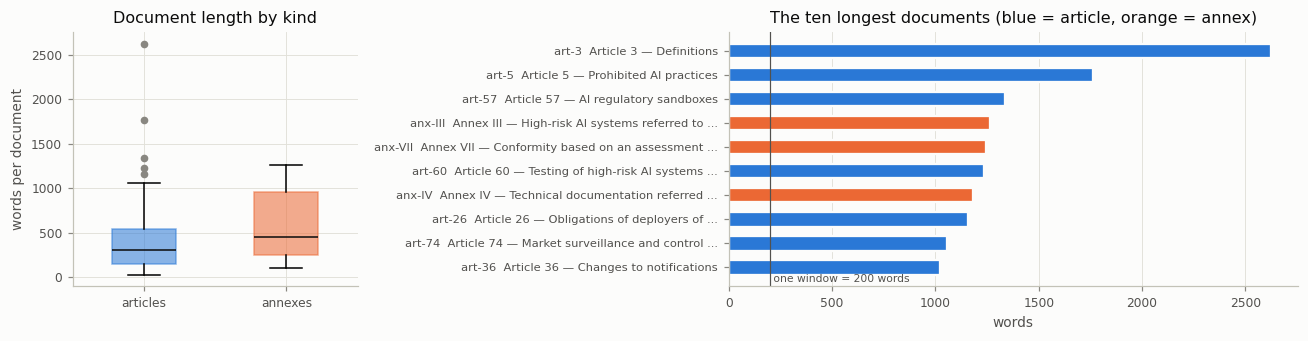

In [ ]:
DOCS = build_docs(ROWS)
DOC = {d["doc_id"]: d for d in DOCS}
for d in DOCS:
    d["n_words"] = len(d["text"].split())
corpus_tab = pd.DataFrame([dict(doc_id=d["doc_id"], kind=d["kind"], chapter=d["chapter"], effective_from=d["effective_from"], words=d["n_words"], title=d["title"][:70]) for d in DOCS])
RESULTS["corpus"] = dict(n_docs=len(DOCS), total_words=int(corpus_tab.words.sum()), median_words=float(corpus_tab.words.median()),
                         by_kind=corpus_tab.kind.value_counts().to_dict(), by_effective_from=corpus_tab.effective_from.value_counts().to_dict())
with open(os.path.join(RUN_DIR, "corpus_aiact.jsonl"), "w", encoding="utf-8") as f:
    for d in DOCS:
        f.write(json.dumps(d, ensure_ascii=False) + "\n")
display(pd.Series({k: (", ".join(f"{a}: {b}" for a, b in v.items()) if isinstance(v, dict) else v) for k, v in RESULTS["corpus"].items()}, name="value").to_frame())
display(corpus_tab.groupby("kind").words.describe()[["count", "mean", "50%", "min", "max"]].round(0))
display(corpus_tab.nlargest(5, "words")[["doc_id", "words", "title"]])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2), gridspec_kw=dict(width_ratios=[0.8, 1.6]))
bp = ax[0].boxplot([corpus_tab[corpus_tab.kind == k].words for k in ("article", "annex")], patch_artist=True, widths=0.45,
                   medianprops=dict(color=INK), flierprops=dict(markersize=4, markerfacecolor=MUTED, markeredgecolor=MUTED))
for patch, c in zip(bp["boxes"], (PAL[0], PAL[1])):
    patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor(c)
ax[0].set_xticks([1, 2], ["articles", "annexes"]); ax[0].set_ylabel("words per document"); ax[0].set_title("Document length by kind")
top10 = corpus_tab.nlargest(10, "words")
ax[1].barh(range(len(top10)), top10.words, color=[PAL[0] if k == "article" else PAL[1] for k in top10.kind], edgecolor=SURFACE, linewidth=1.5, height=0.6)
ax[1].set_yticks(range(len(top10)), [f"{d}  {t if len(t) <= 46 else t[:t.rfind(' ', 0, 46)] + ' ...'}" for d, t in zip(top10.doc_id, top10.title)], fontsize=7.5)
ax[1].invert_yaxis(); ax[1].grid(axis="y", visible=False); ax[1].set_xlabel("words")
ax[1].axvline(CFG["chunk_words"], color=INK2, linewidth=0.8); ax[1].text(CFG["chunk_words"], 9.6, f" one window = {CFG['chunk_words']} words", fontsize=7, color=INK2)
ax[1].set_title("The ten longest documents (blue = article, orange = annex)")
finish(fig, "a_long_documents")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>126 מסמכים (113 סעיפים, 13 נספחים), 53,130 מילים, בתוך הטווח של 50–300 מסמכים שבהנחיות:</p>
<ul>
<li>אורך — חציון 307.5 מילים עם זנב ארוך: סעיף 3 (הגדרות) 2,623 מילים, סעיף 5 (פרקטיקות אסורות) 1,762</li>
<li>נספח חציוני ארוך מסעיף חציוני, 452 מול 306</li>
<li>תחולה לפי סעיף 113 — 93 מסמכים חלים מ-⁠2.8.2026, 28 מ-⁠2.8.2025, 5 מ-⁠2.2.2025</li>
<li>כל אחד מעשרת הארוכים ארוך לפחות פי 5 מחלון של 200 מילים, ולכן מתפצל לחמישה חלונות ויותר</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרפים: אורכי המסמכים, סעיפים לפרק ומסמכים לפי מועד התחולה, שרלוונטי ל-⁠Q03; טבלת פרקים: סעיפים, מילים, חציון אורך ומועד נפוץ.</p>
</div>

,articles,words,median_words,applies_from
chapter,,,,
1,4,3632,463.5,2025-02-02
2,1,1762,1762.0,2025-02-02
3,44,16919,307.0,2026-08-02
4,1,720,720.0,2026-08-02
5,6,2636,455.0,2025-08-02
6,7,4615,669.0,2026-08-02
7,7,2637,458.0,2025-08-02
8,1,363,363.0,2026-08-02
9,23,7210,281.0,2026-08-02


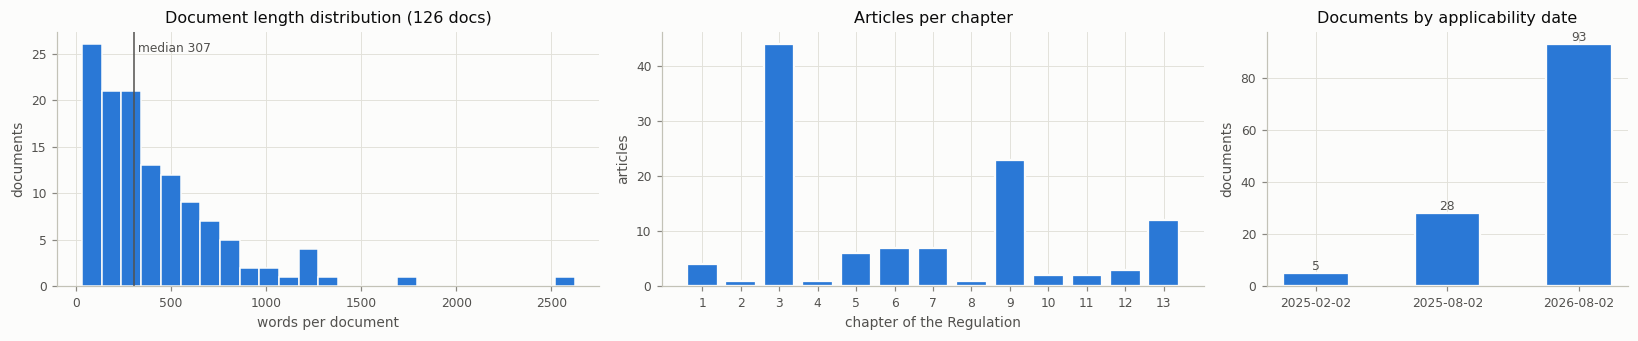

In [ ]:
chap = corpus_tab[corpus_tab.kind == "article"].groupby("chapter").agg(articles=("doc_id", "size"), words=("words", "sum"),
                                                                       median_words=("words", "median"), applies_from=("effective_from", lambda s: s.mode().iloc[0]))
chap.index = chap.index.astype(int)
display(chap)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2), gridspec_kw=dict(width_ratios=[1.2, 1.2, 0.8]))
ax[0].hist(corpus_tab.words, bins=25, color=PAL[0], edgecolor=SURFACE, linewidth=1)
ax[0].axvline(corpus_tab.words.median(), color=INK2, linewidth=1)
ax[0].text(corpus_tab.words.median(), ax[0].get_ylim()[1] * 0.92, f" median {int(corpus_tab.words.median())}", fontsize=8, color=INK2)
ax[0].set_xlabel("words per document"); ax[0].set_ylabel("documents"); ax[0].set_title(f"Document length distribution ({len(corpus_tab)} docs)")
ax[1].bar(chap.index, chap.articles, color=PAL[0], edgecolor=SURFACE, linewidth=1.5)
ax[1].set_xticks(chap.index); ax[1].set_xlabel("chapter of the Regulation"); ax[1].set_ylabel("articles"); ax[1].set_title("Articles per chapter")
eff = corpus_tab.effective_from.value_counts().sort_index()
ax[2].bar(range(len(eff)), eff.values, color=PAL[0], edgecolor=SURFACE, linewidth=1.5, width=0.5)
ax[2].set_xticks(range(len(eff)), eff.index)
for x_, v in enumerate(eff.values):
    ax[2].text(x_, v, str(v), ha="center", va="bottom", fontsize=8, color=INK2)
ax[2].set_ylabel("documents"); ax[2].set_title("Documents by applicability date")
finish(fig, "a_corpus_overview")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<ul>
<li>אורך — התפלגות מוטה: חציון 307.5 מילים וקומץ מסמכים ארוכים מאוד, ולכן ה-⁠chunking הוא שאלה אמיתית</li>
<li>פרק 3 (מערכות בסיכון גבוה): 44 מתוך 113 סעיפים, 16,919 מילים, כשליש מהקורפוס; פרק 9 (פיקוח שוק): 23 סעיפים</li>
<li>פרקים 2, 4 ו-⁠8: סעיף אחד כל אחד; פרק 13: 12 סעיפים קצרים, חציון 74.5 מילים</li>
<li>תחולה, לפי המועד הנפוץ בכל פרק — פרקים 1–2 מפברואר 2025, פרקים 5, 7 ו-⁠12 מאוגוסט 2025, השאר מאוגוסט 2026; חריגים לפי סעיף 113: פרק 3 חלק 4 וסעיף 78 מאוגוסט 2025, וסעיף 101 מאוגוסט 2026</li>
<li>מכאן התשובה ל-⁠Q03: פרק 5 (GPAI) חל מ-⁠2.8.2025, וסעיף 113 מציין זאת דרך מספר הפרק בלבד</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>split_words: חותכת טקסט לחלונות של מילים בחפיפה; ב-⁠chunking המבני רק פסקה או פריט נספח מעל 250 מילים, ובחלונות את כל הטקסט.</p>
</div>

In [ ]:
def split_words(words, size, overlap):
    step = max(size - overlap, 1)
    out = []
    for s in range(0, max(len(words), 1), step):
        win = words[s:s + size]
        if not win:
            break
        out.append(" ".join(win))
        if s + size >= len(words):
            break
    return out

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>chunk_structural: יחידה לפסקה ופריט נספח, חלונות מעל 250 מילים; בכל chunk כותרת הסעיף או הנספח, גרסה פשוטה של Contextual Retrieval, ותווית ציטוט.</p>
</div>

In [ ]:
def chunk_structural(rows):
    out = []
    for _, r in rows[rows.chunk_type == "paragraph"].iterrows():
        doc_id = f"art-{int(r.article_no)}"
        for j, part in enumerate(split_words(r.text.split(), CFG["struct_max_words"], CFG["struct_overlap"])):
            out.append(dict(chunk_id=f"{r.structure_path}#{j}", doc_id=doc_id, title=DOC[doc_id]["title"], loc=r.citation_label,
                            text=f"{DOC[doc_id]['title']}\n{part}"))
    for _, r in rows[rows.chunk_type == "annex_item"].iterrows():
        doc_id = f"anx-{r.annex_no}"
        body = r.text.split("\n", 1)[1].strip() if "\n" in r.text else r.text
        for j, part in enumerate(split_words(body.split(), CFG["struct_max_words"], CFG["struct_overlap"])):
            out.append(dict(chunk_id=f"{r.structure_path}#{j}", doc_id=doc_id, title=DOC[doc_id]["title"], loc=r.citation_label,
                            text=f"{DOC[doc_id]['title']}\n{part}"))
    return out

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>chunk_window: חלונות של 200 מילים בחפיפה של 50, chunking בחלונות כמו בהרצאה 7. גם כאן מצורפת הכותרת, ולכן ההבדל מהמבני הוא היישור לפסקאות, ובעקבותיו גם אורך ה-⁠chunk.</p>
</div>

In [ ]:
def chunk_window(docs):
    out = []
    for d in docs:
        for j, part in enumerate(split_words(d["text"].split(), CFG["chunk_words"], CFG["chunk_overlap"])):
            out.append(dict(chunk_id=f"{d['doc_id']}/w{j}", doc_id=d["doc_id"], title=d["title"], loc=f"window {j}",
                            text=part if j == 0 else f"{d['title']}\n{part}"))
    return out

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בניית ה-⁠chunks בשתי האסטרטגיות: טבלת השוואה, גרף של התפלגות האורכים, ודוגמה ל-⁠chunk מבני אחד.</p>
</div>

,n_chunks,mean_words,max_words,max_words_cfg,overlap,size
structural,625.0,95.4,272.0,250.0,50.0,-
window,379.0,179.8,222.0,-,50.0,200.0


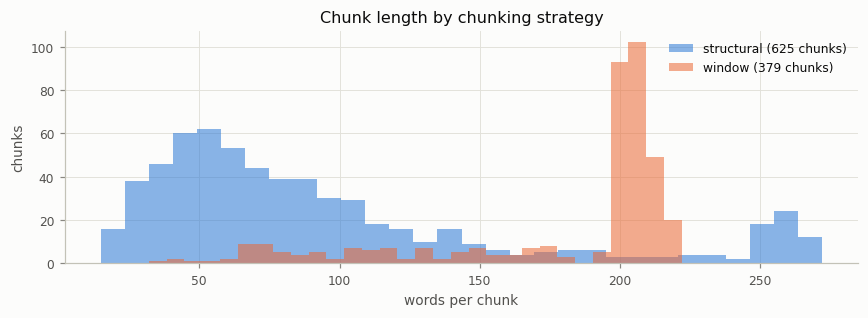

example: art:5/par:8#0 | Art. 5(8) AI Act | Article 5 — Prohibited AI practices
This Article shall not affect the prohibitions that apply where an AI practice infringes other Union law.


In [ ]:
CHUNKS = {"structural": chunk_structural(ROWS), "window": chunk_window(DOCS)}
RESULTS["retrieval"]["chunking"] = {name: dict(n_chunks=len(ch), mean_words=round(float(np.mean([len(c["text"].split()) for c in ch])), 1),
                                              max_words=max(len(c["text"].split()) for c in ch)) for name, ch in CHUNKS.items()}
RESULTS["retrieval"]["chunking"]["structural"].update(max_words_cfg=CFG["struct_max_words"], overlap=CFG["struct_overlap"])
RESULTS["retrieval"]["chunking"]["window"].update(size=CFG["chunk_words"], overlap=CFG["chunk_overlap"])
display(pd.DataFrame(RESULTS["retrieval"]["chunking"]).T.fillna("-"))
fig, ax = plt.subplots(figsize=(8, 3))
for name, ch in CHUNKS.items():
    ax.hist([len(c["text"].split()) for c in ch], bins=30, alpha=0.55, color=COLOR[name], label=f"{name} ({len(ch)} chunks)")
ax.set_xlabel("words per chunk"); ax.set_ylabel("chunks"); ax.set_title("Chunk length by chunking strategy"); ax.legend()
finish(fig, "a_chunk_lengths")
print("example:", CHUNKS["structural"][40]["chunk_id"], "|", CHUNKS["structural"][40]["loc"], "|", CHUNKS["structural"][40]["text"][:160])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<ul>
<li>מבני — 625 chunks, ממוצע 95 מילים, מקסימום 272; חלונות — 379 chunks, ממוצע 180, מקסימום 222</li>
<li>המבני מייצר פי 1.65 יחידות, קצרות פי 1.9</li>
<li>בגרף החלונות מרוכזים מעט מעל 200 מילים, והמבני רובו מתחת ל-⁠100, עם גבעה סביב 250 מהפסקאות הארוכות שנחתכו</li>
<li>המקסימום עובר את הגבולות, 272 מול 250 ו-⁠222 מול 200, כי כותרת הסעיף נוספת לכל chunk</li>
<li>הדוגמה, Art. 5(8), היא פסקה של משפט אחד; בחלונות היא הייתה נבלעת יחד עם פסקאות שכנות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>tokenize: טוקניזציה ל-⁠BM25, רצפי אותיות וספרות באותיות קטנות, בלי stemming; מספרי סעיפים ומונחים נשארים טוקנים מדויקים.</p>
</div>

In [ ]:
def tokenize(t):
    return re.findall(r"\w+", t.lower())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>build_index: בונה אינדקס לכל אסטרטגיית chunking, הטמעות e5 מנורמלות עם הקידומת passage, כמו באימון, ו-⁠BM25 על אותם&nbsp;chunks.</p>
</div>

In [ ]:
def build_index(chunks, name):
    t0 = time.perf_counter()
    emb = EMBEDDER.encode(["passage: " + c["text"] for c in chunks], batch_size=64, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False)
    bm25 = BM25Okapi([tokenize(c["text"]) for c in chunks])
    index = SimpleNamespace(chunks=chunks, name=name, emb=emb, bm25=bm25, build_s=round(time.perf_counter() - t0, 1))
    print(f"index {name}: {len(chunks)} chunks, dim {emb.shape[1]}, built in {index.build_s}s")
    return index

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>search_dense: שלב המועמדים בדמיון סמנטי; השאילתה מוטמעת עם הקידומת query, ומכפלה פנימית של וקטורים מנורמלים היא קוסינוס.</p>
</div>

In [ ]:
def search_dense(index, q, k):
    qv = EMBEDDER.encode(["query: " + q], normalize_embeddings=True, convert_to_numpy=True)[0]
    s = index.emb @ qv
    idx = np.argsort(-s)[:k]
    return [(int(i), float(s[i])) for i in idx]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>search_bm25: שלב המועמדים במילות מפתח; ניקוד BM25 של טוקני השאילתה מול כל chunk, ומוחזרים k הגבוהים.</p>
</div>

In [ ]:
def search_bm25(index, q, k):
    s = index.bm25.get_scores(tokenize(q))
    idx = np.argsort(-s)[:k]
    return [(int(i), float(s[i])) for i in idx]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>search_hybrid: מיזוג ב-⁠RRF; כל chunk מקבל מכל רשימה 1 חלקי הסכום של 60 והדירוג שלו, ולכן מיותר נרמול min-max שבמחברת הרצאה&nbsp;7.</p>
</div>

In [ ]:
def search_hybrid(index, q, k):
    fused = defaultdict(float)
    for ranked in (search_dense(index, q, k), search_bm25(index, q, k)):
        for r, (i, _) in enumerate(ranked, 1):
            fused[i] += 1.0 / (CFG["rrf_k"] + r)
    return sorted(fused.items(), key=lambda x: -x[1])[:k]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת מודל ההטמעות, e5-base-v2 עם עד 512 טוקנים, ובניית אינדקס לכל אסטרטגיית chunking. האינדקס המבני, INDEX, הוא ברירת המחדל.</p>
</div>

In [ ]:
EMBEDDER = SentenceTransformer(EMBED_MODEL, device=DEVICE)
EMBEDDER.max_seq_length = 512
INDEXES = {name: build_index(ch, name) for name, ch in CHUNKS.items()}
INDEX = INDEXES["structural"]

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/67.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

index structural: 625 chunks, dim 768, built in 4.0s
index window: 379 chunks, dim 768, built in 3.4s


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני האינדקסים, 625 ו-⁠379 chunks, נבנו ב-⁠4.0 ו-⁠3.4 שניות. הקורפוס קטן, ולכן חיפוש dense הוא מכפלת מטריצות אחת, בלי FAISS או אינדקס קירוב.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>retrieve: מועמדים ואז reranking. ה-⁠cross-encoder קורא שאילתה ומועמד יחד, מדויק ויקר, ורץ רק על 20 המועמדים; הם מוחזרים, למדידת&nbsp;recall.</p>
</div>

In [ ]:
def retrieve(q, index=None, mode="hybrid", rerank=True, k_cand=None, k=None):
    index = index or INDEX
    k_cand, k = k_cand or CFG["k_candidates"], k or CFG["k_final"]
    cands = {"dense": search_dense, "bm25": search_bm25, "hybrid": search_hybrid}[mode](index, q, k_cand)
    if rerank and cands:
        scores = RERANKER.predict([(q, index.chunks[i]["text"]) for i, _ in cands], show_progress_bar=False)
        order = np.argsort(-np.asarray(scores))
        cands = [(cands[j][0], float(scores[j])) for j in order]
    top = [dict(index.chunks[i], score=round(s, 4)) for i, s in cands[:k]]
    return top, [i for i, _ in cands]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>passage: מעצבת קטע כראיה, מזהה ותווית משפטית בסוגריים מרובעים ואז עד 1,500 תווים; אותו פורמט ב-⁠RAG, בכלי החיפוש ובשופט.</p>
</div>

In [ ]:
def passage(c):
    return f"[{c['doc_id']} | {c['loc']}] {c['text'][:CFG['evidence_chars']]}"

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>format_context: מחברת את הקטעים בסדר הפוך, כך שהקטע המוביל צמוד לשאלה, כי במטלה 1 עובדה באמצע נכשלה מ-⁠8K טוקנים ב-⁠0.5B; כאן ההקשר כ-⁠1,000 טוקנים.</p>
</div>

In [ ]:
def format_context(top):
    return "\n\n".join(passage(c) for c in reversed(top))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת ה-⁠reranker והדגמה על שאלה אחת: טבלת חמשת הקטעים הסופיים עם ציון ה-⁠cross-encoder, וגרף של הציונים.</p>
</div>

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

,doc,location,rerank_score,text
rank,,,,
1,art-99,Art. 99(3) AI Act,0.9293,Non-compliance with the prohibition of the AI practices referred to in Article 5 shall...
2,art-100,Art. 100(2) AI Act,0.8952,Non-compliance with the prohibition of the AI practices referred to in Article 5 shall...
3,art-5,Art. 5(1) AI Act,0.6276,of certain natural persons or groups of persons that is unjustified or disproportionat...
4,art-5,Art. 5(1) AI Act,0.2626,"The following AI practices shall be prohibited: (a) the placing on the market, the put..."
5,art-101,Art. 101(1) AI Act,0.2352,The Commission may impose on providers of general-purpose AI models fines not exceedin...


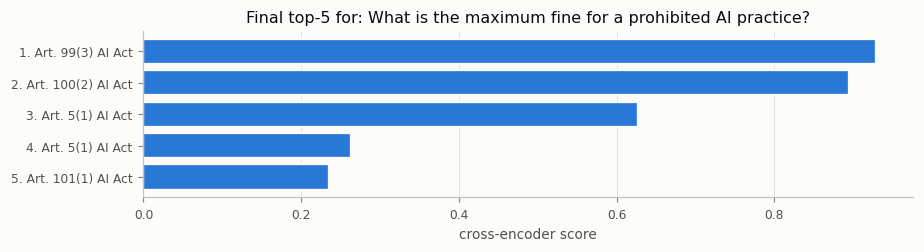

In [ ]:
RERANKER = CrossEncoder(RERANK_MODEL, device=DEVICE, max_length=512)
demo_q = "What is the maximum fine for a prohibited AI practice?"
top, _ = retrieve(demo_q)
demo = pd.DataFrame([dict(rank=i + 1, doc=c["doc_id"], location=c["loc"], rerank_score=c["score"], text=c["text"].split(chr(10), 1)[-1][:90])
                     for i, c in enumerate(top)]).set_index("rank")
display(demo)
fig, ax = plt.subplots(figsize=(8.5, 2.4))
ax.barh(range(len(demo)), demo.rerank_score, color=PAL[0], edgecolor=SURFACE, linewidth=1.5)
ax.set_yticks(range(len(demo)), [f"{i}. {loc}" for i, loc in zip(demo.index, demo.location)])
ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlabel("cross-encoder score")
ax.set_title(f"Final top-{len(demo)} for: {demo_q}")
finish(fig, "a_rerank_demo")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>לשאלת הקנס המרבי לפרקטיקה אסורה, ה-⁠cross-encoder מדרג ראשון את Art. 99(3), שבו התשובה, עם 0.93, ושני את Art. 100(2) עם 0.90; אחריהם קפיצה ל-⁠0.63 ומטה. Art. 100(2) רלוונטי רק חלקית, ולכן מסיח: אותו נוסח, "non-compliance with the prohibition of the AI practices referred to in Article 5", עם קנס של 1.5 מיליון למוסדות האיחוד. הפער הקטן בין השניים הוא הסיבה שהמודל צריך לקרוא את ההקשר ולא להעתיק את הקטע הראשון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>18 השאילתות: טבלה, וגרף לפי מקור ומספר מסמכי זהב, שנקבעו מראש: 4 מהדאטהסט, 2 מ-⁠QA חיצוני ו-⁠12 מקריאת החוק; כולן אומתו מול הטקסט.</p>
</div>

18 fixed queries


,id,query,gold,source
0,Q01,What is a 'provider' under the AI Act?,art-3,dataset gold
1,Q02,Is an AI tool that screens CVs considered high-risk?,"anx-III, art-6",dataset gold
2,Q03,When do the obligations for general-purpose AI models start to apply?,art-113,dataset gold
3,Q04,Does the AI Act apply to free and open-source AI models?,art-2,dataset gold
4,Q05,Which AI practices are prohibited by the Regulation?,art-5,own
5,Q06,What is the maximum administrative fine for using a prohibited AI practice?,art-99,external QA
6,Q07,Above what amount of training compute is a general-purpose AI model presumed to have s...,art-51,own
7,Q08,Can an employer use AI to read the emotions of its employees?,art-5,"own, paraphrase"
8,Q09,May the police use live facial recognition in public streets?,art-5,"own, paraphrase"
9,Q10,Must people be told that they are talking to a chatbot?,art-50,"own, paraphrase"


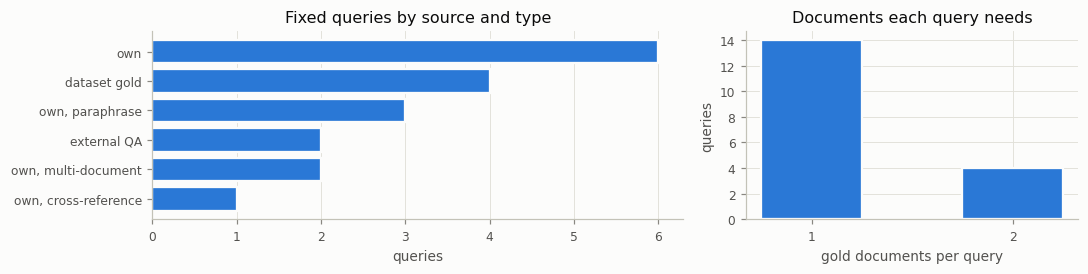

In [ ]:
QUERIES_RAW = [
    ("Q01", "What is a 'provider' under the AI Act?", ["art-3"], "dataset gold"),
    ("Q02", "Is an AI tool that screens CVs considered high-risk?", ["anx-III", "art-6"], "dataset gold"),
    ("Q03", "When do the obligations for general-purpose AI models start to apply?", ["art-113"], "dataset gold"),
    ("Q04", "Does the AI Act apply to free and open-source AI models?", ["art-2"], "dataset gold"),
    ("Q05", "Which AI practices are prohibited by the Regulation?", ["art-5"], "own"),
    ("Q06", "What is the maximum administrative fine for using a prohibited AI practice?", ["art-99"], "external QA"),
    ("Q07", "Above what amount of training compute is a general-purpose AI model presumed to have systemic risk?", ["art-51"], "own"),
    ("Q08", "Can an employer use AI to read the emotions of its employees?", ["art-5"], "own, paraphrase"),
    ("Q09", "May the police use live facial recognition in public streets?", ["art-5"], "own, paraphrase"),
    ("Q10", "Must people be told that they are talking to a chatbot?", ["art-50"], "own, paraphrase"),
    ("Q11", "What must the risk management system of a high-risk AI system include?", ["art-9"], "own"),
    ("Q12", "When is a system listed in Annex III nevertheless not considered high-risk?", ["art-6"], "own, cross-reference"),
    ("Q13", "What are the obligations of deployers of high-risk AI systems?", ["art-26"], "own"),
    ("Q14", "What is an AI regulatory sandbox and who establishes them?", ["art-3", "art-57"], "own, multi-document"),
    ("Q15", "What are the obligations of providers of general-purpose AI models?", ["art-53"], "external QA"),
    ("Q16", "For how long must providers keep the technical documentation of a high-risk AI system, and deployers its logs?", ["art-18", "art-26"], "own, multi-document"),
    ("Q17", "What must the technical documentation of a high-risk AI system contain?", ["art-11", "anx-IV"], "own"),
    ("Q18", "Who can be fined for supplying incorrect information to the authorities, and how much?", ["art-99"], "own"),
]
QUERIES = [dict(id=qid, q=q, gold=gold, source=src) for qid, q, gold, src in QUERIES_RAW]
assert all(g in DOC for q in QUERIES for g in q["gold"])
if SMOKE:
    QUERIES = QUERIES[:4]
ITEM_TEXT = {q["id"]: q["q"] for q in QUERIES}
ITEM_GOLD = {q["id"]: set(q["gold"]) for q in QUERIES}
print(len(QUERIES), "fixed queries")
display(pd.DataFrame([dict(id=q["id"], query=q["q"], gold=", ".join(q["gold"]), source=q["source"]) for q in QUERIES]))
src_counts = pd.Series([q["source"] for q in QUERIES]).value_counts()
ng = pd.Series([len(q["gold"]) for q in QUERIES]).value_counts().sort_index()
fig, ax = plt.subplots(1, 2, figsize=(10, 2.6), gridspec_kw=dict(width_ratios=[1.6, 1]))
ax[0].barh(range(len(src_counts)), src_counts.values, color=PAL[0], edgecolor=SURFACE, linewidth=1.5)
ax[0].set_yticks(range(len(src_counts)), src_counts.index); ax[0].invert_yaxis(); ax[0].grid(axis="y", visible=False)
ax[0].set_xlabel("queries"); ax[0].set_title("Fixed queries by source and type")
ax[1].bar([str(i) for i in ng.index], ng.values, color=PAL[0], edgecolor=SURFACE, linewidth=1.5, width=0.5)
ax[1].set_xlabel("gold documents per query"); ax[1].set_ylabel("queries"); ax[1].set_title("Documents each query needs")
ax[1].yaxis.set_major_locator(MaxNLocator(integer=True))
finish(fig, "a_queries")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>18 שאילתות: 4 זהב מהדאטהסט, 2 QA חיצוני, 12 שכתבתי (3 בניסוח עקיף, 2 רב-מסמכיות, 1 עם הפניה צולבת). 4 עם שני מסמכי זהב: שתי הרב-מסמכיות, ו-⁠Q02 ו-⁠Q17, שבהן סעיף ונספח. ב-⁠14 האחרות precision@5 חסום ב-⁠0.2.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>precision_at_k: הראשון מבין מדדי האחזור כאן, כולם ברמת המסמך: החלק של מסמכי הזהב מבין k שהוחזרו.</p>
</div>

In [ ]:
def precision_at_k(hits):
    return float(np.mean(hits)) if hits else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>recall_at_k: החלק של מסמכי הזהב שהופיעו בין k שהוחזרו; עם מסמך זהב אחד, 0 או&nbsp;1.</p>
</div>

In [ ]:
def recall_at_k(top_docs, gold):
    return len(set(gold) & set(top_docs)) / len(gold)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>reciprocal_rank: אחד חלקי הדירוג של מסמך הזהב הראשון, ואפס אם אין כזה. הממוצע על השאילתות הוא&nbsp;MRR.</p>
</div>

In [ ]:
def reciprocal_rank(hits):
    first = next((r for r, h in enumerate(hits, 1) if h), None)
    return 1.0 / first if first else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>r_precision: ה-⁠precision ב-⁠R הראשונים, כש-⁠R מספר מסמכי הזהב; במסמך אחד, האם הוא ראשון. בניגוד ל-⁠precision@5 החסום, מבחין בין תנאים.</p>
</div>

In [ ]:
def r_precision(hits, n_gold):
    top = hits[:max(n_gold, 1)]
    return float(np.mean(top)) if top else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ndcg_at_k: ה-⁠DCG של הרשימה שהוחזרה, חלקי ה-⁠DCG של רשימה מושלמת שבה כל מסמכי הזהב ראשונים; רלוונטיות בינארית.</p>
</div>

In [ ]:
def ndcg_at_k(hits, n_gold):
    dcg = sum(h / math.log2(r + 1) for r, h in enumerate(hits, 1))
    ideal = sum(1.0 / math.log2(r + 1) for r in range(1, min(n_gold, len(hits)) + 1))
    return dcg / ideal if ideal else 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>eval_retrieval: מודדת תנאי ברמת המסמך: מ-⁠20 קטעים נלקחים 5 מסמכים שונים, כדי שכפילויות לא ינפחו את ה-⁠precision; ביצירה הן נשארות.</p>
</div>

In [ ]:
def eval_retrieval(index, mode, rerank):
    rows = []
    for q in QUERIES:
        top, cand_idx = retrieve(q["q"], index, mode, rerank, k=CFG["k_final"] * 4)
        seen, uniq = set(), []
        for c in top:
            if c["doc_id"] not in seen:
                seen.add(c["doc_id"])
                uniq.append(c)
        top_docs = [c["doc_id"] for c in uniq[:CFG["k_final"]]]
        gold = set(q["gold"])
        hits = [d in gold for d in top_docs]
        cand_docs = {index.chunks[i]["doc_id"] for i in cand_idx}
        rows.append(dict(id=q["id"], p_at_k=precision_at_k(hits), r_prec=r_precision(hits, len(gold)), r_at_k=recall_at_k(top_docs, gold), rr=reciprocal_rank(hits),
                         ndcg=ndcg_at_k(hits, len(gold)), recall_cand=len(gold & cand_docs) / len(gold), top_docs=top_docs))
    return pd.DataFrame(rows)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הרצת 12 התנאים וטבלת הממוצעים. zero_recall: שאילתות שאף מסמך זהב שלהן לא נכנס ל-⁠20 המועמדים, כשל שה-⁠reranking לא מתקן.</p>
</div>

In [ ]:
conds, PER_QUERY = [], {}
for name, idx in INDEXES.items():
    for mode in ("bm25", "dense", "hybrid"):
        for rerank in (False, True):
            t0 = time.perf_counter()
            d = eval_retrieval(idx, mode, rerank)
            cond = f"{name}/{mode}/{'rerank' if rerank else 'no-rerank'}"
            PER_QUERY[cond] = d
            conds.append(dict(condition=cond, chunking=name, mode=mode, rerank=rerank, p_at_5=d.p_at_k.mean(), r_prec=d.r_prec.mean(), r_at_5=d.r_at_k.mean(),
                              mrr=d.rr.mean(), ndcg_at_5=d.ndcg.mean(), recall_cand=d.recall_cand.mean(), zero_recall=int((d.recall_cand == 0).sum()),
                              sec_per_query=(time.perf_counter() - t0) / len(QUERIES)))
ret_tab = pd.DataFrame(conds).set_index("condition").round(3)
display(ret_tab)
MAIN_COND = "structural/hybrid/rerank"
RESULTS["retrieval"]["conditions"] = ret_tab.to_dict("index")
RESULTS["retrieval"]["per_query_main"] = PER_QUERY[MAIN_COND].drop(columns="top_docs").to_dict("records")

,chunking,mode,rerank,p_at_5,r_prec,r_at_5,mrr,ndcg_at_5,recall_cand,zero_recall,sec_per_query
condition,,,,,,,,,,,
structural/bm25/no-rerank,structural,bm25,False,0.200,0.500,0.833,0.669,0.673,0.917,1,0.002
structural/bm25/rerank,structural,bm25,True,0.211,0.806,0.889,0.907,0.869,0.917,1,0.621
structural/dense/no-rerank,structural,dense,False,0.203,0.556,0.861,0.778,0.760,0.889,1,0.016
structural/dense/rerank,structural,dense,True,0.203,0.806,0.861,0.917,0.859,0.889,1,0.613
structural/hybrid/no-rerank,structural,hybrid,False,0.228,0.667,0.917,0.843,0.827,0.917,1,0.020
structural/hybrid/rerank,structural,hybrid,True,0.217,0.861,0.889,0.944,0.897,0.917,1,0.643
window/bm25/no-rerank,window,bm25,False,0.178,0.528,0.722,0.648,0.643,0.861,2,0.001
window/bm25/rerank,window,bm25,True,0.189,0.639,0.778,0.769,0.738,0.861,2,0.549
window/dense/no-rerank,window,dense,False,0.222,0.667,0.917,0.833,0.831,0.917,1,0.012


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התנאי הראשי (מבני, hybrid, reranking) מוביל בשלושת מדדי הדירוג, MRR 0.944, R-precision 0.861, nDCG@5 0.897, אך בפער של שאילתה אחת לכל היותר מהבא אחריו; ב-⁠recall@5 הוא 0.889, מתחת ל-⁠0.944 של hybrid על חלונות בלי reranking. הגרוע ביותר: BM25 על חלונות בלי reranking, MRR 0.648, nDCG@5 0.643. precision@5 נע רק בין 0.18 ל-⁠0.23. recall המועמדים, 0.86–0.94, הוא תקרת ה-⁠reranker. זמן לשאילתה: עד 0.02 שניות בלי reranking, כ-⁠0.6 איתו.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרפי MRR, R-precision ו-⁠nDCG@5 לפי תנאי ו-⁠chunking, בלי precision@5 החסום; אחריהם טבלה ומפת חום של recall@5 לכל שאילתה ותנאי.</p>
</div>

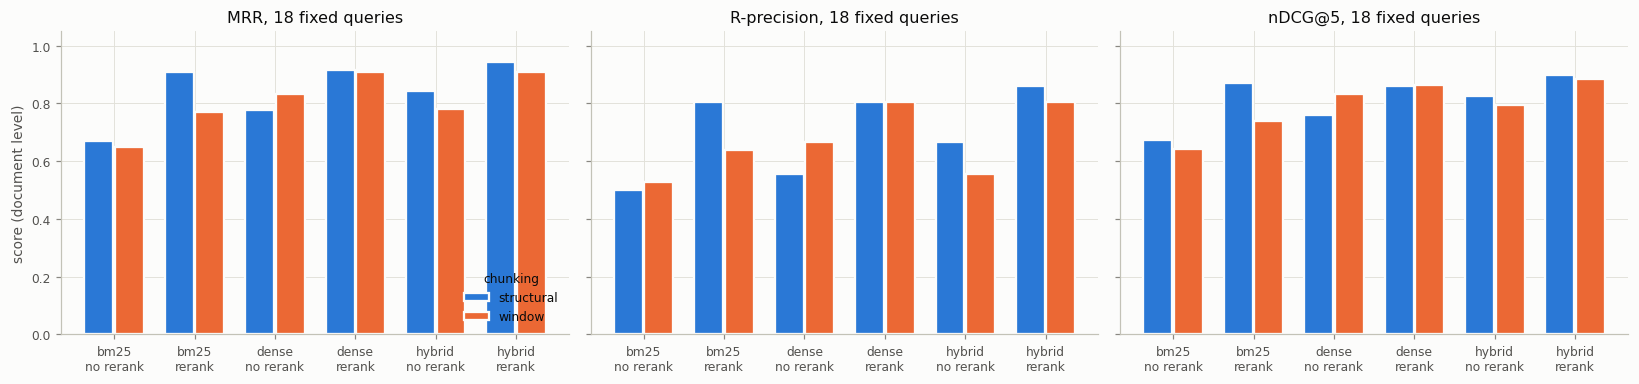

,structural/bm25/no-rerank,structural/bm25/rerank,structural/dense/no-rerank,structural/dense/rerank,structural/hybrid/no-rerank,structural/hybrid/rerank,window/bm25/no-rerank,window/bm25/rerank,window/dense/no-rerank,window/dense/rerank,window/hybrid/no-rerank,window/hybrid/rerank
id,,,,,,,,,,,,
Q01,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
Q02,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1.0,1.0,1.0
Q03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Q04,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Q05,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Q06,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Q07,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Q08,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Q09,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


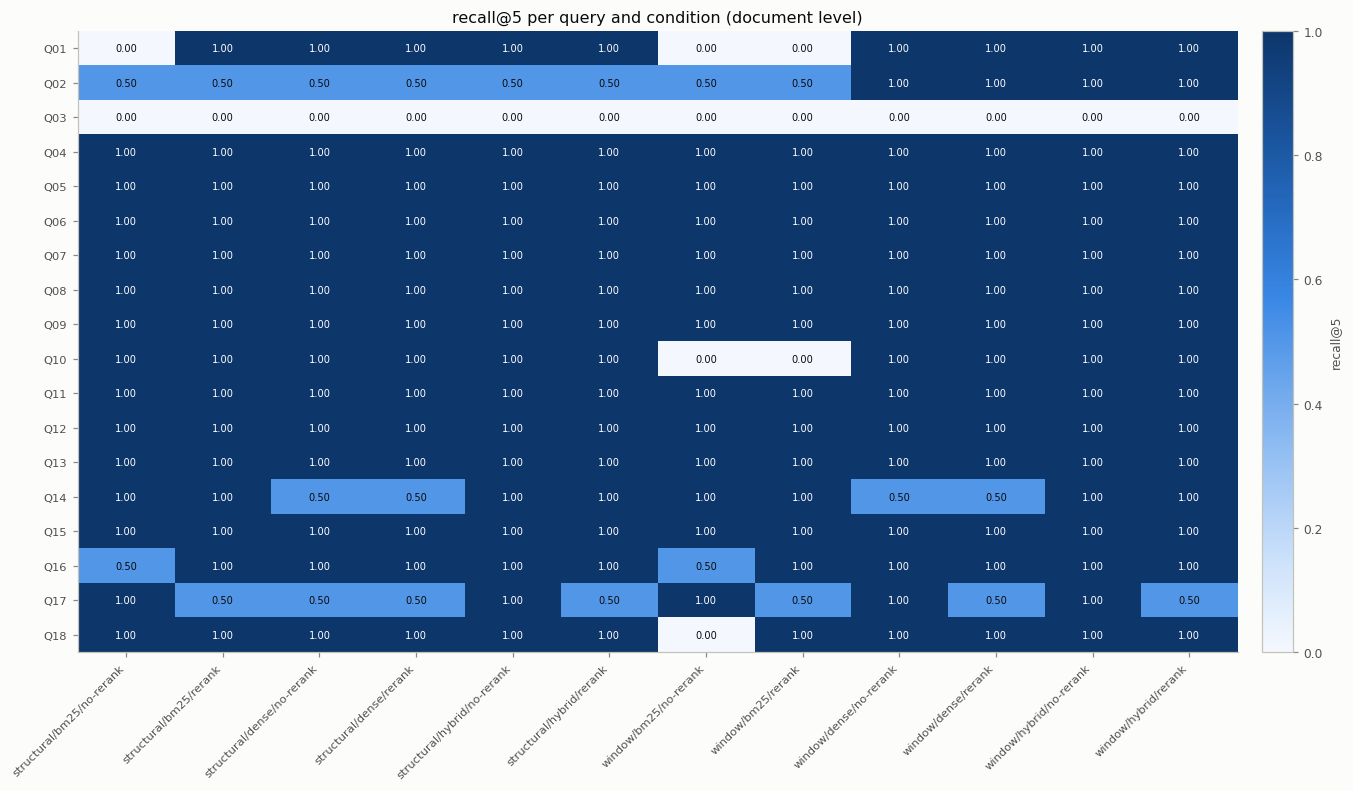

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
setting = [(m, r) for m in ("bm25", "dense", "hybrid") for r in (False, True)]
x = np.arange(len(setting))
for a, metric, pretty in zip(ax, ("mrr", "r_prec", "ndcg_at_5"), ("MRR", "R-precision", "nDCG@5")):
    for j, name in enumerate(INDEXES):
        vals = [ret_tab.loc[f"{name}/{m}/{'rerank' if r else 'no-rerank'}", metric] for m, r in setting]
        a.bar(x + (j - 0.5) * 0.38, vals, width=0.36, color=COLOR[name], label=name, edgecolor=SURFACE, linewidth=1.5)
    a.set_xticks(x, [f"{m}{chr(10)}{'rerank' if r else 'no rerank'}" for m, r in setting])
    a.set_ylim(0, 1.05); a.set_title(f"{pretty}, {len(QUERIES)} fixed queries")
ax[0].set_ylabel("score (document level)"); ax[0].legend(title="chunking", loc="lower right")
finish(fig, "a_metrics_by_condition")
heat = pd.DataFrame({cond: d.set_index("id").r_at_k for cond, d in PER_QUERY.items()})
display(heat.round(2))
fig, ax = plt.subplots(figsize=(12.5, 0.3 * len(QUERIES) + 1.9))
draw_heat(ax, heat.values, list(heat.index), list(heat.columns), cbar_label="recall@5", fontsize=6.5)
ax.set_title("recall@5 per query and condition (document level)")
finish(fig, "a_recall_heatmap")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ה-⁠reranking מעלה את MRR, R-precision ו-⁠nDCG@5 בכל צירוף; recall@5 יורד ב-⁠0.03 בשלושה צירופים, בכולם בגלל Q17. ה-⁠chunking משנה כיוון: מבני עדיף ב-⁠hybrid וב-⁠BM25 עם reranking, חלונות ב-⁠dense בלעדיו.</p>
<p>מפת ה-⁠recall: הכשלים מרוכזים בכמה שאילתות:</p>
<ul>
<li>Q03 — אפס בכל 12 התנאים</li>
<li>Q01 — אפס בשלושה מארבעת תנאי BM25, כנראה כי provider מופיע בעשרות סעיפים, ו-⁠BM25 לא מבדיל בין ההגדרה לשימושים</li>
<li>Q10 ו-⁠Q18 — אפס רק ב-⁠BM25 על חלונות: Q10 בשני התנאים, Q18 רק בלי reranking</li>
<li>Q02 — recall מלא רק בחלונות עם dense או hybrid, שם נספח III נכנס לחמישייה</li>
<li>Q17 — מחצית ב-⁠7 מ-⁠12 התנאים, 6 מהם עם reranking; בתנאי הראשי נספח IV נדחק מהחמישייה</li>
</ul>
<p>הפער ב-⁠recall@5 בין התנאי הראשי ל-⁠hybrid מבני בלי reranking, 0.889 מול 0.917, כולו מ-⁠Q17.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מה השפיע יותר: ההפרש ב-⁠MRR וב-⁠nDCG@5 שכל גורם יוצר כשהשאר קבוע. טבלה, סיכום ושני גרפים, ל-⁠reranking ולמבני מול חלונות.</p>
</div>

,factor,setting,d_mrr,d_ndcg
0,reranking,structural / bm25,0.238,0.196
1,reranking,structural / dense,0.139,0.099
2,reranking,structural / hybrid,0.101,0.070
3,reranking,window / bm25,0.121,0.095
4,reranking,window / dense,0.074,0.034
5,reranking,window / hybrid,0.125,0.089
6,structural chunking,bm25 / no-rerank,0.021,0.030
7,structural chunking,bm25 / rerank,0.138,0.131
8,structural chunking,dense / no-rerank,-0.055,-0.071
9,structural chunking,dense / rerank,0.010,-0.006


,d_mrr_mean,d_mrr_min,d_mrr_max,d_ndcg_mean,d_ndcg_min,d_ndcg_max
factor,,,,,,
reranking,0.133,0.074,0.238,0.097,0.034,0.196
structural chunking,0.035,-0.055,0.138,0.022,-0.071,0.131


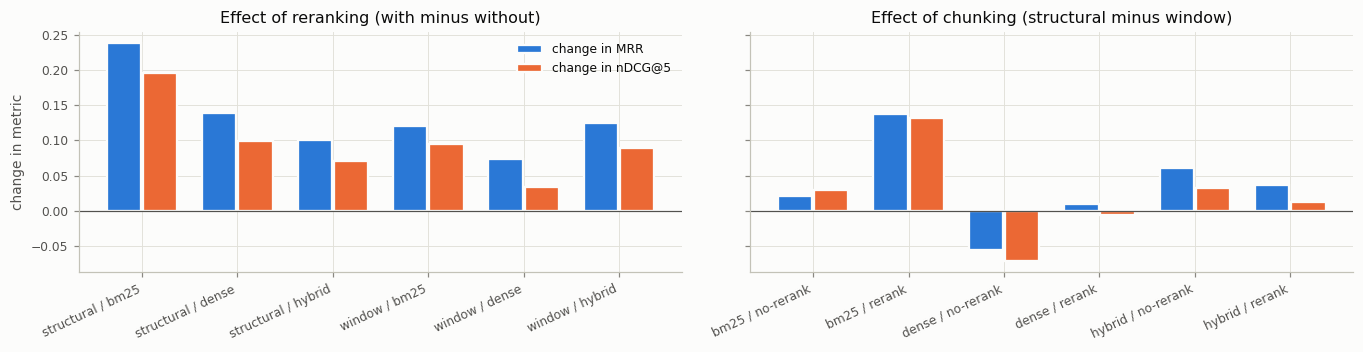

In [ ]:
eff_rows = []
for name in INDEXES:
    for mode in ("bm25", "dense", "hybrid"):
        a_, b_ = ret_tab.loc[f"{name}/{mode}/no-rerank"], ret_tab.loc[f"{name}/{mode}/rerank"]
        eff_rows.append(dict(factor="reranking", setting=f"{name} / {mode}", d_mrr=b_.mrr - a_.mrr, d_ndcg=b_.ndcg_at_5 - a_.ndcg_at_5))
for mode in ("bm25", "dense", "hybrid"):
    for rr in ("no-rerank", "rerank"):
        a_, b_ = ret_tab.loc[f"window/{mode}/{rr}"], ret_tab.loc[f"structural/{mode}/{rr}"]
        eff_rows.append(dict(factor="structural chunking", setting=f"{mode} / {rr}", d_mrr=b_.mrr - a_.mrr, d_ndcg=b_.ndcg_at_5 - a_.ndcg_at_5))
EFFECTS = pd.DataFrame(eff_rows).round(3)
display(EFFECTS)
eff_sum = EFFECTS.groupby("factor")[["d_mrr", "d_ndcg"]].agg(["mean", "min", "max"]).round(3)
eff_sum.columns = [f"{m}_{s}" for m, s in eff_sum.columns]
display(eff_sum)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.3), sharey=True)
for a, fac in zip(ax, ("reranking", "structural chunking")):
    sub = EFFECTS[EFFECTS.factor == fac]
    x = np.arange(len(sub))
    a.bar(x - 0.19, sub.d_mrr, width=0.36, color=PAL[0], label="change in MRR", edgecolor=SURFACE, linewidth=1.5)
    a.bar(x + 0.19, sub.d_ndcg, width=0.36, color=PAL[1], label="change in nDCG@5", edgecolor=SURFACE, linewidth=1.5)
    a.axhline(0, color=INK2, linewidth=0.8)
    a.set_xticks(x, sub.setting, rotation=25, ha="right")
    a.set_title("Effect of reranking (with minus without)" if fac == "reranking" else "Effect of chunking (structural minus window)")
ax[0].set_ylabel("change in metric"); ax[0].legend(loc="upper right")
finish(fig, "a_effect_sizes")
RESULTS["retrieval"]["effects"] = EFFECTS.to_dict("records")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ה-⁠reranking העלה את MRR בכל ששת הצירופים, ב-⁠0.07 עד 0.24 (ממוצע 0.13), ואת nDCG@5 ב-⁠0.03 עד 0.20 (ממוצע 0.10). ה-⁠chunking המבני שינה את MRR בין 0.06- ל-⁠0.14+ (ממוצע 0.035), ולפעמים מזיק: ב-⁠dense בלי reranking הוא מוריד nDCG@5 ב-⁠0.07. ההשפעה הגדולה היא ב-⁠BM25 עם reranking, 0.13+ ב-⁠nDCG@5; בארבעת האחרים עד 0.03. ה-⁠reranking הוא הגורם החזק והיציב; ה-⁠chunking משני ותלוי בשיטה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התנאי הראשי לפי שאילתה: טבלת מדדים, גרף nDCG@5 צבוע לפי מקור, וגיליון לתיוג ידני של מסמכים רלוונטיים מחוץ לזהב, עם מילון להדבקה.</p>
</div>

,p_at_k,r_prec,r_at_k,rr,ndcg,recall_cand,source
id,,,,,,,
Q01,0.2,1.0,1.0,1.0,1.00,1.0,dataset gold
Q02,0.2,0.5,0.5,1.0,0.61,0.5,dataset gold
Q03,0.0,0.0,0.0,0.0,0.00,0.0,dataset gold
Q04,0.2,1.0,1.0,1.0,1.00,1.0,dataset gold
Q05,0.2,1.0,1.0,1.0,1.00,1.0,own
Q06,0.2,1.0,1.0,1.0,1.00,1.0,external QA
Q07,0.2,1.0,1.0,1.0,1.00,1.0,own
Q08,0.2,1.0,1.0,1.0,1.00,1.0,"own, paraphrase"
Q09,0.2,1.0,1.0,1.0,1.00,1.0,"own, paraphrase"


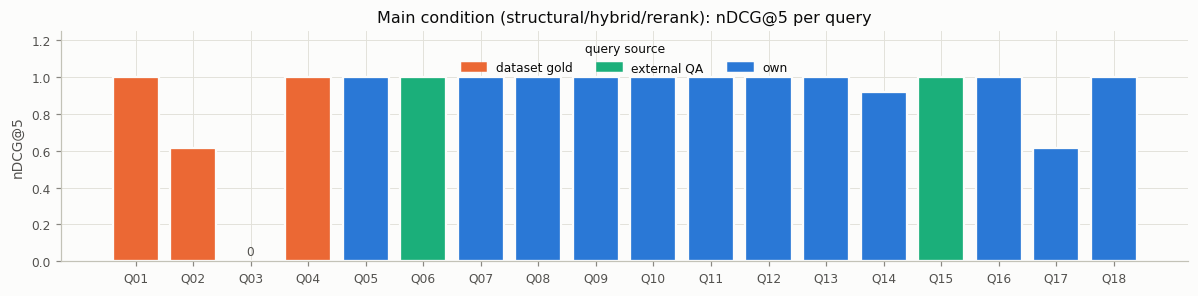

Q01 p@5=0.20 r@5=1.00 nDCG=1.00 | What is a 'provider' under the AI Act?
      + art-3    Article 3 — Definitions
      - art-25   Article 25 — Responsibilities along the AI value chain
      - art-91   Article 91 — Power to request documentation and information
      - art-92   Article 92 — Power to conduct evaluations
      - art-50   Article 50 — Transparency obligations for providers and deployers of certain AI 
Q02 p@5=0.20 r@5=0.50 nDCG=0.61 | Is an AI tool that screens CVs considered high-risk?
      + art-6    Article 6 — Classification rules for high-risk AI systems
      - art-80   Article 80 — Procedure for dealing with AI systems classified by the provider as
      - anx-VIII Annex VIII — Information to be submitted upon the registration of high-risk AI s
      - art-82   Article 82 — Compliant AI systems which present a risk
      - art-9    Article 9 — Risk management system
Q03 p@5=0.00 r@5=0.00 nDCG=0.00 | When do the obligations for general-purpose AI models start to a

In [ ]:
main = PER_QUERY[MAIN_COND].set_index("id")
SRC = {q["id"]: q["source"].split(",")[0] for q in QUERIES}
SRC_COLOR = {"dataset gold": PAL[1], "external QA": PAL[2], "own": PAL[0]}
pq_tab = main[["p_at_k", "r_prec", "r_at_k", "rr", "ndcg", "recall_cand"]].round(2).assign(source=[q["source"] for q in QUERIES])
display(pq_tab)
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.bar(range(len(main)), main.ndcg, color=[SRC_COLOR.get(SRC[i], PAL[0]) for i in main.index], edgecolor=SURFACE, linewidth=1.5)
ax.set_xticks(range(len(main)), main.index); ax.set_ylim(0, 1.25); ax.set_ylabel("nDCG@5")
for i_, v in enumerate(main.ndcg):
    if v == 0:
        ax.text(i_, 0.02, "0", ha="center", va="bottom", fontsize=8, color=INK2)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in SRC_COLOR.values()], list(SRC_COLOR), title="query source", loc="upper center", ncol=3)
ax.set_title(f"Main condition ({MAIN_COND}): nDCG@5 per query")
finish(fig, "a_main_per_query")
for q in QUERIES:
    row = main.loc[q["id"]]
    print(f"{q['id']} p@5={row.p_at_k:.2f} r@5={row.r_at_k:.2f} nDCG={row.ndcg:.2f} | {q['q']}")
    for d in row.top_docs:
        print(f"      {'+' if d in q['gold'] else '-'} {d:8s} {DOC[d]['title'][:80]}")
print("\nready-to-paste dict (1 = relevant, 0 = not relevant; gold documents are pre-marked 1, check every 0 against the text):")
print("MANUAL_RELEVANCE = {")
for q in QUERIES:
    print(f"    {q['id']!r}: " + "{" + ", ".join(f"{d!r}: {int(d in q['gold'])}" for d in main.loc[q["id"], "top_docs"]) + "},")
print("}")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בתנאי הראשי, 17 מתוך 18 שאילתות מקבלות מסמך זהב במקום הראשון; Q03 לא. ב-⁠Q02 נמצא סעיף 6 בלי נספח III, ב-⁠Q17 סעיף 11 בלי נספח IV, וב-⁠Q14 סעיף 58 נדחק בין שני מסמכי הזהב, ולכן nDCG@5 0.92; שם גם הוחזרו רק 4 מסמכים שונים, ולכן precision@5 מחושב על 4 ונותן 0.5, במקום 0.4 על 5 מקומות. הגיליון שמעל הוא הבסיס לתיוג הידני: ב-⁠10 מ-⁠18 השאילתות יש שכנים רלוונטיים מחוץ לזהב, 16 בסך הכול, אחד מהם במקום הראשון (סעיף 111 ב-⁠Q03); למשל סעיף 100 ב-⁠Q06, רלוונטי חלקית (קנס למוסדות האיחוד), וסעיפים 91 ו-⁠101 ב-⁠Q18.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מילון הרלוונטיות הידנית: 1 למסמך שעוזר לענות, גם חלקית, ו-⁠0 אחרת; ההחלטה על 70 המסמכים שאינם זהב, וה-⁠precision@5 יחושב גם מולו.</p>
</div>

In [ ]:
MANUAL_RELEVANCE = {
    'Q01': {'art-3': 1, 'art-25': 1, 'art-91': 0, 'art-92': 0, 'art-50': 0},
    'Q02': {'art-6': 1, 'art-80': 0, 'anx-VIII': 0, 'art-82': 0, 'art-9': 0},
    'Q03': {'art-111': 1, 'art-53': 0, 'art-55': 0, 'art-54': 0, 'art-94': 0},
    'Q04': {'art-2': 1, 'art-53': 1, 'art-54': 1, 'art-25': 1, 'art-111': 0},
    'Q05': {'art-5': 1, 'art-1': 0, 'art-96': 0, 'art-10': 0, 'art-112': 0},
    'Q06': {'art-99': 1, 'art-100': 1, 'art-5': 0, 'art-101': 0, 'art-57': 0},
    'Q07': {'art-51': 1, 'art-3': 0, 'anx-XIII': 0, 'art-101': 0, 'art-52': 0},
    'Q08': {'art-5': 1, 'art-26': 0, 'art-50': 1, 'anx-III': 1, 'art-3': 0},
    'Q09': {'art-5': 1, 'art-46': 0, 'art-3': 0, 'anx-III': 1, 'art-26': 1},
    'Q10': {'art-50': 1, 'art-3': 0, 'art-5': 0, 'art-10': 0, 'art-26': 0},
    'Q11': {'art-9': 1, 'art-17': 0, 'art-15': 0, 'art-8': 0, 'art-14': 0},
    'Q12': {'art-6': 1, 'art-7': 0, 'art-71': 0, 'art-49': 0, 'art-80': 0},
    'Q13': {'art-26': 1, 'art-16': 0, 'art-13': 0, 'art-24': 0, 'art-111': 0},
    'Q14': {'art-57': 1, 'art-58': 1, 'art-3': 1, 'art-76': 0},
    'Q15': {'art-53': 1, 'art-55': 1, 'art-50': 0, 'art-54': 1, 'art-56': 0},
    'Q16': {'art-26': 1, 'art-18': 1, 'art-19': 1, 'art-47': 0, 'art-22': 0},
    'Q17': {'art-11': 1, 'art-17': 0, 'art-18': 0, 'art-13': 0, 'art-22': 0},
    'Q18': {'art-99': 1, 'art-91': 1, 'art-101': 1, 'art-100': 0, 'art-57': 0},
}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>manual_precision: ה-⁠precision@5 לפי התיוג הידני, מבין המסמכים שהוחזרו; מסמך חסר מסומן לפי הזהב, ושאילתה שלא תויגה מחזירה&nbsp;None.</p>
</div>

In [ ]:
def manual_precision(qid, top_docs):
    labels = MANUAL_RELEVANCE.get(qid)
    if not labels:
        return None
    return float(np.mean([labels.get(d, int(d in set(next(q["gold"] for q in QUERIES if q["id"] == qid)))) for d in top_docs]))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ה-⁠precision@5 מול הזהב ומול התיוג הידני, בשאילתות שתויגו: ממוצעים, טבלה וגרף. ידני גבוה מזהב פירושו מסמכים רלוונטיים מחוץ לזהב.</p>
</div>

queries checked manually: 18 of 18
mean precision@5 vs pre-registered gold 0.217 | vs manual judgement 0.397


,p_at_5_gold,p_at_5_manual
id,,
Q01,0.2,0.40
Q02,0.2,0.20
Q03,0.0,0.20
Q04,0.2,0.80
Q05,0.2,0.20
Q06,0.2,0.40
Q07,0.2,0.20
Q08,0.2,0.60
Q09,0.2,0.60


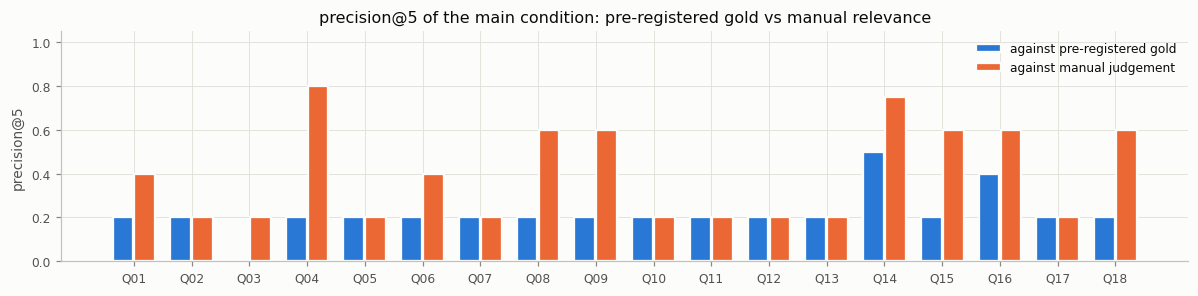

In [ ]:
manual_rows = [dict(id=q["id"], p_at_5_gold=round(main.loc[q["id"], "p_at_k"], 3), p_at_5_manual=manual_precision(q["id"], main.loc[q["id"], "top_docs"])) for q in QUERIES]
manual_tab = pd.DataFrame(manual_rows).set_index("id")
n_checked = int(manual_tab.p_at_5_manual.notna().sum())
print(f"queries checked manually: {n_checked} of {len(QUERIES)}")
if n_checked:
    print(f"mean precision@5 vs pre-registered gold {manual_tab.p_at_5_gold.mean():.3f} | vs manual judgement {manual_tab.p_at_5_manual.mean():.3f}")
    display(manual_tab)
    chk = manual_tab.dropna()
    fig, ax = plt.subplots(figsize=(11, 2.8))
    x = np.arange(len(chk))
    ax.bar(x - 0.19, chk.p_at_5_gold, width=0.36, color=PAL[0], label="against pre-registered gold", edgecolor=SURFACE, linewidth=1.5)
    ax.bar(x + 0.19, chk.p_at_5_manual, width=0.36, color=PAL[1], label="against manual judgement", edgecolor=SURFACE, linewidth=1.5)
    ax.set_xticks(x, chk.index); ax.set_ylim(0, 1.05); ax.set_ylabel("precision@5"); ax.legend()
    ax.set_title("precision@5 of the main condition: pre-registered gold vs manual relevance")
    finish(fig, "a_manual_relevance")
RESULTS["retrieval"]["manual_relevance"] = dict(n_checked=n_checked, table=manual_tab.to_dict("index"), labels=MANUAL_RELEVANCE)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>89 מסמכים תויגו. ה-⁠precision@5 הממוצע: 0.217 מול הזהב, 0.397 מול התיוג. ב-⁠10 שאילתות נמצאו 16 רלוונטיים מחוץ לזהב, וב-⁠8 רק הזהב.</p>
<ul>
<li>Q04 (open source) — 0.8: סעיפים 53, 54 ו-⁠25 קובעים כל אחד חריג לרישיון פתוח, לצד סעיף 2 שבזהב</li>
<li>Q18 (קנס על מידע שגוי) — 0.6: סעיף 101 קובע את הקנס לספקי GPAI, וסעיף 91 מפנה אליו</li>
<li>Q08, Q09, Q15 — 0.6: נספח III וסעיפים 50(3) ו-⁠26(10) לזיהוי רגשות ולזיהוי ביומטרי מרחוק (RBI), וסעיפים 54 ו-⁠55 לספקי GPAI</li>
<li>Q03 — מ-⁠0 ל-⁠0.2: הזהב, סעיף 113, לא אוחזר, אבל סעיף 111 קובע את המועד למודלים שכבר בשוק, 2 באוגוסט 2027</li>
</ul>
<p>מול הזהב נספר רק הזהב; מול התיוג, כל מסמך מועיל. הפער, 0.18, הוא הערכת-החסר של precision@5; שאר המדדים חושבו מול הזהב בלבד. מול התיוג MRR היה 1.0, כי ב-⁠Q03 סעיף 111 ראשון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח הכשלים בטבלאות ובגרפים: שאילתות עם recall אפס במועמדים לכל תנאי, הקשות על פני 12 התנאים, ו-⁠recall@5 לפי מקור בתנאי הראשי.</p>
</div>

,zero_recall_queries
condition,
structural/bm25/no-rerank,Q03
structural/bm25/rerank,Q03
structural/dense/no-rerank,Q03
structural/dense/rerank,Q03
structural/hybrid/no-rerank,Q03
structural/hybrid/rerank,Q03
window/bm25/no-rerank,"Q03, Q10"
window/bm25/rerank,"Q03, Q10"
window/dense/no-rerank,Q03


,mean_recall_all_conditions,source,query
id,,,
Q03,0.000,dataset gold,When do the obligations for general-purpose AI models start to apply?
Q02,0.667,dataset gold,Is an AI tool that screens CVs considered high-risk?
Q17,0.708,own,What must the technical documentation of a high-risk AI system contain?
Q01,0.750,dataset gold,What is a 'provider' under the AI Act?
Q14,0.833,"own, multi-document",What is an AI regulatory sandbox and who establishes them?
Q10,0.833,"own, paraphrase",Must people be told that they are talking to a chatbot?


,mean,size
source,,
dataset gold,0.625,4
external QA,1.000,2
own,0.958,12


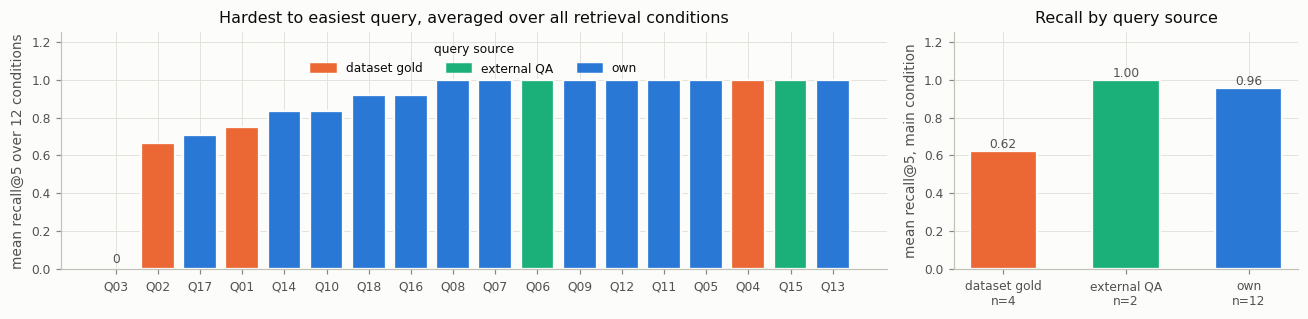

In [ ]:
zero = {cond: d[d.recall_cand == 0].id.tolist() for cond, d in PER_QUERY.items() if (d.recall_cand == 0).any()}
display(pd.DataFrame([dict(condition=c, zero_recall_queries=", ".join(v)) for c, v in zero.items()]).set_index("condition") if zero else "no query has zero candidate recall")
hard = heat.mean(axis=1).sort_values()
hard_tab = pd.DataFrame(dict(mean_recall_all_conditions=hard.round(3), source=[next(q["source"] for q in QUERIES if q["id"] == i) for i in hard.index],
                             query=[ITEM_TEXT[i] for i in hard.index]))
display(hard_tab.head(6))
by_source = pd.DataFrame([dict(id=q["id"], source=q["source"].split(",")[0], r_at_5=main.loc[q["id"], "r_at_k"]) for q in QUERIES]).groupby("source").r_at_5.agg(["mean", "size"]).round(3)
display(by_source)
fig, ax = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw=dict(width_ratios=[2.4, 1]))
ax[0].bar(range(len(hard)), hard.values, color=[SRC_COLOR.get(SRC[i], PAL[0]) for i in hard.index], edgecolor=SURFACE, linewidth=1.5)
ax[0].set_xticks(range(len(hard)), hard.index); ax[0].set_ylim(0, 1.25); ax[0].set_ylabel("mean recall@5 over 12 conditions")
for i_, v in enumerate(hard.values):
    if v == 0:
        ax[0].text(i_, 0.02, "0", ha="center", va="bottom", fontsize=8, color=INK2)
ax[0].legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in SRC_COLOR.values()], list(SRC_COLOR), title="query source", loc="upper center", ncol=3)
ax[0].set_title("Hardest to easiest query, averaged over all retrieval conditions")
ax[1].bar(range(len(by_source)), by_source["mean"], color=[SRC_COLOR.get(s, PAL[0]) for s in by_source.index], edgecolor=SURFACE, linewidth=1.5, width=0.55)
ax[1].set_xticks(range(len(by_source)), [f"{s}{chr(10)}n={int(n)}" for s, n in zip(by_source.index, by_source["size"])])
ax[1].set_ylim(0, 1.25); ax[1].set_ylabel("mean recall@5, main condition"); ax[1].set_title("Recall by query source")
for x_, v in enumerate(by_source["mean"]):
    ax[1].text(x_, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color=INK2)
finish(fig, "a_failure_analysis")
RESULTS["retrieval"]["zero_recall"] = zero
RESULTS["retrieval"]["hardest"] = hard_tab.head(6).to_dict("index")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>רק ב-⁠Q03 ה-⁠recall במועמדים אפס בכל 12 התנאים: סעיף 113 קובע ש-⁠Chapter V חל מ-⁠2.8.2025, בלי המילים general-purpose AI; המילים המשותפות לשאילתה, apply ו-⁠obligations, נפוצות ואינן מבחינות. הסבר סביר: לא BM25 ולא dense מקשרים את Chapter V ל-⁠GPAI, ולכן עולים במקומו סעיפי GPAI אחרים, 53–55.</p>
<p>ב-⁠Q10 נכשל רק BM25 על חלונות. הסבר אפשרי: המילה chatbot לא מופיעה בחוק, שכותב "to interact directly with natural persons", ולכן BM25 נשען על מילים כלליות; בפסקה הקצרה של סעיף 50(1) הן מספיקות, ובחלון של 200 מילים הן נבלעות.</p>
<p>לפי מקור, בתנאי הראשי: זהב הדאטהסט 0.625, חיצוניות 1.0, שכתבתי 0.96; הפער נובע מ-⁠Q03 ו-⁠Q02 בלבד, ולכן אינו מגמה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק א׳:</p>
<ul>
<li>בצינור הראשי MRR 0.94, nDCG@5 0.90, recall@5 0.89, R-precision 0.86: זהב ראשון ב-⁠17 מ-⁠18, וכשל רק ב-⁠Q03</li>
<li>לשאלת הניתוח, ה-⁠reranking משפיע יותר על איכות הדירוג: MRR עולה ב-⁠0.07–0.24 ו-⁠nDCG@5 ב-⁠0.03–0.20, בכל ששת הצירופים. ה-⁠chunking זז לשני הכיוונים: nDCG@5 מ-⁠0.07- ב-⁠dense בלי reranking עד 0.13+ ב-⁠BM25 עם reranking; על recall@5 דווקא ה-⁠chunking זז יותר, עד 0.11 ב-⁠BM25</li>
<li>הסבר: recall המועמדים 0.86–0.94 בכל תנאי, כך שהבעיה היא הסדר, וה-⁠cross-encoder פותר אותה כי הוא קורא שאילתה וקטע יחד; ה-⁠chunking משנה איזו יחידה מקבלת ציון. ב-⁠dense וב-⁠hybrid ה-⁠reranker מצמצם את ההבדל בין החלוקות ל-⁠0.04 לכל היותר ב-⁠MRR; ב-⁠BM25 הפער דווקא גדל, מ-⁠0.02 ל-⁠0.14, כי בחלונות Q10 חסרה כבר במועמדים ו-⁠Q01 לא עולה לחמישייה</li>
<li>במבני, בלי reranking, ה-⁠hybrid מוביל ב-⁠MRR: 0.84 מול 0.78 ל-⁠dense ו-⁠0.67 ל-⁠BM25; עם reranking שלושתן 0.91–0.94</li>
<li>ה-⁠precision@5 נע בין 0.18 ל-⁠0.23, כי ל-⁠14 שאילתות זהב אחד; מול התיוג הידני הוא 0.40 במקום 0.22, עם 16 שכנים רלוונטיים ב-⁠10 שאילתות</li>
<li>כשל מוחלט ב-⁠Q03: סעיף 113(b) מחיל את פרק V מ-⁠2.8.2025 בלי לומר general-purpose; לא BM25 ולא dense גושרים על מספר פרק</li>
<li>recall@5 אפס גם ב-⁠Q01 (שלושה מארבעת תנאי BM25) וב-⁠Q18 (BM25 על חלונות בלי reranking). המשותף: פער ניסוח בין השאילתה לטקסט הזהב: הפניה במספר פרק (Q03), מונח שאינו בחוק (Q10), וכנראה מונח נפוץ מדי (Q01). מלבד Q03, כל ששת התאים האפסיים ב-⁠BM25, חמישה מהם על חלונות. הציפייה ל-⁠recall אפס בניסוח עקיף התאמתה חלקית: מבין הפרפרזות רק Q10 נכשלה, ו-⁠Q03 היא שאלה ישירה שהחוק עונה עליה בעקיפין</li>
<li>השאילתה Q10 נכשלת רק ב-⁠BM25 על חלונות, כנראה כי chatbot לא מופיע בחוק; ההטמעות גושרות. כשל דומה של חפיפת מילים במילים נרדפות מופיע במחברת הליווי של הרצאה 3</li>
<li>לפי מקור, זהב הדאטהסט 0.625 מול 0.96 ו-⁠1.0, בגלל Q03 ו-⁠Q02 בלבד: לא מגמה. הסבר אפשרי: שאלה שנכתבת מתוך הטקסט נוטה להשתמש במילותיו</li>
<li>מחיר: reranking כ-⁠0.6 שניות לשאילתה על L4, מול עד 0.02 בלעדיו; בקורפוס גדול זו הסיבה לדרג רק 20 מועמדים</li>
</ul>
<p>מה לא ניתן להסיק: ב-⁠18 שאילתות, שאילתה אחת שווה 0.056, והפרשים קטנים מזה רעש. הרלוונטיות נמדדת ברמת המסמך מול זהב קבוע: קטע לא מועיל מסעיף רלוונטי נספר כפגיעה, ומסמך רלוונטי שאינו בזהב כהחטאה; התיוג הידני מתקן את השני, לא את הראשון, ונעשה בידי מתייג&nbsp;יחיד.</p>
</div>

In [ ]:
checkpoint("Part A")

[checkpoint after Part A] /content/drive/MyDrive/FM/Final_Project/outputs/project_results.json (0.01 MB) | cache hits 0, misses 0


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ב׳ — Generation מבוסס-הקשר</p>
<ul>
<li>בסיס ה-⁠RAG: חמשת הקטעים מהצינור הראשי בפרומפט עם השאילתה; המודל נדרש לענות מהמסמכים בלבד ולצטט מזהה מסמך</li>
<li>קריטריון groundedness: כל טענה עובדתית ניתנת לאיתור בקטע או בפלט כלי; השופט מתבקש לפרק את התשובה לעד 6 טענות, ולעיתים מפרט עד 9; בודק כל אחת ומחזיר פסק וספירה</li>
<li>תנאי closed-book: אותן שאילתות בלי retrieval, הבייסליין לחלק ו׳; נשפט בדיעבד מול הקטעים שהיו מאוחזרים</li>
<li>בדו"ח GPT-4, הזיה closed-domain מוסיפה על ההקשר, ו-⁠open-domain שוגה בעובדות; RAG נמדד על הראשונה ו-⁠closed-book על השנייה</li>
<li>שאלת הניתוח: היכן RAG המציא מידע כשמסמכים רלוונטיים היו בהקשר, וכשל אחזור מול כשל סינתזה</li>
</ul>
<p>ציפיות מראש: המודל ראה כנראה בעיקר טיוטות של החוק באימון, ולכן closed-book ייתן מספרים ותאריכים מטיוטות; RAG יהיה מבוסס, וההזיות יתרכזו כש-⁠recall נמוך.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הנחיות הפורמט והמערכת:</p>
<ul>
<li>ANSWER_FORMAT — שורת ANSWER אחת בסוף, זהה בכל התנאים ובשתי גישות הסוכן, כדי שבדיקה אוטומטית אחת תדרג את כולם</li>
<li>ANSWER_SYSTEM — ל-⁠closed-book: תשובה קצרה, ואמירה מפורשת כשהמודל לא בטוח</li>
<li>GROUNDED_SYSTEM — ל-⁠RAG: מהמסמכים בלבד, ציטוט מזהה מסמך אחרי כל טענה, ואמירה מפורשת כשהתשובה לא שם</li>
<li>RUNS — מאגר כל התשובות בכל התנאים</li>
</ul>
</div>

In [ ]:
ANSWER_FORMAT = ("End your reply with a line of exactly this form:\nANSWER: <the value>\n"
                 "The ANSWER line holds only the result itself, a number, a name or a short phrase, with no explanation around it.")
ANSWER_SYSTEM = ("You are a precise assistant answering questions about the EU Artificial Intelligence Act (Regulation (EU) 2024/1689). "
                 "Answer concisely in a few sentences. If you are not sure, say so.\n" + ANSWER_FORMAT)
GROUNDED_SYSTEM = ("You answer questions about the EU Artificial Intelligence Act using ONLY the provided documents. Every factual claim must be "
                   "supported by the documents, and you cite the document id in square brackets after the claim, e.g. [art-99]. "
                   "If the documents do not contain the answer, say exactly that.\n" + ANSWER_FORMAT)
RUNS = defaultdict(dict)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>rkey: מפתח ריצה אחיד, מזהה פריט ו-⁠seed, לכל התנאים ב-⁠RUNS; למשל&nbsp;Q06|s2.</p>
</div>

In [ ]:
def rkey(item_id, seed):
    return f"{item_id}|s{seed}"

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>answer_llm_only: תשובה בלי הקשר, באותו מודל ופענוח; הראיות לשופט הן הקטעים שהצינור הראשי היה מחזיר, כדי לשפוט מול אותו קורפוס.</p>
</div>

In [ ]:
def answer_llm_only(text, seed):
    r = chat(AGENT, [{"role": "system", "content": ANSWER_SYSTEM}, {"role": "user", "content": text}], max_new=CFG["max_new_answer"], seed=seed)
    top, _ = retrieve(text)
    return dict(answer=r["text"], evidence=[passage(c) for c in top], retrieved=[], cited=[],
                llm_calls=1, tool_calls=0, prompt_tokens=r["prompt_tokens"], gen_tokens=r["n_tokens"], seconds=r["seconds"])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>answer_rag: אחזור, כברירת מחדל בצינור הראשי ובבונוס במצב אחר, הקשר בפרומפט ואותו פענוח; נשמרים ראיות, מסמכים שאוחזרו וצוטטו ועלות כולל זמן האחזור, וכל מזהה בתשובה נספר כציטוט.</p>
</div>

In [ ]:
def answer_rag(text, seed, index=None, mode="hybrid", rerank=True):
    t0 = time.perf_counter()
    top, _ = retrieve(text, index, mode, rerank)
    t_ret = time.perf_counter() - t0
    r = chat(AGENT, [{"role": "system", "content": GROUNDED_SYSTEM},
                    {"role": "user", "content": f"Documents:\n{format_context(top)}\n\nQuestion: {text}"}], max_new=CFG["max_new_answer"], seed=seed)
    return dict(answer=r["text"], evidence=[passage(c) for c in top], retrieved=list(dict.fromkeys(c["doc_id"] for c in top)),
                cited=sorted(set(re.findall(r"\b((?:art|anx)-\w+)", r["text"]))),
                llm_calls=1, tool_calls=0, prompt_tokens=r["prompt_tokens"], gen_tokens=r["n_tokens"], seconds=round(r["seconds"] + t_ret, 2))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הרצת שני התנאים על 18 השאילתות בשלושת ה-⁠seeds, עם שתי דוגמאות; אחריהן טבלת העלות, וגרפי אורך התשובה וטוקני הפרומפט מול היצירה.</p>
</div>

answers: 54 closed-book, 54 RAG | agent calls so far 108, 9.8 min

=== Q01: What is a 'provider' under the AI Act?
closed-book: A provider under the AI Act is an entity that places an AI system on the market or puts it into service. ANSWER: provider
RAG        : A provider under the AI Act means a natural or legal person, public authority, agency, or other body that develops an AI system or a general-purpose AI model or that has an AI system or a general-purpose AI model developed and places it on the market or puts the AI system into service under its own name or trademark, whether for payment or free of 

=== Q02: Is an AI tool that screens CVs considered high-risk?
closed-book: An AI tool that screens CVs is not considered high-risk under the EU Artificial Intelligence Act. It falls into the low-risk category.  ANSWER: low-risk
RAG        : To determine if an AI tool that screens CVs is considered high-risk, we need to check against the criteria for high-risk AI systems. According t

,answer_words_mean,answer_words_median,answer_words_max,prompt_tokens_mean,prompt_tokens_median,prompt_tokens_max,gen_tokens_mean,gen_tokens_median,gen_tokens_max,seconds_mean,seconds_median,seconds_max
condition,,,,,,,,,,,,
llm_only,40.6,35.0,94,118.4,118.0,127,51.7,45.0,107,2.8,2.4,5.7
rag,111.0,85.0,261,1040.1,1007.5,1411,147.0,112.0,320,8.8,6.9,18.0


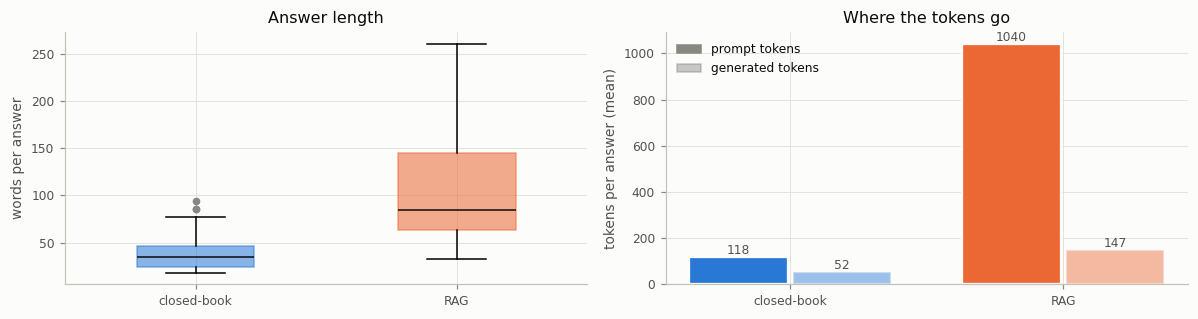

In [ ]:
for q in QUERIES:
    for seed in CFG["seeds"]:
        RUNS["llm_only"][rkey(q["id"], seed)] = answer_llm_only(q["q"], seed)
        RUNS["rag"][rkey(q["id"], seed)] = answer_rag(q["q"], seed)
print(f"answers: {len(RUNS['llm_only'])} closed-book, {len(RUNS['rag'])} RAG | agent calls so far {AGENT.calls}, {AGENT.seconds / 60:.1f} min")
for q in QUERIES[:2]:
    k = rkey(q["id"], CFG["seeds"][0])
    print(f"\n=== {q['id']}: {q['q']}")
    print("closed-book:", RUNS["llm_only"][k]["answer"][:350].replace("\n", " "))
    print("RAG        :", RUNS["rag"][k]["answer"][:350].replace("\n", " "))
B_COST = pd.DataFrame([dict(condition=c, answer_words=len((r["answer"] or "").split()), prompt_tokens=r["prompt_tokens"], gen_tokens=r["gen_tokens"], seconds=r["seconds"])
                       for c in ("llm_only", "rag") for k, r in RUNS[c].items() if not k.startswith("T")])
cost_sum = B_COST.groupby("condition").agg(["mean", "median", "max"]).round(1)
cost_sum.columns = [f"{m}_{s}" for m, s in cost_sum.columns]
display(cost_sum)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
bp = ax[0].boxplot([B_COST[B_COST.condition == c].answer_words for c in ("llm_only", "rag")], patch_artist=True, widths=0.45,
                   medianprops=dict(color=INK), flierprops=dict(markersize=4, markerfacecolor=MUTED, markeredgecolor=MUTED))
for patch, c in zip(bp["boxes"], ("llm_only", "rag")):
    patch.set_facecolor(COLOR[c]); patch.set_alpha(0.55); patch.set_edgecolor(COLOR[c])
ax[0].set_xticks([1, 2], ["closed-book", "RAG"]); ax[0].set_ylabel("words per answer"); ax[0].set_title("Answer length")
means = B_COST.groupby("condition")[["prompt_tokens", "gen_tokens"]].mean()
x = np.arange(2)
cols = [COLOR[c] for c in ("llm_only", "rag")]
ax[1].bar(x - 0.19, means.loc[["llm_only", "rag"], "prompt_tokens"], width=0.36, color=cols, edgecolor=SURFACE, linewidth=1.5)
ax[1].bar(x + 0.19, means.loc[["llm_only", "rag"], "gen_tokens"], width=0.36, color=cols, alpha=0.45, edgecolor=SURFACE, linewidth=1.5)
for x_, c in enumerate(("llm_only", "rag")):
    for dx, col in ((-0.19, "prompt_tokens"), (0.19, "gen_tokens")):
        ax[1].text(x_ + dx, means.loc[c, col], f"{means.loc[c, col]:.0f}", ha="center", va="bottom", fontsize=8, color=INK2)
ax[1].set_xticks(x, ["closed-book", "RAG"]); ax[1].set_ylabel("tokens per answer (mean)"); ax[1].set_title("Where the tokens go")
ax[1].legend([plt.Rectangle((0, 0), 1, 1, color=MUTED), plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.45)], ["prompt tokens", "generated tokens"], loc="upper left")
finish(fig, "b_cost")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>108 תשובות, 54 לתנאי, ב-⁠9.8 דקות של הסוכן. בדוגמאות, closed-book מגדיר provider במשפט כללי, ו-⁠RAG מעתיק את ההגדרה של סעיף 3 כמעט מילה במילה. ב-⁠Q02 closed-book קובע low-risk, בניגוד לנספח III נקודה&nbsp;4(a).</p>
<p>עלות: פרומפט RAG ארוך פי 8.8 (1,040 טוקנים מול 118), יצירה פי 2.8 (147 מול 52), תשובות ארוכות פי 2.7 במילים, וזמן 8.75 שניות מול 2.76 (פי 3.2). הזמן עוקב אחרי יחס היצירה ולא אחרי יחס הפרומפט, ולכן רוב תוספת הזמן היא ביצירה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>judge_runs: שופטת רשומות תנאי נבחרות; הפסק, answers_question, הנימוק וספירת הטענות נכתבים ל-⁠judge, ובסדר ראיות הפוך ל-⁠judge2.</p>
</div>

In [ ]:
def judge_runs(cond, keys, label, reverse=False):
    items = [dict(key=f"{cond}|{k}", q=ITEM_TEXT[k.split("|")[0]], a=RUNS[cond][k]["answer"], evidence=RUNS[cond][k]["evidence"]) for k in keys]
    for k, v in zip(keys, judge_groundedness(items, reverse=reverse, label=label)):
        field = "judge2" if reverse else "judge"
        RUNS[cond][k][field] = {f: v[f] for f in ("verdict", "answers_question", "rationale", "n_claims", "n_unsupported")}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השופט על תשובות חלק ב׳; התפלגות הפסקים לכל תנאי, עם התשובות שנמנעו, בטבלה ובגרף מוערם, ומפת פסקים לכל שאילתה, תנאי ו-⁠seed.</p>
</div>

config.json:   0%|          | 0.00/802 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/17.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.25M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/243 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

,llm_only,rag
GROUNDED,21,52
PARTIALLY_GROUNDED,23,2
NOT_GROUNDED,10,0
INVALID,0,0
abstained (answers_question=False),0,0


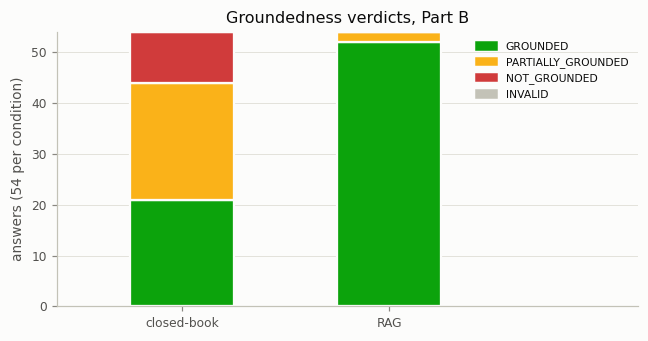

,closed s1,closed s2,closed s3,RAG s1,RAG s2,RAG s3
Q01,G,P,G,G,G,G
Q02,G,G,G,P,G,G
Q03,N,N,N,G,G,G
Q04,P,P,G,G,G,G
Q05,P,G,G,G,G,P
Q06,G,G,N,G,G,G
Q07,N,N,N,G,G,G
Q08,G,G,G,G,G,G
Q09,G,G,G,G,G,G
Q10,P,P,G,G,G,G


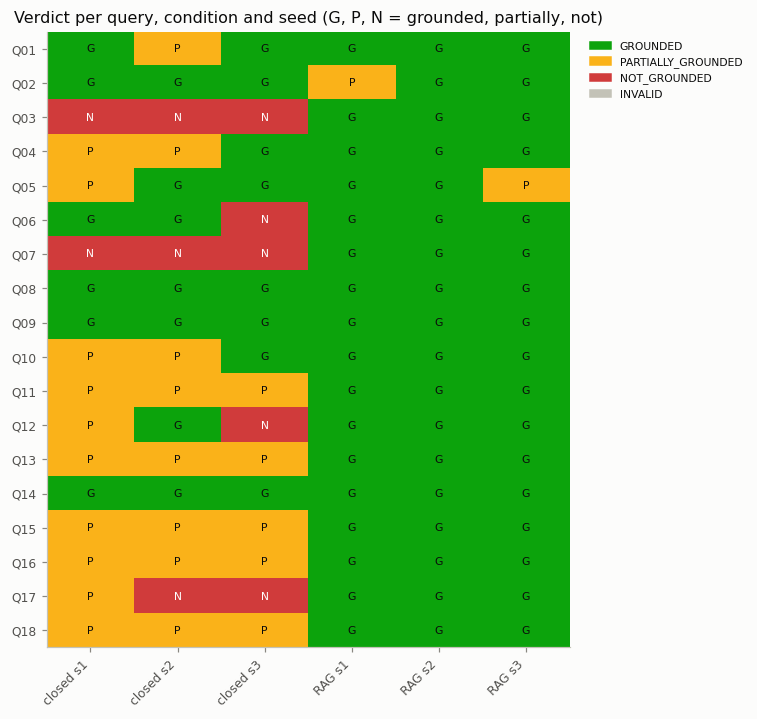

In [ ]:
B_KEYS = [rkey(q["id"], s) for q in QUERIES for s in CFG["seeds"]]
judge_runs("llm_only", B_KEYS, "B")
judge_runs("rag", B_KEYS, "B")
free_judge()
dist = pd.DataFrame({c: Counter(RUNS[c][k]["judge"]["verdict"] for k in B_KEYS) for c in ("llm_only", "rag")}).reindex(VERDICTS + ["INVALID"]).fillna(0).astype(int)
dist.loc["abstained (answers_question=False)"] = [sum(not RUNS[c][k]["judge"]["answers_question"] for k in B_KEYS) for c in ("llm_only", "rag")]
display(dist)
fig, ax = plt.subplots(figsize=(6, 3.2))
bottom = np.zeros(2)
for v in VERDICTS + ["INVALID"]:
    ax.bar(["closed-book", "RAG"], dist.loc[v].values, bottom=bottom, color=VERDICT_COLOR[v], edgecolor=SURFACE, linewidth=1.5, width=0.5)
    bottom += dist.loc[v].values
ax.set_ylabel(f"answers ({len(B_KEYS)} per condition)"); ax.set_title("Groundedness verdicts, Part B"); verdict_legend(ax, "upper right")
ax.set_xlim(-0.6, 2.2)
finish(fig, "b_verdicts")
CODE = {"GROUNDED": 0, "PARTIALLY_GROUNDED": 1, "NOT_GROUNDED": 2, "INVALID": 3}
vcols = [(c, s) for c in ("llm_only", "rag") for s in CFG["seeds"]]
vmat = pd.DataFrame({f"{'closed' if c == 'llm_only' else 'RAG'} s{s}": [RUNS[c][rkey(q["id"], s)]["judge"]["verdict"] for q in QUERIES] for c, s in vcols},
                    index=[q["id"] for q in QUERIES])
display(vmat.replace({"GROUNDED": "G", "PARTIALLY_GROUNDED": "P", "NOT_GROUNDED": "N", "INVALID": "?"}))
fig, ax = plt.subplots(figsize=(7, 0.28 * len(QUERIES) + 1.6))
draw_heat(ax, vmat.replace(CODE).values, list(vmat.index), list(vmat.columns), cmap=ListedColormap([VERDICT_COLOR[v] for v in CODE]), vmin=-0.5, vmax=3.5,
          text=[[{"GROUNDED": "G", "PARTIALLY_GROUNDED": "P", "NOT_GROUNDED": "N", "INVALID": "?"}[v] for v in row] for row in vmat.values], fontsize=7)
ax.set_title("Verdict per query, condition and seed (G, P, N = grounded, partially, not)")
verdict_legend(ax, "upper left"); ax.legend_.set_bbox_to_anchor((1.02, 1))
finish(fig, "b_verdict_map")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ב-⁠RAG 52 GROUNDED, 2 PARTIALLY_GROUNDED ו-⁠0 NOT_GROUNDED מתוך 54; ב-⁠closed-book 21, 23 ו-⁠10. אין פסקים לא תקינים (INVALID) או הימנעות.</p>
<p>ההזיות של closed-book שיטתיות: השאילתות Q03 ו-⁠Q07 לא מבוססות בכל 3 ה-⁠seeds, ו-⁠Q11, Q13, Q15, Q16 ו-⁠Q18 מבוססות חלקית בכולם. ב-⁠RAG רק שני תאים לא ירוקים, Q02 ב-⁠seed 1 ו-⁠Q05 ב-⁠seed 3. בין התאים הירוקים החשודים ב-⁠closed-book: Q06 בשני seeds (30 מיליון במקום 35), Q02 בשני seeds (low-risk), Q12 ב-⁠seed 2 (סעיף 4(2)) ו-⁠Q10 ב-⁠seed 3: השופט הקל, ובדיקת הנכונות בחלק ו׳ מודדת זאת בלי שופט.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כשל אחזור מול כשל סינתזה: כל תשובת RAG שאינה מבוססת במלואה לצד recall@5, שמבחין ביניהם, ונימוק השופט; אחריה דיוק הציטוטים, בטבלה ובגרף.</p>
</div>

RAG answers not fully grounded: 2 of 54


,key,verdict,recall_at_5,unsupported,rationale
0,Q02|s1,PARTIALLY_GROUNDED,0.5,1/6,The claims are evaluated against the provided evidence. The first two claims are direc...
1,Q05|s3,PARTIALLY_GROUNDED,1.0,0/9,Each claim is matched with the corresponding evidence from the provided passages. The ...


,count,out_of,rate
check,,,
answer cites at least one document,51,54,0.94 [0.85-0.98]
every cited document was retrieved,51,51,1.00 [0.93-1.00]
a gold document is cited,47,54,0.87 [0.76-0.94]


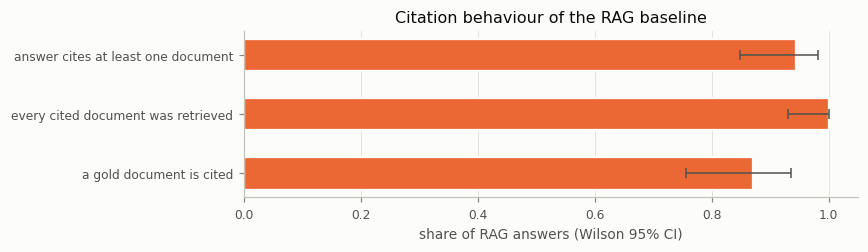

In [ ]:
main_pq = PER_QUERY[MAIN_COND].set_index("id")
bad = []
for k in B_KEYS:
    r = RUNS["rag"][k]
    if r["judge"]["verdict"] in ("PARTIALLY_GROUNDED", "NOT_GROUNDED"):
        qid = k.split("|")[0]
        bad.append(dict(key=k, verdict=r["judge"]["verdict"], recall_at_5=round(main_pq.loc[qid, "r_at_k"], 2),
                        unsupported=f"{r['judge']['n_unsupported']}/{r['judge']['n_claims']}", rationale=r["judge"]["rationale"][:150]))
bad_tab = pd.DataFrame(bad)
print(f"RAG answers not fully grounded: {len(bad)} of {len(B_KEYS)}")
if len(bad):
    display(bad_tab)
cit = [dict(key=k, n_cited=len(RUNS["rag"][k]["cited"]), cited_in_retrieved=all(c in RUNS["rag"][k]["retrieved"] for c in RUNS["rag"][k]["cited"]),
            cited_in_gold=any(c in ITEM_GOLD[k.split("|")[0]] for c in RUNS["rag"][k]["cited"])) for k in B_KEYS]
cit_tab = pd.DataFrame(cit)
cit_summary = pd.DataFrame([
    dict(check="answer cites at least one document", count=int((cit_tab.n_cited > 0).sum()), out_of=len(cit_tab)),
    dict(check="every cited document was retrieved", count=int(cit_tab[cit_tab.n_cited > 0].cited_in_retrieved.sum()), out_of=int((cit_tab.n_cited > 0).sum())),
    dict(check="a gold document is cited", count=int(cit_tab.cited_in_gold.sum()), out_of=len(cit_tab))]).set_index("check")
cit_summary["rate"] = [wilson(int(r["count"]), int(r.out_of)) for _, r in cit_summary.iterrows()]
display(cit_summary.assign(rate=cit_summary.rate.map(ci_text)))
fig, ax = plt.subplots(figsize=(8, 2.4))
rates = list(cit_summary.rate)
ax.barh(range(3), [r[0] for r in rates], xerr=[[r[0] - r[1] for r in rates], [r[2] - r[0] for r in rates]], color=COLOR["rag"],
        edgecolor=SURFACE, linewidth=1.5, error_kw=dict(ecolor=INK2, elinewidth=1, capsize=3), height=0.55)
ax.set_yticks(range(3), cit_summary.index); ax.invert_yaxis(); ax.set_xlim(0, 1.05); ax.grid(axis="y", visible=False)
ax.set_xlabel("share of RAG answers (Wilson 95% CI)"); ax.set_title("Citation behaviour of the RAG baseline")
finish(fig, "b_citations")
RESULTS["part_b"] = dict(verdicts=dist.to_dict(), rag_not_grounded=bad, citations=cit_tab.mean(numeric_only=True).round(3).to_dict())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שתי תשובות RAG לא קיבלו GROUNDED, כל אחת צד אחר של שאלת הניתוח:</p>
<ul>
<li>Q02 seed 1, recall@5 0.5 — נספח III לא בהקשר. המודל ענה מסעיף 6(1) (רכיבי בטיחות) ובנה ספקולציה. כשל אחזור</li>
<li>Q05 seed 3, recall@5 1.0 — סעיף 5 בהקשר, אך החריגים של 5(1)(h) נמנו כאיסורים: כשל סינתזה. השופט נתן PARTIALLY_GROUNDED, אבל ספר 0 מ-⁠9 טענות לא-נתמכות</li>
</ul>
<p>ציטוטים: 51 מ-⁠54 תשובות מצטטות, כולן מהמוחזרים, ו-⁠47 מצטטות זהב; אין מזהים מומצאים. מ-⁠7 התשובות שלא מצטטות זהב, 3 בלי ציטוט כלל ו-⁠4 מצטטות מסמך אחר: 3 ב-⁠Q03 ואחת ב-⁠Q07.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת זיכרון של closed-book: כמה תשובות מזכירות מספר סעיף, וכמה סעיף זהב; סימן לכך שהמודל ראה את החוק באימון, כאזהרת הרצאה&nbsp;4.</p>
</div>

In [ ]:
mem = []
for k in B_KEYS:
    a = RUNS["llm_only"][k]["answer"]
    nums = {f"art-{n}" for n in re.findall(r"Article\s+(\d{1,3})", a)}
    mem.append(dict(key=k, mentions_articles=bool(nums), n_articles=len(nums), correct_article=bool(nums & ITEM_GOLD[k.split("|")[0]])))
mem_tab = pd.DataFrame(mem)
print(f"closed-book answers naming an article number: {int(mem_tab.mentions_articles.sum())} of {len(mem_tab)} | "
      f"naming a gold article: {int(mem_tab.correct_article.sum())}")
RESULTS["part_b"]["memorization"] = mem_tab.mean(numeric_only=True).round(3).to_dict()

closed-book answers naming an article number: 2 of 54 | naming a gold article: 0


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>רק 2 מתוך 54 תשובות closed-book מזכירות מספר סעיף, ואף אחת לא את הנכון. שתיהן ב-⁠Q12, עם סעיפים 4(3) ו-⁠4(2), בזמן שהחריג בסעיף 6(3). אין עדות שהמודל זוכר את מבנה החוק; הוא נותן מספרים ומושגים כלליים, וחלקם אולי מטיוטת החוק, כהסבר האפשרי בממצאים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>unsupported_share: חלק הטענות הלא-נתמכות בשאילתה ותנאי, על שלושת ה-⁠seeds יחד, מתוך כל הטענות; פסקים לא תקינים לא נספרים.</p>
</div>

In [ ]:
def unsupported_share(cond, qid):
    recs = [RUNS[cond][rkey(qid, s)]["judge"] for s in CFG["seeds"]]
    claims = sum(r["n_claims"] for r in recs if r["verdict"] in VERDICTS)
    return sum(r["n_unsupported"] for r in recs if r["verdict"] in VERDICTS) / claims if claims else np.nan

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טבלה וגרף: חלק הטענות הלא-נתמכות בכל שאילתה, closed-book מול RAG; הטבלה ממוינת מהגבוה לנמוך לפי&nbsp;closed-book.</p>
</div>

,closed-book,RAG,topic
Q07,1.00,0.00,Above what amount of training compute is a general-purpose A
Q03,1.00,0.00,When do the obligations for general-purpose AI models start
Q17,0.91,0.00,What must the technical documentation of a high-risk AI syst
Q13,0.47,0.00,What are the obligations of deployers of high-risk AI system
Q16,0.43,0.00,For how long must providers keep the technical documentation
Q18,0.38,0.00,Who can be fined for supplying incorrect information to the
Q12,0.25,0.00,When is a system listed in Annex III nevertheless not consid
Q01,0.25,0.00,What is a 'provider' under the AI Act?
Q11,0.17,0.00,What must the risk management system of a high-risk AI syste
Q04,0.15,0.00,Does the AI Act apply to free and open-source AI models?


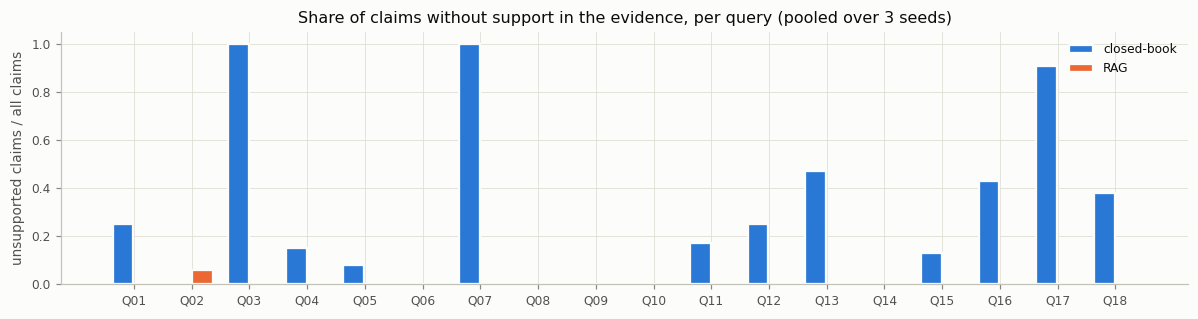

In [ ]:
uns = pd.DataFrame({"closed-book": [unsupported_share("llm_only", q["id"]) for q in QUERIES], "RAG": [unsupported_share("rag", q["id"]) for q in QUERIES]},
                   index=[q["id"] for q in QUERIES]).round(2)
uns["topic"] = [q["q"][:60] for q in QUERIES]
display(uns.sort_values("closed-book", ascending=False))
fig, ax = plt.subplots(figsize=(11, 3))
x = np.arange(len(uns))
ax.bar(x - 0.19, uns["closed-book"], width=0.36, color=COLOR["llm_only"], label="closed-book", edgecolor=SURFACE, linewidth=1.5)
ax.bar(x + 0.19, uns["RAG"], width=0.36, color=COLOR["rag"], label="RAG", edgecolor=SURFACE, linewidth=1.5)
ax.set_xticks(x, uns.index); ax.set_ylim(0, 1.05); ax.set_ylabel("unsupported claims / all claims"); ax.legend()
ax.set_title(f"Share of claims without support in the evidence, per query (pooled over {len(CFG['seeds'])} seeds)")
finish(fig, "b_unsupported_per_query")
RESULTS["part_b"]["unsupported_share"] = uns.drop(columns="topic").to_dict()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ב-⁠RAG כמעט אין טענות לא-נתמכות: 1 מתוך 16 ב-⁠Q02, אפס בשאר. ב-⁠closed-book ההזיה מרוכזת בשאלות שתשובתן מספר, תאריך או רשימה, כמו סף ב-⁠Q07 (1.00), תאריך ב-⁠Q03 (1.00), תיעוד טכני ב-⁠Q17 (0.91), חובות deployer ב-⁠Q13 (0.47), משך שמירה ב-⁠Q16 (0.43) וקנס ב-⁠Q18 (0.38). בשאלות עקרוניות (Q08, Q09, Q14) אפס, ו-⁠Q06 מקבלת 0 אף שהתשובה, 30 מיליון, שגויה: השופט הקל, ואפילו ב-⁠seed 3, שנפסק NOT_GROUNDED, לא סימן אף טענה כלא-נתמכת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק ב׳:</p>
<ul>
<li>ה-⁠RAG כמעט מבטל הזיה פתוחה: 52 מ-⁠54 GROUNDED מול 21 ב-⁠closed-book (0.96 מול 0.39); ברמת הטענה, 0.4% לא-נתמכות מול 26%</li>
<li>להזיות closed-book דפוס: מספרים, תאריכים ורשימות. בכל 3 ה-⁠seeds: 30 מיליון ל-⁠Q06 (בחוק 35 מיליון או 7%), מיליארד פרמטרים ל-⁠Q07 (בחוק 10^25 FLOP), 6.6.2024 ל-⁠Q03 (בחוק 2.8.2025); ב-⁠Q16 שלוש שנים ללוגים במקום חצי שנה, בשני seeds, וב-⁠Q05 מושגים מומצאים</li>
<li>הסבר אפשרי: 30 מיליון, וגם 10 מיליון או 2% ב-⁠Q18 seed 2, הם סכומי הצעת הנציבות מ-⁠2021, 30 מיליון או 6%, 20 מיליון או 4%, 10 מיליון או 2%; בנוסח הסופי שונו ל-⁠35 מיליון או 7% ול-⁠7.5 מיליון או 1%. אם כך, המודל זוכר טיוטה, וגם 6% ו-⁠2% שהסוכן המציא בחלק ד׳ (T04, T05, T09) הם מדרגות ההצעה. ובבדיקת הזיכרון, 2 מתוך 54 תשובות מזכירות מספר סעיף, ואף אחת לא את הנכון</li>
<li>לשאלת הניתוח, RAG המציא לפחות פעמיים כשמסמך הזהב היה בהקשר, שתיהן כשלי סינתזה: Q05 seed 3 (החריגים של 5(1)(h) כאיסורים) ו-⁠Q18 seed 2 (טווח 750 אלף עד 15 מיליון, מסעיפים 99(5) ו-⁠101, במקום 7.5 מיליון של 99(5)). 750 אלף אינו בקטעי Q18, ובכל זאת השופט אישר, כנראה כי שאר המספרים בראיות. רק 7 מ-⁠18 השאילתות נבדקות בלי שופט, ולכן זה חסם תחתון</li>
<li>הסיכון שנשאר ב-⁠RAG הוא כשל אחזור, שלא נראה כהזיה: ב-⁠Q03 סעיף 113 לא אוחזר, והמודל ענה לפי סעיף 111 שהמועד 2.8.2027, בכל שלושת ה-⁠seeds: מבוסס ושגוי. 2.8.2027 נכון למודלים שכבר בשוק, כך שזה בלבול תחולה, לא המצאה. גם ב-⁠Q02 נספח III חסר. בבדיקת הנכונות, 6 מ-⁠20 תשובות RAG מבוססות שגויות, וחמש מהן כשלי אחזור</li>
<li>השופט מקל עם closed-book: 30 מיליון ב-⁠Q06 אושר בשני seeds, וכך low-risk ב-⁠Q02 וסעיף 4(2) ב-⁠Q12; 21 ה-⁠GROUNDED הם גבול עליון</li>
</ul>
<p>ה-⁠RAG החליף המצאת מספרים בתשובות מבוססות; השגיאות שנותרו הן בעיקר אחזור.</p>
<p>מה לא ניתן להסיק: ה-⁠groundedness אינו נכונות; NOT_GROUNDED של closed-book הוא "לא נתמך בקטעי ה-⁠RAG"; שאילתה אחת שווה&nbsp;5.6%.</p>
</div>

In [ ]:
checkpoint("Part B")

[checkpoint after Part B] /content/drive/MyDrive/FM/Final_Project/outputs/project_results.json (0.12 MB) | cache hits 0, misses 216


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ג׳ — שכבת סוכן: function calling מול ReAct</p>
<ul>
<li>חמישה כלים: חיפוש בחוק מעל הצינור של חלק א׳, שליפת סעיף או נספח, מרשם חברות מדומה, מחשבון, תאריך</li>
<li>גישה ראשונה, function calling מובנה: סכמות הכלים בתבנית השיחה, ופלט בבלוקי tool_call לפי הפרוטוקול של Qwen</li>
<li>גישה שנייה, לולאת ReAct ידנית: המודל כותב Thought, Action ו-⁠Action Input, נעצר לפני Observation, והתוצאה מוזרקת כטקסט</li>
<li>10 משימות קבועות, 7 דורשות שרשרת של 2–3 כלים, כמו מרשם, חוק, מחשבון, או חוק, תאריך, מחשבון</li>
<li>הצלחה: שורת ANSWER מול ערך שנרשם מראש, reward מבוסס-כלל (הרצאה 6); בנפרד, שרשור תקין של הכלים</li>
<li>3 seeds לכל צירוף, 60 ריצות, ו-⁠pass^3 (הרצאה 6): הצלחה בכל 3 ה-⁠seeds</li>
<li>שאלת הניתוח: אילו משימות דרשו שרשור נכון, והיכן הסוכן התבלבל בסדר או קרא לכלי בלי מידע מספיק</li>
</ul>
<p>ציפיות מראש: ב-⁠function calling, שבו הסכמות הכלים עוברות בתבנית הרשמית של Qwen, פחות שגיאות פורמט מ-⁠ReAct; בקנסות, חישוב בראש או סכום בלי האחוז.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מרשם מדומה של שש חברות, כפי שהמפרט מציע; בטבלה עמודת קנס מחושבת, ובגרף מחזור בסולם לוגריתמי מול הקנס המרבי לפי סעיף&nbsp;99.</p>
</div>

,country,annual_turnover_eur,employees,sme,role,ai_use,max_fine_art99_prohibited
Helios Analytics,Germany,2000000000,4800,False,deployer,emotion recognition of employees during their shifts,140000000.0
NordicHire,Sweden,120000000,600,False,deployer,AI ranking and filtering of job applications,35000000.0
Brightpath Tutors,Ireland,4000000,35,True,deployer,emotion recognition of students during online lessons,280000.0
Lumen Models,France,800000000,1500,False,provider,general-purpose AI model trained with 4e25 floating point operations,56000000.0
Meadow Bank,Spain,300000000,2000,False,deployer,creditworthiness scoring of loan applicants,35000000.0
Civitas Security,Netherlands,60000000,300,False,provider,real-time remote biometric identification for a city police force,35000000.0


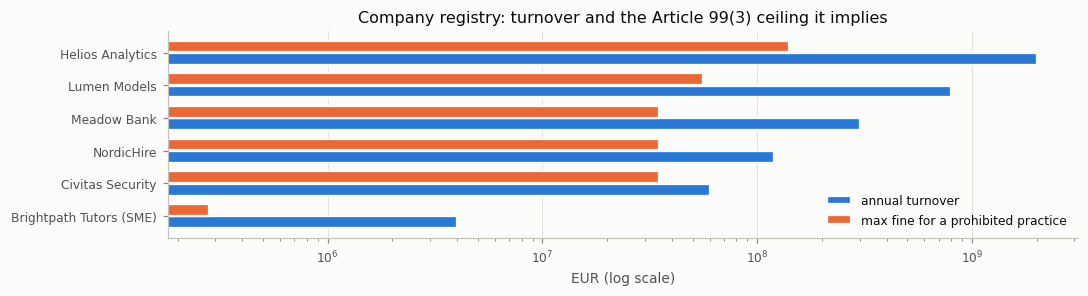

In [ ]:
REGISTRY = {
    "Helios Analytics": dict(country="Germany", annual_turnover_eur=2000000000, employees=4800, sme=False, role="deployer",
                             ai_use="emotion recognition of employees during their shifts"),
    "NordicHire": dict(country="Sweden", annual_turnover_eur=120000000, employees=600, sme=False, role="deployer",
                       ai_use="AI ranking and filtering of job applications"),
    "Brightpath Tutors": dict(country="Ireland", annual_turnover_eur=4000000, employees=35, sme=True, role="deployer",
                              ai_use="emotion recognition of students during online lessons"),
    "Lumen Models": dict(country="France", annual_turnover_eur=800000000, employees=1500, sme=False, role="provider",
                         ai_use="general-purpose AI model trained with 4e25 floating point operations"),
    "Meadow Bank": dict(country="Spain", annual_turnover_eur=300000000, employees=2000, sme=False, role="deployer",
                        ai_use="creditworthiness scoring of loan applicants"),
    "Civitas Security": dict(country="Netherlands", annual_turnover_eur=60000000, employees=300, sme=False, role="provider",
                             ai_use="real-time remote biometric identification for a city police force"),
}
reg_tab = pd.DataFrame(REGISTRY).T
reg_tab["max_fine_art99_prohibited"] = [min(35e6, 0.07 * t) if s else max(35e6, 0.07 * t) for t, s in zip(reg_tab.annual_turnover_eur.astype(float), reg_tab.sme)]
display(reg_tab)
fig, ax = plt.subplots(figsize=(10, 2.8))
order = reg_tab.annual_turnover_eur.astype(float).sort_values().index
y = np.arange(len(order))
ax.barh(y - 0.19, reg_tab.loc[order, "annual_turnover_eur"].astype(float), height=0.36, color=PAL[0], label="annual turnover", edgecolor=SURFACE, linewidth=1.5)
ax.barh(y + 0.19, reg_tab.loc[order, "max_fine_art99_prohibited"].astype(float), height=0.36, color=PAL[1], label="max fine for a prohibited practice", edgecolor=SURFACE, linewidth=1.5)
ax.set_yticks(y, [f"{c}{' (SME)' if reg_tab.loc[c, 'sme'] else ''}" for c in order]); ax.set_xscale("log"); ax.grid(axis="y", visible=False)
ax.set_xlabel("EUR (log scale)"); ax.legend(loc="lower right"); ax.set_title("Company registry: turnover and the Article 99(3) ceiling it implies")
finish(fig, "c_registry")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ארבע חברות נבנו למשימות: לקנס על זיהוי רגשות ב-⁠Helios (T04), לסיווג לפי נספח III ב-⁠NordicHire (T03), לסעיף 99(6) ב-⁠Brightpath, ה-⁠SME היחידה (T05), ולקנס על ספק GPAI ב-⁠Lumen (T09); שתי האחרות אינן באף משימה. העמודה האחרונה מחושבת ואינה במרשם: 140 מיליון ל-⁠Helios (7% מ-⁠2 מיליארד), 280 אלף ל-⁠Brightpath (7% מ-⁠4 מיליון, הנמוך מבין 35 מיליון ו-⁠7%). טווח המחזורים: 4 מיליון עד 2 מיליארד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחשבון מתיר רק פונקציות ואופרטורים מוגדרים. בהרצה מוקדמת, שאינה שמורה כאן, נכשלו תחבירים לחישוב ימים, ולכן המחשבון הורחב לתאריכים; לפי הרצאה 8, מתאימים את ה-⁠API למודל.</p>
</div>

In [ ]:
ALLOWED_FUNCS = {k: getattr(math, k) for k in ("sqrt", "log", "log2", "log10", "exp", "floor", "ceil")}
ALLOWED_FUNCS.update(abs=abs, round=round, min=min, max=max)
OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv, ast.Pow: operator.pow,
       ast.Mod: operator.mod, ast.FloorDiv: operator.floordiv, ast.USub: operator.neg, ast.UAdd: operator.pos}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>safe_eval: מחשבת ביטוי מעץ ה-⁠ast, בלי eval; מותרים רק חשבון, ALLOWED_FUNCS, pi, e ותאריכים כמספר ימים, גם ב-⁠datetime וב-.days.</p>
</div>

In [ ]:
def safe_eval(node):
    if isinstance(node, ast.Expression):
        return safe_eval(node.body)
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in OPS:
        return OPS[type(node.op)](safe_eval(node.left), safe_eval(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in OPS:
        return OPS[type(node.op)](safe_eval(node.operand))
    if isinstance(node, ast.Call) and isinstance(node.func, (ast.Name, ast.Attribute)):
        fname = node.func.id if isinstance(node.func, ast.Name) else node.func.attr
        if fname in ("date", "datetime"):
            args = [a.value if isinstance(a, ast.Constant) else safe_eval(a) for a in node.args]
            if len(args) == 1 and isinstance(args[0], str):
                return dt.date.fromisoformat(args[0].strip()[:10]).toordinal()
            if len(args) == 1 and isinstance(args[0], (int, float)):
                return int(args[0])
            if len(args) != 3:
                raise ValueError("date() takes a YYYY-MM-DD string or three numbers: year, month, day")
            return dt.date(int(args[0]), int(args[1]), int(args[2])).toordinal()
        if fname in ALLOWED_FUNCS:
            return ALLOWED_FUNCS[fname](*[safe_eval(a) for a in node.args])
    if isinstance(node, ast.Attribute) and node.attr == "days":
        return safe_eval(node.value)
    if isinstance(node, ast.Name) and node.id in ("pi", "e"):
        return getattr(math, node.id)
    raise ValueError(f"unsupported expression element: {type(node).__name__}")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>tool_calculator: מנקה מפרידי אלפים ומטבע, ממיר ^, ×, אחוזים ותאריכים לתחביר תקין ומחשב; ביטוי לא חוקי נרשם כשגיאת ארגומנט.</p>
</div>

In [ ]:
def tool_calculator(expression):
    expr = str(expression)
    expr = re.sub(r"(?<=\d),(?=\d{3}(?!\d))", "", expr)
    expr = re.sub(r"['\x22](\d{4}-\d{2}-\d{2})['\x22]", r"\1", expr)
    expr = re.sub(r"(?<![\d.])(\d{4})-(\d{2})-(\d{2})(?![\d.])", lambda m: f"date({m.group(1)},{int(m.group(2))},{int(m.group(3))})", expr)
    expr = re.sub(r"(\d+(?:\.\d+)?)\s*%", r"(\1/100)", expr)
    expr = re.sub(r"(EUR|euros?|€|\$)", "", expr, flags=re.I).replace("^", "**").replace("×", "*").replace("x10", "*10").strip()
    val = safe_eval(ast.parse(expr, mode="eval"))
    return str(round(val, 6) if isinstance(val, float) else val)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>tool_company_registry: מחפש חברה בלי תלות ברישיות, גם חלקית, ומחזיר JSON; שם לא מוכר נרשם כשגיאת ארגומנט, עם רשימת החברות.</p>
</div>

In [ ]:
def tool_company_registry(name):
    key = str(name).strip().lower()
    for company, rec in REGISTRY.items():
        if key == company.lower() or key in company.lower() or company.lower() in key:
            return json.dumps(dict(name=company, **rec))
    raise KeyError(f"no company named '{name}' in the registry; known companies: {list(REGISTRY)}")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>parse_ref: מפענחת הפניה משפטית, כמו Article 99(3), Art. 99 או Annex III point 4, לסוג, מספר ותת-חלק; כישלון מחזיר דוגמה לפורמט.</p>
</div>

In [ ]:
def parse_ref(ref):
    s = str(ref).strip()
    m = re.search(r"art(?:icle|\.)?\s*(\d{1,3})(?:\s*(?:\(|paragraph|para\.?|par\.?)\s*(\d{1,2}))?", s, re.I)
    if m:
        return "article", int(m.group(1)), (int(m.group(2)) if m.group(2) else None)
    m = re.search(r"annex\s*([ivx]+)(?:\D{0,20}(?:point|section|sec\.?|item)\s*(\d{1,2}))?", s, re.I)
    if m:
        return "annex", m.group(1).upper(), (int(m.group(2)) if m.group(2) else None)
    raise KeyError(f"cannot parse the reference '{s}'; use a form like 'Article 99(3)' or 'Annex III point 4'")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>tool_get_provision: מחזיר פסקה, סעיף, פריט נספח או נספח; פסקה שאינה בדאטה, כמו 3(1) או 18(5), חוזרת כסעיף שלם בלי הודעה; מעל 9,000 תווים נחתך עם הערה.</p>
</div>

In [ ]:
def tool_get_provision(reference):
    kind, number, sub = parse_ref(reference)
    if kind == "article":
        doc_id = f"art-{number}"
        if doc_id not in DOC:
            raise KeyError(f"there is no Article {number}; the Regulation has Articles 1-113")
        if sub is not None:
            hit = ROWS[(ROWS.chunk_type == "paragraph") & (ROWS.article_no == number) & (ROWS.paragraph_no == sub)]
            if len(hit):
                return f"[{doc_id} | {hit.citation_label.iloc[0]}] {hit.text.iloc[0]}"
        text = DOC[doc_id]["text"]
    else:
        doc_id = f"anx-{number}"
        if doc_id not in DOC:
            raise KeyError(f"there is no Annex {number}; the Regulation has Annexes I-XIII")
        if sub is not None:
            hit = ROWS[(ROWS.chunk_type == "annex_item") & (ROWS.annex_no == number) & (ROWS.annex_section.astype(str).str.replace(r"\D", "", regex=True) == str(sub))]
            if len(hit) == 0:
                raise KeyError(f"Annex {number} has no point {sub}")
            return f"[{doc_id} | {hit.citation_label.iloc[0]}] {hit.text.iloc[0]}"
        text = DOC[doc_id]["text"]
    cap = CFG["provision_chars"]
    note = f" ... (truncated at {cap} characters; ask for a specific paragraph or point, or use search_act)" if len(text) > cap else ""
    return f"[{doc_id} | {DOC[doc_id]['title']}] {text[:cap]}{note}"

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>tool_search_act: חיפוש בצינור של חלק א׳, hybrid ואז reranking; מחזיר k קטעים, 5 כברירת מחדל ועד 8, בפורמט הראיה האחיד.</p>
</div>

In [ ]:
def tool_search_act(query, k=5):
    top, _ = retrieve(str(query), k=max(1, min(int(k), 8)))
    return "\n\n".join(passage(c) for c in top)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>run_date: תאריך כלי today, נשמר פעם אחת; ברירת המחדל הקבועה, 1.10.2026, נותנת בהרצה בלי Drive את אותה תשובה ל-⁠T06 (305 ימים).</p>
</div>

In [ ]:
def run_date():
    path = os.path.join(RUN_DIR, "run_date.txt")
    if not os.path.exists(path):
        with open(path, "w") as f:
            f.write(os.environ.get("PROJ_RUN_DATE", "2026-10-01"))
    return dt.date.fromisoformat(open(path).read().strip())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>tool_today: מחזיר את תאריך הריצה בפורמט&nbsp;YYYY-MM-DD.</p>
</div>

In [ ]:
def tool_today():
    return RUN_DATE.isoformat()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חמשת הכלים מוגדרים עם תיאור וסכמת JSON; אותה סכמה עוברת ל-⁠function calling ול-⁠ReAct, ולפי הרצאה 7 התיאור הוא ה-⁠API שהמודל קורא.</p>
</div>

In [ ]:
RUN_DATE = run_date()
TOOLS = {
    "search_act": dict(fn=tool_search_act, description="Search the text of the EU AI Act (Regulation 2024/1689) and return the most relevant passages with their article or annex ids.",
                       params={"type": "object", "properties": {"query": {"type": "string", "description": "search query"}, "k": {"type": "integer", "description": "number of passages, default 5"}}, "required": ["query"]}),
    "get_provision": dict(fn=tool_get_provision, description="Return the exact text of a provision of the EU AI Act by reference, e.g. 'Article 99(3)', 'Article 113', 'Annex III point 4' or 'Annex III'.",
                          params={"type": "object", "properties": {"reference": {"type": "string", "description": "the reference, e.g. 'Article 99(3)' or 'Annex III point 4'"}}, "required": ["reference"]}),
    "company_registry": dict(fn=tool_company_registry, description="Look up a company in the registry and return its country, annual turnover in euros, number of employees, SME status, role under the Act and AI use.",
                             params={"type": "object", "properties": {"name": {"type": "string", "description": "company name"}}, "required": ["name"]}),
    "calculator": dict(fn=tool_calculator, description="Evaluate an arithmetic expression, e.g. '0.07*2000000000' or 'max(35000000, 0.07*2000000000)'. Write percentages as decimals (7% -> 0.07). Supports + - * / ** min max abs. Dates: write them as YYYY-MM-DD or date(YYYY, M, D); subtracting two dates gives the number of days between them, e.g. '2027-08-02 - 2026-09-29'.",
                       params={"type": "object", "properties": {"expression": {"type": "string", "description": "arithmetic expression"}}, "required": ["expression"]}),
    "today": dict(fn=tool_today, description="Return today's date in ISO format (YYYY-MM-DD). Takes no arguments.",
                  params={"type": "object", "properties": {}, "required": []}),
}
TOOL_SCHEMAS = [{"type": "function", "function": {"name": n, "description": t["description"], "parameters": t["params"]}} for n, t in TOOLS.items()]
print("run date:", RUN_DATE)
display(pd.DataFrame([dict(tool=n, arguments=", ".join(f"{k}{' (required)' if k in t['params']['required'] else ''}" for k in t["params"]["properties"]) or "none",
                           description=t["description"][:120]) for n, t in TOOLS.items()]).set_index("tool"))

run date: 2026-10-01


,arguments,description
tool,,
search_act,"query (required), k",Search the text of the EU AI Act (Regulation 2024/1689) and return the most relevant p...
get_provision,reference (required),"Return the exact text of a provision of the EU AI Act by reference, e.g. 'Article 99(3..."
company_registry,name (required),"Look up a company in the registry and return its country, annual turnover in euros, nu..."
calculator,expression (required),"Evaluate an arithmetic expression, e.g. '0.07*2000000000' or 'max(35000000, 0.07*20000..."
today,none,Return today's date in ISO format (YYYY-MM-DD). Takes no arguments.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חמישה כלים: שניים לחוק, search_act ו-⁠get_provision, ואחריהם המרשם, המחשבון והתאריך. לכל כלי ארגומנט חובה אחד לכל היותר, ורק ל-⁠search_act יש ארגומנט אופציונלי, k. בתיאורים יש דוגמאות, כמו הפורמט Article 99(3) וביטוי max במחשבון, כי התיאור הוא כל מה שהמודל יודע על הכלי. תאריך הריצה שנטען, 2026-10-01, קובע את התשובה ל-⁠T06, 305 ימים.</p>
<p>מגבלה: Annex III point 4, ביטוי ה-⁠max עם מחזור של 2 מיליארד והתאריך 2027-08-02 בדוגמאות הם התשובות או החישובים של T02–T04 ו-⁠T06. הראיה להעתקה: T08 ReAct seed 3 העתיק את ביטוי ה-⁠max ונכשל; T04 הצליחה 2 מ-⁠6, כך שההקלה, אם יש, קטנה. בניסוי חוזר הדוגמאות צריכות להיות ניטרליות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>execute_tool: מסווגת כל כשל כ-⁠hallucinated_tool, wrong_argument, tool_error או no_response (הרצאה 8), ותמיד מחזירה הודעה לתיקון.</p>
</div>

In [ ]:
def execute_tool(name, arguments):
    if name not in TOOLS:
        return dict(ok=False, result=f"ERROR: unknown tool '{name}'. Available tools: {list(TOOLS)}", error_kind="hallucinated_tool")
    spec = TOOLS[name]
    if not isinstance(arguments, dict):
        return dict(ok=False, result=f"ERROR: arguments must be a JSON object with keys {spec['params']['required']}", error_kind="wrong_argument")
    missing = [k for k in spec["params"]["required"] if k not in arguments]
    if missing:
        return dict(ok=False, result=f"ERROR: missing arguments {missing} for tool '{name}'", error_kind="wrong_argument")
    for k, v in list(arguments.items()):
        want = spec["params"]["properties"].get(k, {}).get("type")
        if want == "string" and not isinstance(v, str):
            return dict(ok=False, result=f"ERROR: argument '{k}' must be a plain string, got {type(v).__name__}", error_kind="wrong_argument")
        if want == "integer" and not isinstance(v, int):
            if isinstance(v, str) and v.strip().isdigit():
                arguments[k] = int(v)
            else:
                return dict(ok=False, result=f"ERROR: argument '{k}' must be an integer, got {v!r}", error_kind="wrong_argument")
    try:
        result = spec["fn"](**{k: v for k, v in arguments.items() if k in spec["params"]["properties"]})
    except (ValueError, KeyError, TypeError, SyntaxError, ZeroDivisionError, OverflowError, IndexError) as e:
        return dict(ok=False, result=f"ERROR: bad argument value: {type(e).__name__}: {e}", error_kind="wrong_argument")
    except Exception as e:
        return dict(ok=False, result=f"ERROR: {type(e).__name__}: {e}", error_kind="tool_error")
    if not str(result).strip():
        return dict(ok=False, result="ERROR: the tool returned nothing", error_kind="no_response")
    return dict(ok=True, result=str(result), error_kind=None)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת הכלים לפני הסוכן: 13 קריאות, כולל שני חישובי תאריך מהרצה מוקדמת, כלי מומצא, ארגומנט שגוי וסעיף שאינו קיים, לוודא שהכשלים מסווגים נכון.</p>
</div>

In [ ]:
DEMO_ROWS = []
for name, args in [("calculator", {"expression": "max(35,000,000, 0.07 * 2,000,000,000)"}), ("calculator", {"expression": "2027-08-02 - 2026-09-29"}),
                   ("calculator", {"expression": "(datetime.date(2027, 8, 2) - datetime.date('2026-09-29')).days"}), ("get_provision", {"reference": "Article 3(1)"}),
                   ("search_act", {"query": {"type": "string"}}), ("company_registry", {"name": "helios analytics"}),
                   ("get_provision", {"reference": "Article 99(3)"}), ("get_provision", {"reference": "Annex III point 4"}), ("today", {}),
                   ("search_act", {"query": "emotion recognition in the workplace", "k": 2}), ("weather", {"city": "Paris"}),
                   ("calculator", {"expr": "1+1"}), ("get_provision", {"reference": "Article 250"})]:
    r = execute_tool(name, args)
    DEMO_ROWS.append(dict(tool=name, arguments=json.dumps(args)[:70], ok=r["ok"], error_kind=r["error_kind"] or "-", result=r["result"][:90]))
display(pd.DataFrame(DEMO_ROWS))

,tool,arguments,ok,error_kind,result
0,calculator,"{""expression"": ""max(35,000,000, 0.07 * 2,000,000,000)""}",True,-,140000000.0
1,calculator,"{""expression"": ""2027-08-02 - 2026-09-29""}",True,-,307
2,calculator,"{""expression"": ""(datetime.date(2027, 8, 2) - datetime.date('2026-09-29",True,-,307
3,get_provision,"{""reference"": ""Article 3(1)""}",True,-,[art-3 | Article 3 — Definitions] Article 3 — Definitions\n\nFor the purposes of this ...
4,search_act,"{""query"": {""type"": ""string""}}",False,wrong_argument,"ERROR: argument 'query' must be a plain string, got dict"
5,company_registry,"{""name"": ""helios analytics""}",True,-,"{""name"": ""Helios Analytics"", ""country"": ""Germany"", ""annual_turnover_eur"": 2000000000, ..."
6,get_provision,"{""reference"": ""Article 99(3)""}",True,-,[art-99 | Art. 99(3) AI Act] Non-compliance with the prohibition of the AI practices r...
7,get_provision,"{""reference"": ""Annex III point 4""}",True,-,"[anx-III | Annex III, point 4 AI Act] Annex III — High-risk AI systems referred to in ..."
8,today,{},True,-,2026-10-01
9,search_act,"{""query"": ""emotion recognition in the workplace"", ""k"": 2}",True,-,[art-50 | Art. 50(3) AI Act] Article 50 — Transparency obligations for providers and d...


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>13 הקריאות מתנהגות כמצופה. תשע מצליחות, כולל חשבון עם מפרידי אלפים, הפרש תאריכים בכתיב ISO וביטוי date מקונן, ששניהם מחזירים 307 ימים, שם חברה באותיות קטנות ו-⁠Article 3(1), שאין לו פסקה ממוספרת בדאטה ולכן חוזר הסעיף כולו. ארבע נכשלות, כל אחת בסוג הכשל הנכון: סכמה במקום מחרוזת, expr במקום expression וסעיף 250, שאינו קיים, הן wrong_argument, ו-⁠weather הוא&nbsp;hallucinated_tool.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>answer_line: מחלצת את החלק שנבדק, הטקסט שאחרי ה-⁠ANSWER האחרון (גם מודגש או באותיות קטנות), ואחרת השורה האחרונה שאינה ריקה.</p>
</div>

In [ ]:
def answer_line(a):
    m = re.findall(r"^\s*\**ANSWER\**\s*:\s*(.+)$", a or "", re.M | re.I)
    if m:
        return m[-1].strip()
    lines = [l.strip() for l in (a or "").strip().splitlines() if l.strip()]
    return lines[-1] if lines else ""

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>nums_in: מחלצת מספרים מטקסט, כולל מפרידי אלפים, כתיב מדעי, מילות מספר ומכפילים, כך ש-⁠35 million ו-⁠35,000,000 נקראים כאותו ערך.</p>
</div>

In [ ]:
def nums_in(a):
    text = (a or "").lower().replace("€", " ")
    words = {"zero": 0, "one": 1, "two": 2, "three": 3, "four": 4, "five": 5, "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10, "eleven": 11, "twelve": 12}
    out = [float(v) for w, v in words.items() if re.search(rf"\b{w}\b", text)]
    for m in re.finditer(r"(-?\d[\d,]*\.?\d*(?:e[+-]?\d+)?)\s*(billion|million|thousand|bn|m\b|k\b)?", text):
        try:
            v = float(m.group(1).replace(",", ""))
        except ValueError:
            continue
        scale = {"billion": 1e9, "bn": 1e9, "million": 1e6, "m": 1e6, "thousand": 1e3, "k": 1e3}.get(m.group(2) or "", 1.0)
        out.append(v * scale)
        if scale != 1.0:
            out.append(v)
    return out

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>num_close: בודקת אם מספר כלשהו בשורת ה-⁠ANSWER קרוב ליעד בטווח tol, כך שמספרים מהנימוק עצמו לא נספרים.</p>
</div>

In [ ]:
def num_close(a, target, tol):
    return any(abs(x - target) <= tol for x in nums_in(answer_line(a)))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10 המשימות, בטבלה ובגרף. לכל משימה: קבוצות כלים לפי סדר (chain), כשכלים באותה קבוצה הם חלופות, כלי אחרון (last), מסמכי זהב ובדיקה. הקנסות לפי החוק: לפרקטיקה אסורה, הגבוה מבין 35 מיליון ו-⁠7% מהמחזור, ול-⁠SME הנמוך; לספק GPAI, הגבוה מבין 15 מיליון ו-⁠3%.</p>
</div>

10 tasks, 7 multi-step


,id,multi,steps,chain,task
0,T01,False,1,get_provision|search_act,"What is the maximum administrative fine, in euros, for non-compliance with the prohibi..."
1,T02,False,1,get_provision|search_act,Which point of Annex III of the EU AI Act covers AI systems used for the recruitment o...
2,T03,True,2,company_registry -> get_provision|search_act,Look up NordicHire in the company registry. Is the AI system it uses considered high-r...
3,T04,True,3,company_registry -> get_provision|search_act -> calculator,Look up Helios Analytics in the company registry. Is its AI use a prohibited practice ...
4,T05,True,3,company_registry -> get_provision|search_act -> calculator,Look up Brightpath Tutors in the company registry. Assuming its AI use is a prohibited...
5,T06,True,3,get_provision|search_act -> today -> calculator,"According to Article 113 of the EU AI Act, from which date do Article 6(1) and its cor..."
6,T07,True,2,get_provision|search_act -> calculator,A general-purpose AI model was trained with 4 x 10^25 floating point operations. Accor...
7,T08,True,2,get_provision|search_act -> calculator,"Under Article 99 of the EU AI Act, what is the difference in euros between the maximum..."
8,T09,True,3,company_registry -> get_provision|search_act -> calculator,Look up Lumen Models in the company registry. As a provider of a general-purpose AI mo...
9,T10,False,1,get_provision|search_act,For at least how many months must deployers of high-risk AI systems keep the logs auto...


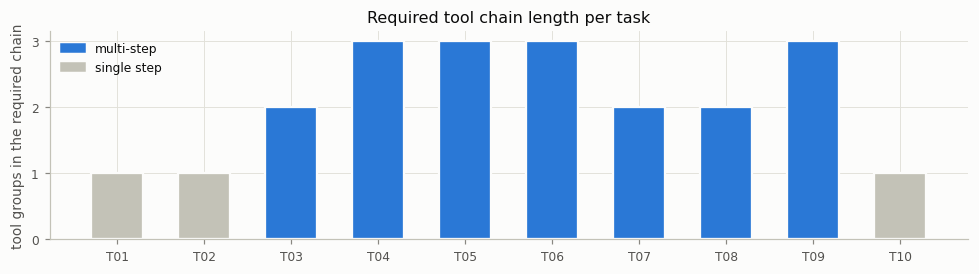

In [ ]:
LAW = {"search_act", "get_provision"}
TASKS = [
    dict(id="T01", multi=False, chain=[LAW], last=None, gold=["art-99"],
         q="What is the maximum administrative fine, in euros, for non-compliance with the prohibited AI practices of Article 5 of the EU AI Act? Put only the amount in euros on the ANSWER line.",
         check=lambda a: num_close(a, 35e6, 1)),
    dict(id="T02", multi=False, chain=[LAW], last=None, gold=["anx-III"],
         q="Which point of Annex III of the EU AI Act covers AI systems used for the recruitment or selection of natural persons? Put only the point number on the ANSWER line.",
         check=lambda a: num_close(a, 4, 0)),
    dict(id="T03", multi=True, chain=[{"company_registry"}, LAW], last=None, gold=["anx-III", "art-6"],
         q="Look up NordicHire in the company registry. Is the AI system it uses considered high-risk under the EU AI Act, and which point of Annex III applies? State both, and put only the Annex III point number on the ANSWER line.",
         check=lambda a: num_close(a, 4, 0) and "high-risk" in (a or "").lower()),
    dict(id="T04", multi=True, chain=[{"company_registry"}, LAW, {"calculator"}], last="calculator", gold=["art-5", "art-99"],
         q="Look up Helios Analytics in the company registry. Is its AI use a prohibited practice under Article 5 of the EU AI Act? If so, compute the maximum administrative fine it could face under Article 99 given its annual turnover, and put only that amount in euros on the ANSWER line.",
         check=lambda a: num_close(a, 140e6, 1e6)),
    dict(id="T05", multi=True, chain=[{"company_registry"}, LAW, {"calculator"}], last="calculator", gold=["art-99"],
         q="Look up Brightpath Tutors in the company registry. Assuming its AI use is a prohibited practice under Article 5, what is the maximum administrative fine it could face under Article 99 of the EU AI Act, taking into account the special rule for SMEs? Put only the amount in euros on the ANSWER line.",
         check=lambda a: num_close(a, 280000, 1000)),
    dict(id="T06", multi=True, chain=[LAW, {"today"}, {"calculator"}], last="calculator", gold=["art-113"],
         q="According to Article 113 of the EU AI Act, from which date do Article 6(1) and its corresponding obligations apply? How many days are there from today until that date? Put only the number of days on the ANSWER line.",
         check=lambda a: num_close(a, (dt.date(2027, 8, 2) - RUN_DATE).days, 1)),
    dict(id="T07", multi=True, chain=[LAW, {"calculator"}], last="calculator", gold=["art-51"],
         q="A general-purpose AI model was trained with 4 x 10^25 floating point operations. According to Article 51 of the EU AI Act, is it presumed to have high impact capabilities, that is systemic risk? By what factor does its training compute exceed the threshold? Put only the factor on the ANSWER line.",
         check=lambda a: num_close(a, 4, 0.05) and any(w in (a or "").lower() for w in ("yes", "presumed"))),
    dict(id="T08", multi=True, chain=[LAW, {"calculator"}], last="calculator", gold=["art-99"],
         q="Under Article 99 of the EU AI Act, what is the difference in euros between the maximum fixed fine for prohibited practices and the maximum fixed fine for supplying incorrect, incomplete or misleading information to the authorities? Put only the difference in euros on the ANSWER line.",
         check=lambda a: num_close(a, 27.5e6, 1e5)),
    dict(id="T09", multi=True, chain=[{"company_registry"}, LAW, {"calculator"}], last="calculator", gold=["art-101"],
         q="Look up Lumen Models in the company registry. As a provider of a general-purpose AI model, what is the maximum fine it could face under Article 101 of the EU AI Act, given its annual turnover? Put only the amount in euros on the ANSWER line.",
         check=lambda a: num_close(a, 24e6, 1e5)),
    dict(id="T10", multi=False, chain=[LAW], last=None, gold=["art-26"],
         q="For at least how many months must deployers of high-risk AI systems keep the logs automatically generated by the system, according to Article 26 of the EU AI Act? Put only the number of months on the ANSWER line.",
         check=lambda a: num_close(a, 6, 0)),
]
if SMOKE:
    TASKS = [TASKS[1], TASKS[3], TASKS[5]]
ITEM_TEXT.update({t["id"]: t["q"] for t in TASKS})
ITEM_GOLD.update({t["id"]: set(t["gold"]) for t in TASKS})
TASK_BY_ID = {t["id"]: t for t in TASKS}
print(len(TASKS), "tasks,", sum(t["multi"] for t in TASKS), "multi-step")
task_tab = pd.DataFrame([dict(id=t["id"], multi=t["multi"], steps=len(t["chain"]), chain=" -> ".join("|".join(sorted(g)) for g in t["chain"]), task=t["q"][:110]) for t in TASKS])
display(task_tab)
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.bar(range(len(task_tab)), task_tab.steps, color=[PAL[0] if m else BASE for m in task_tab.multi], edgecolor=SURFACE, linewidth=1.5, width=0.6)
ax.set_xticks(range(len(task_tab)), task_tab.id); ax.set_yticks(range(0, int(task_tab.steps.max()) + 1)); ax.set_ylabel("tool groups in the required chain")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=PAL[0]), plt.Rectangle((0, 0), 1, 1, color=BASE)], ["multi-step", "single step"], loc="upper left")
ax.set_title("Required tool chain length per task")
finish(fig, "c_tasks")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10 משימות, 7 מהן רב-שלביות. ארבע דורשות שלוש קבוצות כלים (T04, T05, T06, T09), שלוש דורשות שתיים (T03, T07, T08), ושלוש הן צעד אחד (T01, T02, T10). בשש משימות החישוב המחשבון חייב לבוא אחרון, כפי ש-⁠chain_ok יבדוק בהמשך. כל הבדיקות אוטומטיות מול ערך ידוע, בלי שופט. ב-⁠T03 וב-⁠T07 נדרשת גם מילה בתשובה: high-risk, או yes או presumed; הבדיקה היא תת-מחרוזת ואינה מזהה שלילה: ב-⁠T03 FC seed 2 התשובה נטתה ל-⁠low-risk וכתבה not high-risk, ובכל זאת נספרה כהצלחה, כי שורת ה-⁠ANSWER, 4, נכונה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפרומפטים של שתי הגישות. בשתיהן: לא לחשב בראש אלא במחשבון, אחוזים כשבר עשרוני, כלי אחד בכל פעם ואותה הנחיית ANSWER. רק ב-⁠function&nbsp;calling מפורט מתי לפנות לכלי, וזהו גורם מבלבל בהשוואה, ראו חלק ד׳ והמגבלות. ב-⁠ReAct הכלים מתוארים כטקסט, והמודל עוצר אחרי Action&nbsp;Input; ה-⁠Observation מהמערכת.</p>
</div>

In [ ]:
FC_SYSTEM = ("You are a careful assistant with tools, answering questions about the EU AI Act. Use a tool whenever the answer depends on the text "
             "of the Act, on a company in the registry, on arithmetic, or on today's date. Never compute arithmetic in your head: call the calculator, "
             "and write percentages as decimals (7% -> 0.07). Call one tool at a time, read its result, and only then continue. When you have "
             "everything you need, reply with a short final answer that states the result explicitly.\n" + ANSWER_FORMAT)
TOOL_LINES = "\n".join(f"- {n}: {t['description']} Arguments (JSON): {json.dumps(t['params']['properties'])}" for n, t in TOOLS.items())
REACT_SYSTEM = (f"You solve tasks about the EU AI Act step by step with tools.\nAvailable tools:\n{TOOL_LINES}\n\nUse exactly this format:\n"
                "Thought: <your reasoning>\nAction: <tool name>\nAction Input: <JSON object with the arguments>\n"
                "Observation: <tool result, written by the system, never by you>\n(repeat Thought / Action / Action Input / Observation as needed)\n"
                "Thought: I now know the final answer\nFinal Answer: <the answer>\n\n"
                "Rules: one Action per turn; stop right after the Action Input line and wait for the Observation; never write an Observation yourself; "
                "never compute arithmetic in your head, use the calculator and write percentages as decimals.\n" + ANSWER_FORMAT)
ACTION_RE = re.compile(r"Action:\s*(.+?)\s*\n\s*Action Input:\s*(.+)", re.S)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>new_trace: יוצרת עקבה ריקה לריצה אחת, עם משימה, גישה, seed, צעדי הכלים, הקריאות למודל, העלות, התשובה הסופית וסימוני הכשל.</p>
</div>

In [ ]:
def new_trace(task, approach, seed):
    return dict(task=task["id"], approach=approach, seed=seed, steps=[], calls=[], llm_calls=0, tool_calls=0, prompt_tokens=0, gen_tokens=0,
                seconds=0.0, final="", exhausted=False, format_errors=0)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>account: רושמת כל קריאה למודל בעקבה, עם סוף ההודעה האחרונה והפלט, עד 2,500 תווים כל אחד, הקריאות לכלים, הטוקנים והזמן, ומעדכנת את הסכומים לאילוצי המשאבים.</p>
</div>

In [ ]:
def account(trace, r, prompt=""):
    trace["llm_calls"] += 1
    trace["prompt_tokens"] += r["prompt_tokens"]
    trace["gen_tokens"] += r["n_tokens"]
    trace["seconds"] = round(trace["seconds"] + r["seconds"], 2)
    trace["calls"].append(dict(step=trace["llm_calls"], prompt=str(prompt)[-2500:], output=r["raw"][:2500], tool_calls=r["tool_calls"],
                               prompt_tokens=r["prompt_tokens"], gen_tokens=r["n_tokens"], seconds=r["seconds"]))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>step: רושמת כל צעד כלי בעקבה, עם השם, הארגומנטים, ההצלחה, סוג הכשל והתוצאה המלאה, שממנה נבנות אחר כך הראיות לשופט.</p>
</div>

In [ ]:
def step(trace, name, args, res):
    trace["tool_calls"] += 1
    trace["steps"].append(dict(tool=name, args=args, ok=res["ok"], error_kind=res["error_kind"], result=res["result"]))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>run_function_calling: גישה 1. כל קריאה שהמודל מבקש מבוצעת והתוצאה חוזרת אליו, עד תשובה בלי קריאה או עד 6 צעדים (exhausted).</p>
</div>

In [ ]:
def run_function_calling(task, seed):
    trace = new_trace(task, "function_calling", seed)
    messages = [{"role": "system", "content": FC_SYSTEM}, {"role": "user", "content": task["q"]}]
    for i in range(CFG["max_steps"]):
        r = chat(AGENT, messages, tools=TOOL_SCHEMAS, max_new=CFG["max_new_agent"], seed=seed * 100 + i)
        account(trace, r, json.dumps(messages[-1], ensure_ascii=False))
        if not r["tool_calls"]:
            trace["final"] = r["text"]
            break
        messages.append(assistant_tool_msg(AGENT, r))
        for call in r["tool_calls"]:
            res = execute_tool(call["name"], call["arguments"])
            step(trace, call["name"], call["arguments"], res)
            messages.append(tool_result_msg(AGENT, call, res["result"][:CFG["tool_result_chars"]]))
    else:
        trace["exhausted"] = True
    return trace

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>run_react: גישה 2, ReAct ידני. היצירה נעצרת לפני Observation והתוצאה מוזרקת חזרה; JSON שגוי הוא wrong_argument ולא מתוקן בשקט.</p>
</div>

In [ ]:
def run_react(task, seed):
    trace = new_trace(task, "react", seed)
    scratch = ""
    for i in range(CFG["max_steps"]):
        user = f"Task: {task['q']}\n\n" + (f"Progress so far:\n{scratch}\nContinue with the next Thought." if scratch else "Begin with a Thought.")
        r = chat(AGENT, [{"role": "system", "content": REACT_SYSTEM}, {"role": "user", "content": user}],
                       max_new=CFG["max_new_agent"], seed=seed * 100 + i, stop=["Observation:"])
        account(trace, r, user)
        text = r["text"].split("Observation:")[0].strip()
        if "Final Answer:" in text:
            trace["final"] = text.split("Final Answer:", 1)[1].strip()
            scratch += text + "\n"
            break
        m = ACTION_RE.search(text)
        if not m:
            trace["format_errors"] += 1
            step(trace, "<no action>", None, dict(ok=False, result="the model produced no Action / Action Input", error_kind="no_action"))
            scratch += text + "\nObservation: ERROR: no Action / Action Input found. Use the exact format.\n"
            continue
        name = m.group(1).strip().strip("`'\"")
        raw = m.group(2).strip()
        jm = re.search(r"\{.*\}", raw, re.S)
        args = json_or_text(jm.group(0)) if jm else raw
        res = execute_tool(name, args)
        step(trace, name, args, res)
        scratch += f"{text}\nObservation: {res['result'][:CFG['tool_result_chars']]}\n"
    else:
        trace["exhausted"] = True
    trace["scratchpad"] = scratch[:8000]
    return trace

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>print_trace: מדפיסה עקבה בקצרה, עם שורת כותרת של העלות, כל צעד כלי עם הארגומנטים, ההצלחה ותחילת התוצאה, ובסוף התשובה הסופית.</p>
</div>

In [ ]:
def print_trace(tr):
    print(f"### {tr['task']} | {tr['approach']} | seed {tr['seed']} | llm calls {tr['llm_calls']} | tool calls {tr['tool_calls']} | "
          f"{tr['prompt_tokens']}+{tr['gen_tokens']} tokens | {tr['seconds']}s | exhausted={tr['exhausted']}")
    for s in tr["steps"]:
        print(f"   -> {s['tool']}({json.dumps(s['args'], ensure_ascii=False)[:110]}) ok={s['ok']} {s['error_kind'] or ''} | {s['result'][:130]!r}")
    print("   FINAL:", (tr["final"] or "(none)")[:320].replace("\n", " "))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>chain_ok: בודקת שכל קבוצת כלים נקראה בהצלחה לפחות פעם, ושהמחשבון בא אחרי כל קבוצות המידע, כך שמספר נכון שחושב בראש נכשל כאן. הבדיקה לפי סדר הצעדים, ולכן מחשבון שנשלח באותו תור עם כלי המידע עובר (T05 FC s2).</p>
</div>

In [ ]:
def chain_ok(tr, task):
    first = {}
    for i, s in enumerate(tr["steps"]):
        if s["ok"]:
            for g, group in enumerate(task["chain"]):
                if s["tool"] in group and g not in first:
                    first[g] = i
    if len(first) < len(task["chain"]):
        return False
    if task["last"]:
        last_g = next(g for g, group in enumerate(task["chain"]) if task["last"] in group)
        return first[last_g] > max(v for g, v in first.items() if g != last_g)
    return True

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>60 ריצות: 10 משימות, 2 גישות ו-⁠3 seeds, ולכל אחת נרשמים success ו-⁠chain_ok. אחר כך עקבות T03, וטבלה וגרף של הקריאות לכל כלי.</p>
</div>

T01 function_calling  seed 1: success=False chain_ok=True  tools=6 calls=6 44.57s
T01 function_calling  seed 2: success=False chain_ok=True  tools=4 calls=4 25.0s
T01 function_calling  seed 3: success=True  chain_ok=True  tools=4 calls=4 19.03s
T01 react             seed 1: success=True  chain_ok=True  tools=3 calls=4 28.81s
T01 react             seed 2: success=False chain_ok=True  tools=3 calls=4 29.05s
T01 react             seed 3: success=False chain_ok=True  tools=6 calls=6 33.63s
T02 function_calling  seed 1: success=True  chain_ok=True  tools=1 calls=2 2.72s
T02 function_calling  seed 2: success=True  chain_ok=True  tools=1 calls=2 2.7s
T02 function_calling  seed 3: success=True  chain_ok=True  tools=1 calls=2 2.71s
T02 react             seed 1: success=True  chain_ok=True  tools=1 calls=2 8.49s
T02 react             seed 2: success=False chain_ok=False tools=1 calls=2 8.72s
T02 react             seed 3: success=True  chain_ok=True  tools=4 calls=5 25.78s
T03 function_calling  s

,function_calling calls,react calls,function_calling ok share,react ok share
tool,,,,
calculator,19.0,24.0,0.89,0.79
company_registry,12.0,12.0,1.00,1.00
get_provision,30.0,19.0,1.00,1.00
no action,0.0,5.0,0.00,0.00
search_act,10.0,18.0,1.00,0.78
today,3.0,3.0,1.00,1.00
unknown tool,0.0,2.0,0.00,0.00


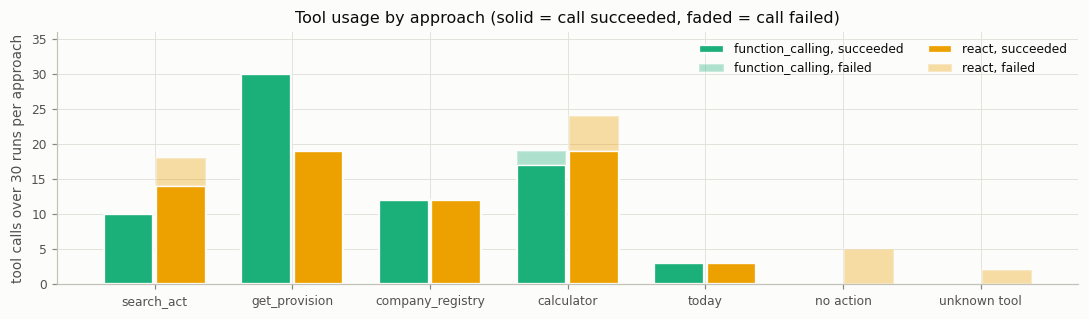

In [ ]:
TRACES = []
for task in TASKS:
    for approach, fn in (("function_calling", run_function_calling), ("react", run_react)):
        for seed in CFG["seeds"]:
            tr = fn(task, seed)
            tr["success"] = bool(tr["final"]) and bool(task["check"](tr["final"]))
            tr["chain_ok"] = chain_ok(tr, task)
            TRACES.append(tr)
            print(f"{task['id']} {approach:17s} seed {seed}: success={tr['success']!s:5s} chain_ok={tr['chain_ok']!s:5s} "
                  f"tools={tr['tool_calls']} calls={tr['llm_calls']} {tr['seconds']}s")
RESULTS["traces"] = TRACES
demo = next(t for t in TASKS if t["multi"])
for tr in TRACES:
    if tr["task"] == demo["id"] and tr["seed"] == CFG["seeds"][0]:
        print_trace(tr)
calls = pd.DataFrame([dict(approach=tr["approach"], tool=s["tool"] if s["tool"] in TOOLS else ("no action" if s["tool"] == "<no action>" else "unknown tool"), ok=s["ok"])
                      for tr in TRACES for s in tr["steps"]])
usage = calls.pivot_table(index="tool", columns="approach", values="ok", aggfunc=["size", "mean"]).fillna(0)
usage.columns = [f"{a} {'calls' if m == 'size' else 'ok share'}" for m, a in usage.columns]
display(usage.round(2))
fig, ax = plt.subplots(figsize=(10, 3))
tools_order = [t for t in list(TOOLS) + ["no action", "unknown tool"] if t in set(calls.tool)]
x = np.arange(len(tools_order))
for j, app in enumerate(("function_calling", "react")):
    sub = calls[calls.approach == app]
    ok_n = [int(((sub.tool == t) & sub.ok).sum()) for t in tools_order]
    bad_n = [int(((sub.tool == t) & ~sub.ok).sum()) for t in tools_order]
    ax.bar(x + (j - 0.5) * 0.38, ok_n, width=0.36, color=COLOR[app], label=f"{app}, succeeded", edgecolor=SURFACE, linewidth=1.5)
    ax.bar(x + (j - 0.5) * 0.38, bad_n, width=0.36, bottom=ok_n, color=COLOR[app], alpha=0.35, label=f"{app}, failed", edgecolor=SURFACE, linewidth=1.5)
ax.set_xticks(x, tools_order); ax.set_ylabel(f"tool calls over {len(TRACES) // 2} runs per approach"); ax.set_ylim(0, ax.get_ylim()[1] * 1.2); ax.legend(ncol=2)
ax.set_title("Tool usage by approach (solid = call succeeded, faded = call failed)")
finish(fig, "c_tool_usage")
RESULTS["part_c_tool_usage"] = usage.round(3).to_dict()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ב-⁠function&nbsp;calling 18 הצלחות מ-⁠30, וב-⁠ReAct 13. הראשון שולף בעיקר (30 שליפות מול 10 חיפושים), והשני מאוזן (19 שליפות ו-⁠18 חיפושים).</p>
<ul>
<li>ב-⁠function&nbsp;calling כל קריאות החוק והמרשם הצליחו; נכשלו 2 מתוך 19 חישובים, שניהם ב-⁠T05, עם משתנים בביטוי</li>
<li>ב-⁠ReAct נכשלו 4 חיפושים עם הסכמה במקום מחרוזת, 5 חישובי today ב-⁠T06, 5 צעדים בלי&nbsp;Action ו-⁠2 כלים מומצאים (ANSWER, None)</li>
</ul>
<p>בדוגמת T03, function&nbsp;calling פתר ב-⁠2 כלים ו-⁠5.5 שניות, ו-⁠ReAct ב-⁠5 קריאות לכלים, כולל ANSWER, ו-⁠42 שניות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>pass_hat_k: מחשבת pass^k מהרצאה 6 כ-⁠C(c,k)/C(n,k), ההסתברות שכל k ניסיונות מצליחים; כש-⁠k=n, חלק המשימות שהצליחו תמיד.</p>
</div>

In [ ]:
def pass_hat_k(n, c, k):
    if k > n or c < k:
        return 0.0
    return math.comb(c, k) / math.comb(n, k)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום לפי גישה: הצלחה עם רווח סמך, chain_ok, pass^3 ועלות; אחר כך גרף עלות, טבלה לכל משימה והצלחות בלי שרשור תקין.</p>
</div>

,n,successes,chain_ok,llm_calls,tool_calls,prompt_tokens,gen_tokens,seconds,exhausted,format_errors,success_rate_ci,multi_step_success,multi_step_chain_ok,pass_hat_k
approach,,,,,,,,,,,,,,
function_calling,30,18,0.83,3.03,2.47,4982.67,157.73,9.91,0.0,0.00,"(0.6, 0.423, 0.754)",0.571,0.762,0.4
react,30,13,0.70,3.67,2.77,4935.33,317.00,22.78,0.1,0.17,"(0.433, 0.274, 0.608)",0.333,0.619,0.2


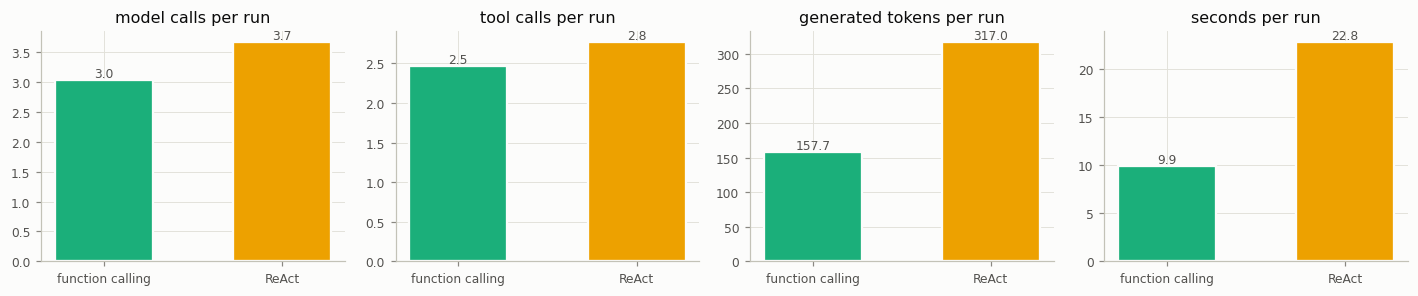

,FC s1,FC s2,FC s3,ReAct s1,ReAct s2,ReAct s3
task,,,,,,
T01,False,False,True,True,False,False
T02,True,True,True,True,False,True
T03,True,True,True,True,True,True
T04,True,False,False,False,True,False
T05,False,False,False,False,False,False
T06,True,True,False,True,False,False
T07,False,False,False,False,False,False
T08,True,True,True,True,True,False
T09,True,True,True,False,False,False


solved without the required tool chain (answered from memory or by mental arithmetic): ['T04/function_calling/s1', 'T09/function_calling/s1', 'T09/function_calling/s2']


In [ ]:
MULTI = {t["id"] for t in TASKS if t["multi"]}
tr_df = pd.DataFrame([dict(task=t["task"], approach=t["approach"], seed=t["seed"], success=t["success"], chain_ok=t["chain_ok"], multi=t["task"] in MULTI,
                           llm_calls=t["llm_calls"], tool_calls=t["tool_calls"], prompt_tokens=t["prompt_tokens"], gen_tokens=t["gen_tokens"],
                           seconds=t["seconds"], exhausted=t["exhausted"], format_errors=t["format_errors"]) for t in TRACES])
summ_c = tr_df.groupby("approach").agg(n=("success", "size"), successes=("success", "sum"), chain_ok=("chain_ok", "mean"), llm_calls=("llm_calls", "mean"),
                                       tool_calls=("tool_calls", "mean"), prompt_tokens=("prompt_tokens", "mean"), gen_tokens=("gen_tokens", "mean"),
                                       seconds=("seconds", "mean"), exhausted=("exhausted", "mean"), format_errors=("format_errors", "mean")).round(2)
summ_c["success_rate_ci"] = [wilson(int(r.successes), int(r.n)) for _, r in summ_c.iterrows()]
summ_c["multi_step_success"] = tr_df[tr_df.multi].groupby("approach").success.mean().round(3)
summ_c["multi_step_chain_ok"] = tr_df[tr_df.multi].groupby("approach").chain_ok.mean().round(3)
n_seeds = len(CFG["seeds"])
summ_c["pass_hat_k"] = [round(float(np.mean([pass_hat_k(n_seeds, int(g.success.sum()), n_seeds) for _, g in tr_df[tr_df.approach == a].groupby("task")])), 3) for a in summ_c.index]
display(summ_c)
fig, ax = plt.subplots(1, 4, figsize=(13, 2.8))
for a, (col, label) in zip(ax, (("llm_calls", "model calls per run"), ("tool_calls", "tool calls per run"), ("gen_tokens", "generated tokens per run"), ("seconds", "seconds per run"))):
    a.bar(range(len(summ_c)), summ_c[col], color=[COLOR[i] for i in summ_c.index], edgecolor=SURFACE, linewidth=1.5, width=0.55)
    a.set_xticks(range(len(summ_c)), ["function calling" if i == "function_calling" else "ReAct" for i in summ_c.index])
    for x_, v in enumerate(summ_c[col]):
        a.text(x_, v, f"{v:,.1f}", ha="center", va="bottom", fontsize=8, color=INK2)
    a.set_title(label)
finish(fig, "c_cost_by_approach")
pivot_c = tr_df.pivot_table(index="task", columns=["approach", "seed"], values="success", aggfunc="first")
display(pivot_c.set_axis([f"{'FC' if a == 'function_calling' else 'ReAct'} s{s}" for a, s in pivot_c.columns], axis=1))
from_memory = [f"{r.task}/{r.approach}/s{r.seed}" for _, r in tr_df.iterrows() if r.success and not r.chain_ok]
print("solved without the required tool chain (answered from memory or by mental arithmetic):", from_memory or "none")
RESULTS["part_c"] = dict(summary=summ_c.astype(str).to_dict("index"), per_run=tr_df.to_dict("records"), from_memory=from_memory)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ב-⁠function&nbsp;calling 18 מ-⁠30, 0.60 (0.42–0.75), וב-⁠ReAct 13, 0.43 (0.27–0.61); הרווחים חופפים, ו-⁠30 ריצות לגישה לא מכריעות.</p>
<ul>
<li>רב-שלביות — 12 מתוך 21 (0.57) מול 7 מתוך 21 (0.33)</li>
<li>ה-⁠pass^3 — 0.4 מול 0.2, עם T02, T03, T08 ו-⁠T09 ב-⁠function&nbsp;calling, ו-⁠T03 ו-⁠T10 ב-⁠ReAct</li>
<li>עלות — ReAct 22.8 שניות לריצה מול 9.9 (פי 2.3), ופי 2 טוקנים מיוצרים (317 מול 158), כנראה בגלל ה-⁠Thought; טוקני הפרומפט כמעט שווים</li>
<li>פורמט — ReAct מיצה את תקרת הצעדים ב-⁠3 ריצות ועשה 5 שגיאות פורמט; function&nbsp;calling אפס</li>
</ul>
<p>שלוש הצלחות של FC היו בלי שרשור תקין (T04&nbsp;s1, T09&nbsp;s1–2). ב-⁠T09 דילג על סעיף 101 וכתב&nbsp;min(200M,&nbsp;3%) במקום&nbsp;max(15M,&nbsp;3%). עם שרשור תקין בלבד: 15 מול&nbsp;13.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני גרפים: הצלחה עם רווחי Wilson לכל גישה, גם לרב-שלביות, ומפת הצלחה לכל ריצה; ואז טבלת הצלחה ושרשור תקין לכל משימה.</p>
</div>

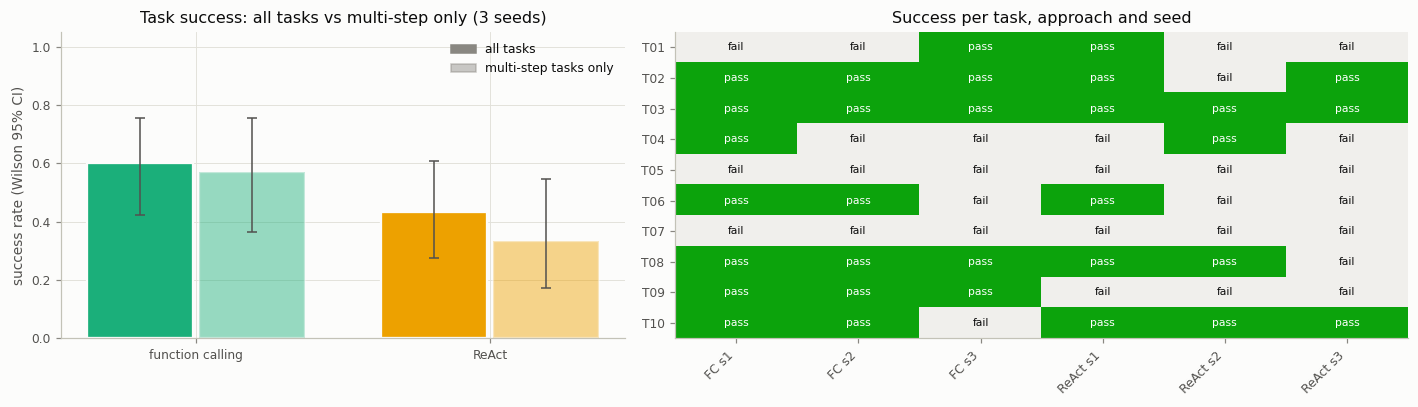

,function_calling success,react success,function_calling chain_ok,react chain_ok
task,,,,
T01,0.33,0.33,1.00,1.00
T02,1.00,0.67,1.00,0.67
T03,1.00,1.00,1.00,1.00
T04,0.33,0.33,0.67,1.00
T05,0.00,0.00,0.67,0.00
T06,0.67,0.33,0.67,0.67
T07,0.00,0.00,1.00,0.67
T08,1.00,0.67,1.00,1.00
T09,1.00,0.00,0.33,0.00


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw=dict(width_ratios=[1, 1.3]))
apps = list(summ_c.index)
for j, (label, sub) in enumerate((("all tasks", tr_df), ("multi-step tasks", tr_df[tr_df.multi]))):
    rates = [wilson(int(sub[sub.approach == a].success.sum()), int((sub.approach == a).sum())) for a in apps]
    bars_ci(ax[0], np.arange(len(apps)) + (j - 0.5) * 0.38, rates, [COLOR[a] for a in apps], alpha=1.0 if j == 0 else 0.45)
ax[0].legend([plt.Rectangle((0, 0), 1, 1, color=MUTED), plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.45)], ["all tasks", "multi-step tasks only"], loc="upper right")
ax[0].set_xticks(np.arange(len(apps)), ["function calling" if a == "function_calling" else "ReAct" for a in apps]); ax[0].set_ylim(0, 1.05)
ax[0].set_ylabel("success rate (Wilson 95% CI)"); ax[0].set_title(f"Task success: all tasks vs multi-step only ({n_seeds} seeds)")
draw_heat(ax[1], pivot_c.values.astype(float), list(pivot_c.index), [f"{'FC' if a == 'function_calling' else 'ReAct'} s{s}" for a, s in pivot_c.columns],
          cmap=PASS_CMAP, vmin=0, vmax=1, text=[["pass" if v else "fail" for v in row] for row in pivot_c.values], fontsize=7)
ax[1].set_title("Success per task, approach and seed")
finish(fig, "c_success")
per_task = tr_df.groupby(["task", "approach"])[["success", "chain_ok"]].mean().unstack("approach").round(2)
per_task.columns = [f"{a} {m}" for m, a in per_task.columns]
display(per_task)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הרב-שלביות נמוכות בשתי הגישות, בחדות ב-⁠ReAct. T05 ו-⁠T07 נכשלו 6/6, T03 הצליחה 6/6 לפי הבדיקה (ב-⁠FC seed 2 התשובה נטתה ל-⁠low-risk); ההבדל העיקרי ב-⁠T09, 3 מול 0, שתיים מהן בלי סעיף 101, וב-⁠T10&nbsp;ReAct&nbsp;עדיף.</p>
<p>לשאלת הניתוח, היכן הסוכן התבלבל בסדר:</p>
<ul>
<li>ב-⁠T05, כלל ה-⁠SME, אף ריצה לא חישבה 7% מ-⁠4 מיליון; function&nbsp;calling שלח את המחשבון באותו תור עם המרשם וסעיף 99 ובנה נוסחה משלו, ו-⁠ReAct דילג והמציא 2% או 10%</li>
<li>ב-⁠T09 אותו דפוס ב-⁠ReAct: מרשם ואז מחשבון עם 6%, 2% או 8%, בלי סעיף 101</li>
<li>ב-⁠T07 function&nbsp;calling חיפש Article&nbsp;51 עם k=1, קיבל נספח XIII וחילק בסף שגוי; ReAct חישב 4.0 פעמיים וכתב ב-⁠Thought שהמודל בסיכון מערכתי, אבל לא ב-⁠Final Answer, והבדיקה קוראת רק אותו</li>
<li>ב-⁠T06 function&nbsp;calling חישב בראש 371 ב-⁠seed&nbsp;3; ReAct כתב today כמשתנה, וב-⁠seed&nbsp;3 הגיע ל-⁠305 בצעד האחרון, בלי&nbsp;תשובה</li>
<li>ב-⁠T01, צעד אחד, 4/6 כשלים: פעמיים פתח בסעיף 5 ונדד לסעיפים לא רלוונטיים, ופעמיים הגיע ל-⁠99 וחישב קנס מומצא. האורך אינו ההסבר היחיד</li>
<li>קריאה לפני מידע: function&nbsp;calling שלח כמה כלים באותו תור ב-⁠10 מ-⁠30 ריצות; ב-⁠T05 בכל שלושת ה-⁠seeds המחשבון יצא לפני שתוצאות המרשם וסעיף 99 חזרו, וב-⁠T10 s3 לפני שסעיף 26&nbsp;חזר</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות, חלק ג׳:</p>
<ul>
<li>הצלחה — function&nbsp;calling מוביל, 18 מול 13, ברב-שלביות 12 מול 7 וב-⁠pass^3 0.4 מול 0.2; הכיוון עקבי, אבל הרווחים חופפים</li>
<li>עלות ויציבות — ההבדל ברור, ReAct איטי פי 2.3 ומייצר פי 2 טוקנים, 3 מיצויי תקרה ו-⁠5 שגיאות פורמט, מול אפס ב-⁠function&nbsp;calling</li>
<li>לשאלת הניתוח, ההצלחה יורדת עם אורך השרשרת, 12/18, 11/18 ו-⁠8/24, אבל האורך אינו ההסבר היחיד: T07, בשתי קבוצות כמו T03 ו-⁠T08, נכשלה 6/6. הכשל ביישום כלל מהחוק&nbsp;(SME, סף 51, קנס&nbsp;GPAI)</li>
<li>סוגי המשימות שדרשו שרשור של שלוש קבוצות כלים: קנס לפי נתון מהמרשם (T04, T05, T09) ותאריך (T06); בהן 8 הצלחות מ-⁠24, ורק 5 עם שרשור&nbsp;תקין</li>
<li>בלבול בסדר — ReAct דילג על הסעיף וחישב ישר מהמרשם (T05, T09), function&nbsp;calling שלח מחשבון עם כלי המידע (T05, T10) או חישב בראש&nbsp;(T06), וב-⁠T01 נדד בין סעיפים; ושלוש הצלחות בלי&nbsp;שרשור</li>
</ul>
<p>לכן function&nbsp;calling עדיף ביציבות ובעלות ונוטה לטובתו בהצלחה; החולשה המשותפת היא בחירת הסעיף הנכון ויישומו, לא&nbsp;הפורמט. ההשוואה היא בין שתי המערכות כפי שנבנו: רק הפרומפט של function&nbsp;calling אומר מתי לפנות&nbsp;לכלי.</p>
</div>

In [ ]:
checkpoint("Part C")

[checkpoint after Part C] /content/drive/MyDrive/FM/Final_Project/outputs/project_results.json (0.95 MB) | cache hits 0, misses 417


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ד׳ — כשלי סוכן לפי הטקסונומיה מהרצאה 8</p>
<ul>
<li>חיזוי כלי — no_tool, hallucinated_tool, wrong_tool ו-⁠wrong_argument</li>
<li>קריאה לכלי — wrong_response, כשהכלי מחזיר שגיאה, או תוצאה בלי המסמך הנכון לבקשה נכונה, ו-⁠no_response</li>
<li>יצירת תשובה — הכלים הצליחו והתשובה לא משקפת אותם, כולל מיצוי תקרה בלי תשובה; ביטוי שגוי שנשלח למחשבון הוא wrong_argument גם כשהתשובה מעתיקה את פלטו</li>
<li>תיוג אוטומטי מהעקבה לפי קריטריונים שנקבעו מראש, ואחריו תיוג ידני של כל ריצה כושלת, כנדרש בהנחיות</li>
<li>קטגוריה ראשית אחת לריצה: השלב המוקדם ביותר שגרם לכשל, ושגיאה שתוקנה אינה ראשית; שאר הקטגוריות נשמרות בנפרד. דילוג על סעיף נדרש נספר wrong_tool, ו-⁠no_tool שמור לריצה בלי שום כלי</li>
<li>השופט אינו משתתף, ולכן אין מעגליות בין חלק ד׳ לחלק ה׳</li>
<li>שאלת הניתוח — הכשל הנפוץ בכל גישה, והאם ReAct סבל יותר משגיאות חיזוי כלי בגלל חופש הפורמט</li>
</ul>
</div>


In [ ]:
CATEGORIES = ["tool_prediction/no_tool", "tool_prediction/hallucinated_tool", "tool_prediction/wrong_tool", "tool_prediction/wrong_argument",
              "tool_call/wrong_response", "tool_call/no_response", "response_generation/wrong_response"]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>search_missed_gold: מסמנת ריצה שבה היו קריאות מוצלחות לכלי החוק ואף אחת מהן לא החזירה מסמך זהב, כלומר תשובה שגויה של הכלי; בלי קריאה כזו מחזירה&nbsp;False.</p>
</div>

In [ ]:
def search_missed_gold(tr):
    gold = ITEM_GOLD.get(tr["task"]) or set()
    info = [s for s in tr["steps"] if s["tool"] in LAW and s["ok"]]
    if not gold or not info:
        return False
    got = set(re.findall(r"\[((?:art|anx)-[\w]+) \|", " ".join(s["result"] for s in info)))
    return not (gold & got)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>label_failure: מחזירה קטגוריה ראשית, את כל הקטגוריות ושלושה דגלים. הכלל wrong_tool חל כשקבוצה נדרשת לא נקראה בהצלחה, ויצירת תשובה כשהשרשור תקין, כשאין כשל אחר או כשהתשובה שונה מתוצאת המחשבון. הדגלים, מיצוי, פורמט והימנעות, אינם בטקסונומיה.</p>
</div>

In [ ]:
def label_failure(tr):
    task = TASK_BY_ID[tr["task"]]
    flags = dict(exhausted=tr["exhausted"], format_errors=tr["format_errors"], abstained=bool(ABSTAIN_RE.search(tr["final"] or "")))
    if tr["success"]:
        return "success", [], flags
    kinds = [s["error_kind"] for s in tr["steps"] if s["error_kind"]]
    real = [s for s in tr["steps"] if s["tool"] != "<no action>"]
    called_ok = {s["tool"] for s in real if s["ok"]}
    labels = []
    if not real:
        labels.append("tool_prediction/no_tool")
    if "hallucinated_tool" in kinds:
        labels.append("tool_prediction/hallucinated_tool")
    if real and any(not (group & called_ok) for group in task["chain"]):
        labels.append("tool_prediction/wrong_tool")
    if "wrong_argument" in kinds:
        labels.append("tool_prediction/wrong_argument")
    if "tool_error" in kinds or search_missed_gold(tr):
        labels.append("tool_call/wrong_response")
    if "no_response" in kinds:
        labels.append("tool_call/no_response")
    calc = [s["result"] for s in tr["steps"] if s["tool"] == "calculator" and s["ok"]]
    calc_ignored = bool(calc) and bool(tr["final"]) and not any(abs(x - float(calc[-1])) <= max(1.0, 1e-4 * abs(float(calc[-1]))) for x in nums_in(answer_line(tr["final"])))
    if not labels or tr["chain_ok"] or calc_ignored:
        labels.append("response_generation/wrong_response")
    primary = next(c for c in CATEGORIES if c in labels)
    return primary, labels, flags

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גיליון התיוג: סקירת הריצות הכושלות עם העקבה והתיוג האוטומטי, ומילון להדבקה. כל תיוג נבדק ידנית ב-⁠FAILURE_LABELS, גם כשזהה&nbsp;לאוטומטי.</p>
</div>

In [ ]:
AUTO = {}
for tr in TRACES:
    primary, labels, flags = label_failure(tr)
    AUTO[f"{tr['task']}/{tr['approach']}/s{tr['seed']}"] = dict(primary=primary, labels=labels, **flags)
failed = [tr for tr in TRACES if not tr["success"]]
print(f"failed runs: {len(failed)} of {len(TRACES)}")
display(pd.DataFrame([dict(key=f"{tr['task']}/{tr['approach']}/s{tr['seed']}", auto_label=AUTO[f"{tr['task']}/{tr['approach']}/s{tr['seed']}"]["primary"],
                           tools=" > ".join(s["tool"] for s in tr["steps"])[:80], exhausted=tr["exhausted"], format_errors=tr["format_errors"],
                           final=(answer_line(tr["final"]) or "(none)")[:40]) for tr in failed]).set_index("key"))
for tr in failed:
    key = f"{tr['task']}/{tr['approach']}/s{tr['seed']}"
    print("=" * 110)
    print(f"KEY: {key} | auto label: {AUTO[key]['primary']} | all: {AUTO[key]['labels']} | flags: exhausted={AUTO[key]['exhausted']} format_errors={AUTO[key]['format_errors']}")
    print("TASK:", TASK_BY_ID[tr["task"]]["q"][:160])
    print_trace(tr)
print("\nvalid categories:", CATEGORIES)
print("\nready-to-paste dict with the automatic labels; confirm or correct each one after reading its trace:")
print("FAILURE_LABELS = {")
for tr in failed:
    key = f"{tr['task']}/{tr['approach']}/s{tr['seed']}"
    print(f"    {key!r}: {AUTO[key]['primary']!r},")
print("}")

failed runs: 29 of 60


,auto_label,tools,exhausted,format_errors,final
key,,,,,
T01/function_calling/s1,tool_call/wrong_response,get_provision > get_provision > get_provision > get_provision > get_provision >,False,0,10000000
T01/function_calling/s2,response_generation/wrong_response,get_provision > get_provision > search_act > calculator,False,0,30000000
T01/react/s2,tool_prediction/wrong_argument,search_act > search_act > calculator,False,0,5000000
T01/react/s3,tool_call/wrong_response,get_provision > get_provision > get_provision > get_provision > get_provision >,True,0,(none)
T02/react/s2,tool_prediction/wrong_tool,search_act,False,0,3
T04/function_calling/s2,response_generation/wrong_response,company_registry > search_act > calculator,False,0,100000000.0
T04/function_calling/s3,response_generation/wrong_response,company_registry > get_provision > get_provision > calculator,False,0,20000000
T04/react/s1,response_generation/wrong_response,company_registry > search_act > calculator > <no action> > <no action> > <no act,True,3,(none)
T04/react/s3,response_generation/wrong_response,company_registry > search_act > get_provision > calculator,False,0,120000000.0


KEY: T01/function_calling/s1 | auto label: tool_call/wrong_response | all: ['tool_call/wrong_response', 'response_generation/wrong_response'] | flags: exhausted=False format_errors=0
TASK: What is the maximum administrative fine, in euros, for non-compliance with the prohibited AI practices of Article 5 of the EU AI Act? Put only the amount in eur
### T01 | function_calling | seed 1 | llm calls 6 | tool calls 6 | 19947+722 tokens | 44.57s | exhausted=False
   -> get_provision({"reference": "Article 5"}) ok=True  | '[art-5 | Article 5 — Prohibited AI practices] Article 5 — Prohibited AI practices\n\n1. The following AI practices shall be prohibit'
   -> get_provision({"reference": "Article 17(1)"}) ok=True  | '[art-17 | Art. 17(1) AI Act] Providers of high-risk AI systems shall put a quality management system in place that ensures complia'
   -> get_provision({"reference": "Article 18"}) ok=True  | '[art-18 | Article 18 — Documentation keeping] Article 18 — Documentation keeping\n\n1. T

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>29 מתוך 60 ריצות נכשלו, 12 ב-⁠function&nbsp;calling ו-⁠17 ב-⁠ReAct. שלוש משפחות בולטות: דילוג על כלי החוק ישר למחשבון (T05 ו-⁠T09 ב-⁠ReAct); מסמך לא נכון מהכלי (T07 ב-⁠function&nbsp;calling, נספח XIII במקום סעיף 51); ונוסחה שגויה במחשבון אחרי שליפה נכונה&nbsp;(T01, T05, T10). בתיוג האוטומטי, 9 מ-⁠17 הכשלים של ReAct הם wrong_tool, ו-⁠5 מ-⁠12 של function&nbsp;calling הם יצירת תשובה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>FAILURE_LABELS: קטגוריה ראשית לכל 29 הריצות הכושלות, אחרי קריאת העקבה, גם כשזהה לאוטומטית; שם קטגוריה שאינו בטקסונומיה עוצר את התא הבא.</p>
</div>

In [ ]:
FAILURE_LABELS = {
    'T01/function_calling/s1': 'tool_prediction/wrong_argument',
    'T01/function_calling/s2': 'tool_prediction/wrong_argument',
    'T01/react/s2': 'tool_prediction/wrong_argument',
    'T01/react/s3': 'tool_prediction/wrong_argument',
    'T02/react/s2': 'tool_prediction/wrong_argument',
    'T04/function_calling/s2': 'tool_prediction/wrong_tool',
    'T04/function_calling/s3': 'tool_prediction/wrong_argument',
    'T04/react/s1': 'tool_prediction/wrong_tool',
    'T04/react/s3': 'tool_prediction/wrong_tool',
    'T05/function_calling/s1': 'tool_prediction/wrong_argument',
    'T05/function_calling/s2': 'tool_prediction/wrong_argument',
    'T05/function_calling/s3': 'tool_prediction/wrong_argument',
    'T05/react/s1': 'tool_prediction/wrong_tool',
    'T05/react/s2': 'tool_prediction/wrong_tool',
    'T05/react/s3': 'tool_prediction/wrong_tool',
    'T06/function_calling/s3': 'tool_prediction/wrong_tool',
    'T06/react/s2': 'tool_prediction/wrong_tool',
    'T06/react/s3': 'tool_prediction/wrong_argument',
    'T07/function_calling/s1': 'tool_call/wrong_response',
    'T07/function_calling/s2': 'tool_call/wrong_response',
    'T07/function_calling/s3': 'tool_call/wrong_response',
    'T07/react/s1': 'response_generation/wrong_response',
    'T07/react/s2': 'tool_prediction/wrong_tool',
    'T07/react/s3': 'response_generation/wrong_response',
    'T08/react/s3': 'tool_prediction/wrong_argument',
    'T09/react/s1': 'tool_prediction/wrong_tool',
    'T09/react/s2': 'tool_prediction/wrong_tool',
    'T09/react/s3': 'tool_prediction/wrong_tool',
    'T10/function_calling/s3': 'tool_prediction/wrong_argument',
}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>איחוד התיוג: הידני גובר על האוטומטי, ועמודה changed מסמנת שינוי; אחריו טבלת האוטומטי מול הסופי, שמראה כמה תיוגים שונו ולאן.</p>
</div>

In [ ]:
for k, v in FAILURE_LABELS.items():
    assert v in CATEGORIES, f"{k}: '{v}' is not a taxonomy category"
lab_rows = []
for tr in TRACES:
    key = f"{tr['task']}/{tr['approach']}/s{tr['seed']}"
    auto = AUTO[key]
    final = FAILURE_LABELS.get(key, auto["primary"]) if not tr["success"] else "success"
    lab_rows.append(dict(key=key, task=tr["task"], approach=tr["approach"], seed=tr["seed"], auto=auto["primary"], final=final,
                         source=("manual" if key in FAILURE_LABELS else "auto"), changed=(key in FAILURE_LABELS and FAILURE_LABELS[key] != auto["primary"]),
                         exhausted=auto["exhausted"], format_errors=auto["format_errors"], abstained=auto["abstained"]))
lab_df = pd.DataFrame(lab_rows)
n_failed = int((lab_df.final != "success").sum())
n_manual = int(((lab_df.source == "manual") & (lab_df.final != "success")).sum())
print(f"failed runs {n_failed} | labelled manually {n_manual} | manual label differs from auto {int(lab_df.changed.sum())}")
if n_manual:
    fl = lab_df[lab_df.final != "success"]
    display(pd.crosstab(fl.auto.rename("automatic label"), fl.final.rename("final label (manual)")))

failed runs 29 | labelled manually 29 | manual label differs from auto 11


final label (manual),response_generation/wrong_response,tool_call/wrong_response,tool_prediction/wrong_argument,tool_prediction/wrong_tool
automatic label,,,,
response_generation/wrong_response,2,0,4,3
tool_call/wrong_response,0,3,2,0
tool_prediction/wrong_argument,0,0,4,0
tool_prediction/wrong_tool,0,0,2,9


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כל 29 הריצות הכושלות תויגו ידנית: 18 אישורים ו-⁠11 תיקונים, 9 לשלב מוקדם יותר ו-⁠2 באותו&nbsp;שלב:</p>
<ul>
<li>ב-⁠T04, מיצירת תשובה לחיזוי כלי — שלוש ריצות דילגו על סעיף 99 והמציאו 5% או 6% (wrong_tool), ואחת שלפה 99(1) במקום&nbsp;99(3)</li>
<li>ב-⁠T01 FC&nbsp;s1 וב-⁠ReAct&nbsp;s3, מ-⁠tool_call/wrong_response ל-⁠wrong_argument — הכלי החזיר בדיוק את הסעיפים שהתבקשו (17, 18 ו-⁠83; 8, 16, 17, 18 ו-⁠20); הטעות&nbsp;בבחירתם</li>
<li>ב-⁠T02 ReAct&nbsp;s2 וב-⁠T05 FC&nbsp;s1, מ-⁠wrong_tool ל-⁠wrong_argument — קודם לכן ארגומנט שבור: סכמה במקום מחרוזת, ומשתנים&nbsp;בביטוי</li>
<li>ב-⁠T01 FC&nbsp;s2, T05 FC&nbsp;s2 ו-⁠T10 FC&nbsp;s3, מיצירת תשובה ל-⁠wrong_argument — המחשבון קיבל ביטוי שגוי (3% ממחזור מומצא; min על מחזור מומצא של 2 מיליארד ו-⁠2.5% במקום 7% מ-⁠4 מיליון; 10×12) והתשובה מעתיקה את פלטו נאמנה. לפי ההגדרה בהנחיות, יצירת תשובה היא רק כשהתשובה אינה משקפת את פלט הכלי; מאותה סיבה T01 ReAct&nbsp;s2 ו-⁠T08 ReAct&nbsp;s3 נשארים wrong_argument, כמו&nbsp;באוטומטי</li>
</ul>
<p>הכלל: הקטגוריה הראשית היא השלב המוקדם ביותר שגרם לכשל; ביטוי שגוי למחשבון הוא ארגומנט שגוי; שגיאה שתוקנה ולא השפיעה נשארת רק ברשימת הקטגוריות שנצפו. יצירת תשובה נותרה רק ב-⁠T07 ReAct s1 ו-⁠s3: החישוב נכון, והתשובה הסופית לא ציינה שהמודל&nbsp;בסיכון&nbsp;מערכתי.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תדירויות: קטגוריה ראשית מול גישה ולפי שלוש רמות, בטבלה ובגרף; הדגלים בנפרד, כתסמינים; ולפי משימה, עם TP, TC ו-⁠RG לרמות.</p>
</div>

approach,function_calling,react
final,,
success,18,13
tool_prediction/no_tool,0,0
tool_prediction/hallucinated_tool,0,0
tool_prediction/wrong_tool,2,10
tool_prediction/wrong_argument,7,5
tool_call/wrong_response,3,0
tool_call/no_response,0,0
response_generation/wrong_response,0,2


approach,function_calling,react
level,,
success,18,13
tool_prediction,9,15
tool_call,3,0
response_generation,0,2


,exhausted,abstained,format_errors
approach,,,
function_calling,0,2,0
react,3,0,5


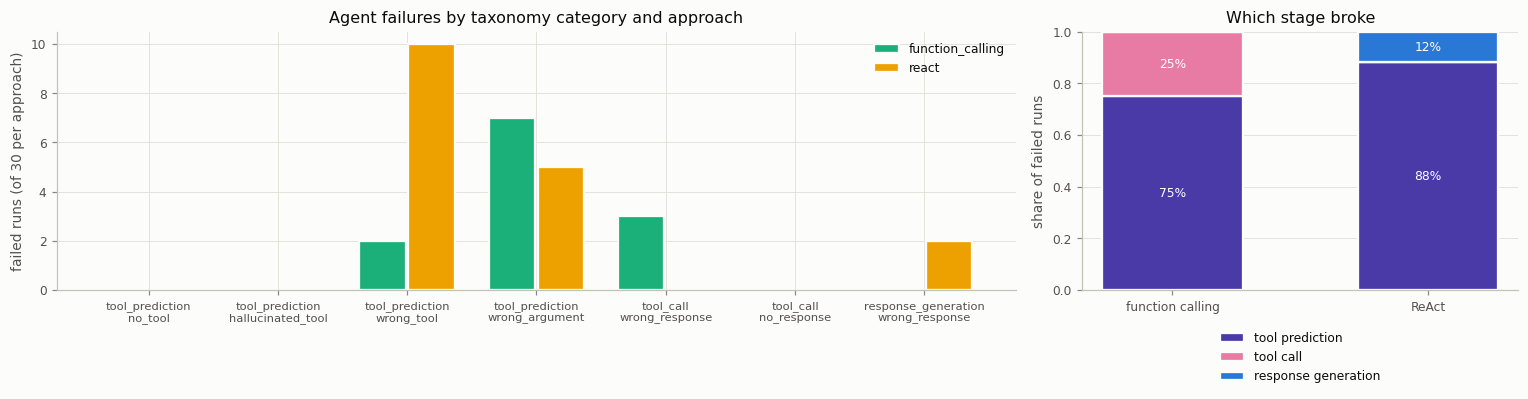

,RG/wrong_response,TC/wrong_response,TP/wrong_argument,TP/wrong_tool
task,,,,
T01,0,0,4,0
T02,0,0,1,0
T04,0,0,1,3
T05,0,0,3,3
T06,0,0,1,2
T07,2,3,0,1
T08,0,0,1,0
T09,0,0,0,3
T10,0,0,1,0


In [ ]:
freq = lab_df.pivot_table(index="final", columns="approach", values="key", aggfunc="count").reindex(["success"] + CATEGORIES).fillna(0).astype(int)
display(freq)
lab_df["level"] = lab_df.final.str.split("/").str[0]
lvl = lab_df.pivot_table(index="level", columns="approach", values="key", aggfunc="count").reindex(["success", "tool_prediction", "tool_call", "response_generation"]).fillna(0).astype(int)
display(lvl)
flags_tab = lab_df.groupby("approach")[["exhausted", "abstained"]].sum().assign(format_errors=lab_df.groupby("approach").format_errors.sum())
display(flags_tab)
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw=dict(width_ratios=[2.2, 1]))
sub = freq.drop(index="success")
x = np.arange(len(sub))
for j, a in enumerate(sub.columns):
    ax[0].bar(x + (j - 0.5) * 0.38, sub[a].values, width=0.36, color=COLOR[a], label=a, edgecolor=SURFACE, linewidth=1.5)
ax[0].set_xticks(x, [c.replace("/", chr(10)) for c in sub.index], fontsize=7.5)
ax[0].set_ylabel(f"failed runs (of {len(lab_df) // 2} per approach)"); ax[0].set_title("Agent failures by taxonomy category and approach"); ax[0].legend()
levels = ["tool_prediction", "tool_call", "response_generation"]
share = lvl.reindex(levels).div(lvl.reindex(levels).sum(), axis=1).fillna(0)
bottom = np.zeros(share.shape[1])
for lev, col in zip(levels, (PAL[6], PAL[4], PAL[0])):
    ax[1].bar(range(share.shape[1]), share.loc[lev].values, bottom=bottom, color=col, label=lev.replace("_", " "), edgecolor=SURFACE, linewidth=1.5, width=0.55)
    for x_, (b, v) in enumerate(zip(bottom, share.loc[lev].values)):
        if v >= 0.08:
            ax[1].text(x_, b + v / 2, f"{v:.0%}", ha="center", va="center", fontsize=8, color="white")
    bottom += share.loc[lev].values
ax[1].set_xticks(range(share.shape[1]), ["function calling" if a == "function_calling" else "ReAct" for a in share.columns])
ax[1].set_ylim(0, 1); ax[1].set_ylabel("share of failed runs"); ax[1].set_title("Which stage broke"); ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)
finish(fig, "d_failures")
by_task = lab_df[lab_df.final != "success"].pivot_table(index="task", columns="final", values="key", aggfunc="count").fillna(0).astype(int)
by_task.columns = [{"tool_prediction": "TP", "tool_call": "TC", "response_generation": "RG"}[c.split("/")[0]] + "/" + c.split("/")[1] for c in by_task.columns]
display(by_task)
RESULTS["part_d"] = dict(frequencies=freq.to_dict(), levels=lvl.to_dict(), flags=flags_tab.to_dict(), n_failed=n_failed, n_manual=n_manual,
                         labels=lab_df.to_dict("records"))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>לפי התיוג הידני:</p>
<ul>
<li>ב-⁠function&nbsp;calling 12 כשלים — 9 בחיזוי כלי (2 wrong_tool, 7 wrong_argument), 3 בקריאה לכלי (כולם T07) ואפס ביצירת&nbsp;תשובה</li>
<li>ב-⁠ReAct 17 כשלים — 15 בחיזוי כלי (10 wrong_tool, 5 wrong_argument), אפס בקריאה לכלי ו-⁠2 ביצירת תשובה, שתיהן&nbsp;T07</li>
<li>הקטגוריות no_tool, hallucinated_tool ו-⁠no_response לא נבחרו כראשיות; שתי הקריאות לכלים לא קיימים ב-⁠ReAct היו בריצות&nbsp;שהצליחו</li>
<li>דגלים — ב-⁠ReAct 3 מיצויי תקרה ו-⁠5 שגיאות פורמט; ב-⁠function&nbsp;calling ניסוח הימנעות ב-⁠2 ריצות, בלי ויתור בפועל: ב-⁠T01&nbsp;s1 המודל כתב שהסעיף לא נמצא, הניח, וענה 10&nbsp;מיליון</li>
</ul>
<p>לפי משימה, כשלי&nbsp;wrong_tool מרוכזים ב-⁠T04,&nbsp;T05,&nbsp;T06&nbsp;ו-⁠T09, ארבע המשימות עם שלוש קבוצות כלים; כשלי הקריאה לכלי רק ב-⁠T07; wrong_argument מפוזר על שבע&nbsp;משימות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות, חלק ד׳:</p>
<ul>
<li>הכשל הנפוץ — ב-⁠function&nbsp;calling&nbsp;wrong_argument&nbsp;(7/12): סעיף שגוי, משתנים או נוסחה שגויה במחשבון; ב-⁠ReAct&nbsp;wrong_tool&nbsp;(10/17), ב-⁠8 מהם דילוג על סעיף הקנס ואחוז&nbsp;מומצא</li>
<li>ב-⁠ReAct יותר שגיאות חיזוי כלי, 15 מול 9 מתוך 30 ריצות לגישה, מדגם קטן. חופש הפורמט מסביר מעט: 4 סכמות שגויות, ורק ב-⁠T02&nbsp;s2 זו הסיבה הראשית. הפער כולו ב-⁠wrong_tool, 10 מול 2: דילוג על שלב, לא שגיאת&nbsp;כתיבה</li>
<li>גורם מבלבל — רק הפרומפט של function&nbsp;calling אומר מתי לפנות לכלי; חלק מהדילוגים ב-⁠ReAct עשוי לנבוע מההנחיה החסרה ולא מהפורמט. ההשוואה היא בין שתי המערכות כפי&nbsp;שנבנו</li>
<li>בתיוג הידני, חיזוי כלי ב-⁠function&nbsp;calling עלה מ-⁠3 ל-⁠9: סעיף לא נכון, דילוג על סעיף 99 או ביטוי שגוי במחשבון; ב-⁠ReAct מ-⁠12 ל-⁠15, כש-⁠4 מ-⁠17 התוויות&nbsp;שונו</li>
<li>הכשל היחיד בקריאה לכלי הוא T07 ב-⁠function&nbsp;calling, שבו החיפוש "Article&nbsp;51" עם k=1 החזיר את נספח XIII בשלושת ה-⁠seeds; אפשר לטעון שזו שגיאת ארגומנט (k=1 במקום get_provision), ונשמר ככשל הכלי כי חיפוש שנשאל על סעיף מצוין במפורש לא&nbsp;מצא&nbsp;אותו</li>
<li>הקטגוריות no_tool, hallucinated_tool ו-⁠no_response לא ראשיות באף ריצה; מיצוי תקרה ושגיאות פורמט רק&nbsp;ב-⁠ReAct</li>
</ul>
<p>ב-⁠function&nbsp;calling אין סכמות שבורות ושגיאות פורמט, ופחות דילוג על שלב, 2 מול 10, אף שגם הוא דילג בשלוש ריצות שהצליחו (T04&nbsp;s1, T09&nbsp;s1–2). ביטוי שגוי במחשבון ובקשה לסעיף שגוי הופיעו בשתי הגישות; בשתיהן השורש: בחירת הסעיף הנכון&nbsp;ויישומו.</p>
</div>

In [ ]:
checkpoint("Part D")

[checkpoint after Part D] /content/drive/MyDrive/FM/Final_Project/outputs/project_results.json (0.97 MB) | cache hits 0, misses 417


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ה׳ — LLM-as-a-Judge ל-⁠groundedness</p>
<ul>
<li>השופט — Phi-4, ממשפחה שונה מהסוכן; רשימת טענות עם ראיה לכל אחת, נימוק, ואז פסק, בסכמת JSON</li>
<li>עקביות: כל פריט נשפט פעמיים, בסדר ראיות רגיל והפוך. מדווחים הסכמה, קאפא, וההיפוכים עם כיוונם</li>
<li>הסכמה עם תיוג ידני על 24 פריטים מוגרלים משלושת התנאים (closed-book, שבטבלאות llm_only ובחלק ו׳ "LLM בלבד"): קאפא ב-⁠3 וב-⁠2 רמות, עם גודל מדגם וספירת תוויות</li>
<li>הטיית אריכות: אורך לפי פסק, ובדיקה יזומה שבה תשובות מבוססות מקבלות שתי טענות לא נתמכות ונשפטות שוב</li>
<li>שאלת הניתוח: היכן השופט טעה ביחס לתיוג הידני, והאם יש הטיית אריכות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>split_provision: מפצלת סעיף ארוך לקטעים של עד evidence_chars תווים לפי פסקאות, עם התווית בכל קטע; פלט קצר חוזר כמו שהוא.</p>
</div>

In [ ]:
def split_provision(text):
    head = re.match(r"\[[^\]]*\]", text)
    if head is None or len(text) <= CFG["evidence_chars"]:
        return [text]
    tag = head.group(0)
    limit = CFG["evidence_chars"] - len(tag) - 1
    pieces, cur = [], ""
    for para in [x.strip() for x in text[len(tag):].split("\n\n") if x.strip()]:
        while len(para) > limit:
            cut = para.rfind(" ", 0, limit)
            cut = cut if cut > 0 else limit
            if cur:
                pieces.append(cur)
                cur = ""
            pieces.append(para[:cut])
            para = para[cut:].strip()
        if not para:
            continue
        if cur and len(cur) + 2 + len(para) > limit:
            pieces.append(cur)
            cur = ""
        cur = f"{cur}\n\n{para}" if cur else para
    if cur:
        pieces.append(cur)
    return [f"{tag} {x}" for x in pieces]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>select_evidence: מעל max_evidence, שומרת מחשבון, מרשם ותאריך, ומהחוק המובילים ב-⁠reranker, כדי שהשופט יראה את הפסקה&nbsp;הנכונה.</p>
</div>

In [ ]:
def select_evidence(question, answer, pieces):
    if len(pieces) <= CFG["max_evidence"]:
        return pieces
    uniq = list(dict.fromkeys(pieces))
    law = [i for i, e in enumerate(uniq) if re.match(r"\[(?:art|anx)-", e)]
    keep = [i for i in range(len(uniq)) if i not in law]
    room = max(0, CFG["max_evidence"] - len(keep))
    if law and room:
        scores = RERANKER.predict([(f"{question} {answer_line(answer)}", uniq[i][:CFG["evidence_chars"]]) for i in law], show_progress_bar=False)
        order = sorted(range(len(law)), key=lambda j: (-round(float(scores[j]), 4), j))
        keep += [law[j] for j in order[:room]]
    return [uniq[i] for i in sorted(keep)]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>agent_record: בונה רשומה מפלטים מוצלחים, בפסקאות. בהרצה מוקדמת חיתוך ב-⁠1,500 תווים הסתיר מהשופט את 26(6); הפיצול שינה את הראיות של 25&nbsp;מ-⁠114 רשומות, והן נשפטו&nbsp;מחדש.</p>
</div>

In [ ]:
def agent_record(tr):
    ev, raw = [], []
    for s in tr["steps"]:
        if s["ok"]:
            parts = [x for x in re.split(r"\n\n(?=\[(?:art|anx)-)", s["result"]) if x.strip()]
            raw += parts
            ev += [y for x in parts for y in (split_provision(x) if s["tool"] == "get_provision" else [x])]
    docs = re.findall(r"\[((?:art|anx)-[\w]+) \|", " ".join(raw))
    return dict(answer=tr["final"], evidence=select_evidence(ITEM_TEXT[tr["task"]], tr["final"], ev), retrieved=list(dict.fromkeys(docs)),
                cited=sorted(set(re.findall(r"\b((?:art|anx)-\w+)", tr["final"] or ""))),
                llm_calls=tr["llm_calls"], tool_calls=tr["tool_calls"], prompt_tokens=tr["prompt_tokens"], gen_tokens=tr["gen_tokens"],
                seconds=tr["seconds"], success=tr["success"], chain_ok=tr["chain_ok"])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>60 ריצות הסוכן נשפטות ל-⁠groundedness בסדר הרגיל, ופסקיהן מוצלבים בטבלה ובגרף עם ההצלחה של חלק ג׳, שנבדקה בלי שופט.</p>
</div>

Loading weights:   0%|          | 0/243 [00:00<?, ?it/s]

judged agent answers: 30 per approach


,agent_fc,agent_react
GROUNDED,14,11
PARTIALLY_GROUNDED,11,15
NOT_GROUNDED,5,4
INVALID,0,0


verdict against rule-checked success:


,agent_fc solved,agent_fc failed,agent_react solved,agent_react failed
GROUNDED,9,5,9,2
PARTIALLY_GROUNDED,9,2,4,11
NOT_GROUNDED,0,5,0,4
INVALID,0,0,0,0


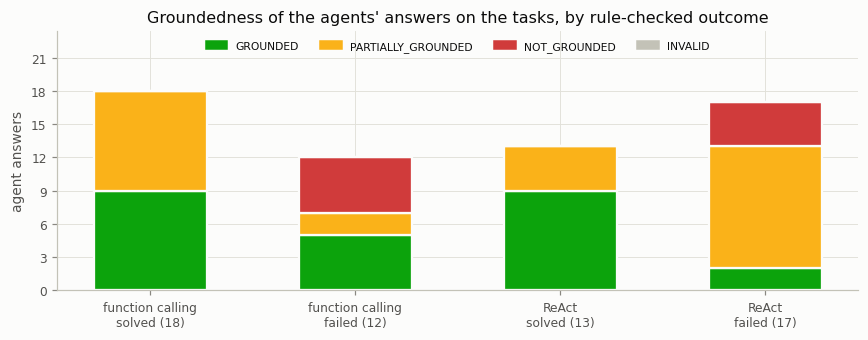

In [ ]:
for tr in TRACES:
    RUNS["agent_fc" if tr["approach"] == "function_calling" else "agent_react"][rkey(tr["task"], tr["seed"])] = agent_record(tr)
C_KEYS = [rkey(t["id"], s) for t in TASKS for s in CFG["seeds"]]
judge_runs("agent_fc", C_KEYS, "C")
judge_runs("agent_react", C_KEYS, "C")
print("judged agent answers:", len(C_KEYS), "per approach")
agent_dist = pd.DataFrame({c: Counter(RUNS[c][k]["judge"]["verdict"] for k in C_KEYS) for c in ("agent_fc", "agent_react")}).reindex(VERDICTS + ["INVALID"]).fillna(0).astype(int)
display(agent_dist)
split = pd.DataFrame({f"{c} {'solved' if s else 'failed'}": Counter(RUNS[c][k]["judge"]["verdict"] for k in C_KEYS if bool(RUNS[c][k]["success"]) == s)
                      for c in ("agent_fc", "agent_react") for s in (True, False)}).reindex(VERDICTS + ["INVALID"]).fillna(0).astype(int)
print("verdict against rule-checked success:")
display(split)
fig, ax = plt.subplots(figsize=(8, 3.2))
bottom = np.zeros(len(split.columns))
for v in VERDICTS + ["INVALID"]:
    ax.bar(range(len(split.columns)), split.loc[v].values, bottom=bottom, color=VERDICT_COLOR[v], edgecolor=SURFACE, linewidth=1.5, width=0.55)
    bottom += split.loc[v].values
ax.set_xticks(range(len(split.columns)), [f"{'function calling' if c.startswith('agent_fc') else 'ReAct'}{chr(10)}{c.split()[-1]} ({int(split[c].sum())})" for c in split.columns])
ax.set_ylabel("agent answers"); ax.set_title("Groundedness of the agents' answers on the tasks, by rule-checked outcome")
ax.set_ylim(0, bottom.max() * 1.3); ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend([plt.Rectangle((0, 0), 1, 1, color=VERDICT_COLOR[v]) for v in VERDICT_COLOR], list(VERDICT_COLOR), loc="upper center", ncol=4, fontsize=7)
finish(fig, "e_agent_verdicts")
RESULTS["part_e"] = dict(agent_verdicts=agent_dist.to_dict(), verdict_by_outcome=split.to_dict())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ב-⁠function&nbsp;calling 14 GROUNDED, 11 PARTIALLY_GROUNDED ו-⁠5 NOT_GROUNDED, וב-⁠ReAct 11, 15 ו-⁠4. מול ההצלחה של חלק&nbsp;ג׳:</p>
<ul>
<li>אף ריצה מוצלחת לא קיבלה NOT_GROUNDED; כל ה-⁠9 ניתנו לריצות שנכשלו, כמו T07 ב-⁠function&nbsp;calling</li>
<li>7 כשלים קיבלו GROUNDED, כמו T05&nbsp;s2 ב-⁠function&nbsp;calling: המספר, 50 מיליון, נתמך בפלט המחשבון, אבל הנוסחה&nbsp;שגויה</li>
<li>13 מ-⁠31 ההצלחות קיבלו רק PARTIALLY_GROUNDED, כמו T08 ב-⁠function&nbsp;calling, שמקבל&nbsp;GROUNDED בסדר&nbsp;ההפוך</li>
</ul>
<p>לכן GROUNDED לא מסמן הצלחה; הפיצול לבדו הוריד את שיעור הלא-מבוססות במלואן ב-⁠function&nbsp;calling מ-⁠0.70 בהרצה מוקדמת ל-⁠0.53, יותר מפער&nbsp;הגישות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ריצה שנייה של השופט, בסדר ראיות הפוך, על כל ארבעת התנאים; שופט שאינו מושפע מהסדר נותן בטבלה ובגרף שיעורי GROUNDED שווים.</p>
</div>

judged twice: 168 items | judge retries asked 0 recovered 0


,n,grounded_normal,grounded_reversed
condition,,,
llm_only,54,0.39 [0.27-0.52],0.39 [0.27-0.52]
rag,54,0.96 [0.88-0.99],0.96 [0.88-0.99]
agent_fc,30,0.47 [0.30-0.64],0.57 [0.39-0.73]
agent_react,30,0.37 [0.22-0.55],0.40 [0.25-0.58]


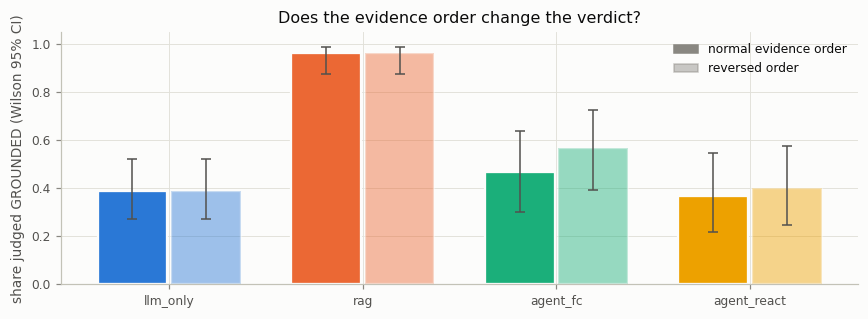

In [ ]:
CONSIST = [("llm_only", B_KEYS), ("rag", B_KEYS), ("agent_fc", C_KEYS), ("agent_react", C_KEYS)]
for cond, keys in CONSIST:
    judge_runs(cond, keys, "E-reverse", reverse=True)
free_judge()
pairs = [(cond, k, RUNS[cond][k]["judge"]["verdict"], RUNS[cond][k]["judge2"]["verdict"]) for cond, keys in CONSIST for k in keys]
print("judged twice:", len(pairs), "items | judge retries asked", JUDGE_STATE["asked"], "recovered", JUDGE_STATE["recovered"])
order_tab = pd.DataFrame([dict(condition=c, n=len(keys),
                               grounded_normal=wilson(sum(RUNS[c][k]["judge"]["verdict"] == "GROUNDED" for k in keys), len(keys)),
                               grounded_reversed=wilson(sum(RUNS[c][k]["judge2"]["verdict"] == "GROUNDED" for k in keys), len(keys))) for c, keys in CONSIST]).set_index("condition")
display(order_tab.assign(grounded_normal=order_tab.grounded_normal.map(ci_text), grounded_reversed=order_tab.grounded_reversed.map(ci_text)))
fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(len(order_tab))
bars_ci(ax, x - 0.19, list(order_tab.grounded_normal), [COLOR[c] for c in order_tab.index])
bars_ci(ax, x + 0.19, list(order_tab.grounded_reversed), [COLOR[c] for c in order_tab.index], alpha=0.45)
ax.set_xticks(x, order_tab.index); ax.set_ylim(0, 1.05); ax.set_ylabel("share judged GROUNDED (Wilson 95% CI)")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=MUTED), plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.45)], ["normal evidence order", "reversed order"], loc="upper right")
ax.set_title("Does the evidence order change the verdict?")
finish(fig, "e_order_effect")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>168 פריטים נשפטו פעמיים, בלי ניסיון חוזר. ב-⁠closed-book וב-⁠RAG שיעור ה-⁠GROUNDED זהה בשני הסדרים, 0.39 ו-⁠0.96; בסוכן ההפוך מעלה מעט, ב-⁠function&nbsp;calling מ-⁠0.47 ל-⁠0.57 (3 פריטים נטו) וב-⁠ReAct מ-⁠0.37 ל-⁠0.40 (אחד). שיעור זהה אינו פסקים זהים, והתא הבא סופר&nbsp;היפוכים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>עקביות השופט בין הסדרים: הסכמה וקאפא ב-⁠3 וב-⁠2 רמות, מעברים ופילוח לפי תנאי; קאפא נמוך כשכמעט הכול GROUNDED נובע מחוסר&nbsp;איזון.</p>
</div>

3-level: agreement 0.815 kappa 0.659 n 168 | binary: agreement 0.857 kappa 0.704
flipped verdicts: 31 | reversed order moved 14 items to GROUNDED and 10 away from GROUNDED


reversed order,GROUNDED,PARTIALLY_GROUNDED,NOT_GROUNDED,INVALID
normal order,,,,
GROUNDED,88,9,1,0
PARTIALLY_GROUNDED,14,37,0,0
NOT_GROUNDED,0,7,12,0
INVALID,0,0,0,0


,n,agreement,kappa
condition,,,
llm_only,54,0.722,0.552
rag,54,0.926,-0.038
agent_fc,30,0.733,0.553
agent_react,30,0.867,0.774


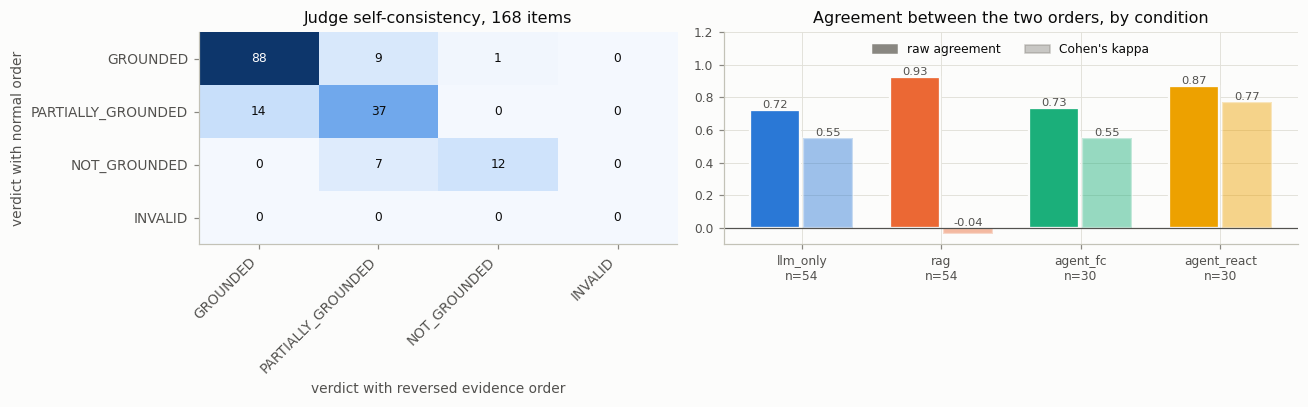

In [ ]:
v1 = [x[2] for x in pairs]
v2 = [x[3] for x in pairs]
binary = lambda v: "GROUNDED" if v == "GROUNDED" else "NOT"
k3, k2 = kappa(v1, v2), kappa([binary(v) for v in v1], [binary(v) for v in v2])
flips = [x for x in pairs if x[2] != x[3]]
to_grounded = sum(1 for x in flips if x[3] == "GROUNDED")
from_grounded = sum(1 for x in flips if x[2] == "GROUNDED")
print(f"3-level: agreement {k3['agreement']} kappa {k3['kappa']} n {k3['n']} | binary: agreement {k2['agreement']} kappa {k2['kappa']}")
print(f"flipped verdicts: {len(flips)} | reversed order moved {to_grounded} items to GROUNDED and {from_grounded} away from GROUNDED")
trans = pd.crosstab(pd.Series(v1, name="normal order"), pd.Series(v2, name="reversed order")).reindex(index=VERDICTS + ["INVALID"], columns=VERDICTS + ["INVALID"]).fillna(0).astype(int)
display(trans)
by_cond = pd.DataFrame([dict(condition=cond, n=len(keys), agreement=kappa([RUNS[cond][k]["judge"]["verdict"] for k in keys], [RUNS[cond][k]["judge2"]["verdict"] for k in keys])["agreement"],
                             kappa=kappa([RUNS[cond][k]["judge"]["verdict"] for k in keys], [RUNS[cond][k]["judge2"]["verdict"] for k in keys])["kappa"]) for cond, keys in CONSIST]).set_index("condition")
display(by_cond)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw=dict(width_ratios=[1, 1.2]))
draw_heat(ax[0], trans.values, list(trans.index), list(trans.columns), vmin=0, vmax=max(1, trans.values.max()), fmt="{:.0f}", fontsize=8)
ax[0].set_xlabel("verdict with reversed evidence order"); ax[0].set_ylabel("verdict with normal order")
ax[0].set_title(f"Judge self-consistency, {len(pairs)} items")
x = np.arange(len(by_cond))
kap = by_cond.kappa.fillna(0).astype(float)
ax[1].bar(x - 0.19, by_cond.agreement, width=0.36, color=[COLOR[c] for c in by_cond.index], edgecolor=SURFACE, linewidth=1.5)
ax[1].bar(x + 0.19, kap, width=0.36, color=[COLOR[c] for c in by_cond.index], alpha=0.45, edgecolor=SURFACE, linewidth=1.5)
for x_, a_, k_ in zip(x, by_cond.agreement, kap):
    ax[1].text(x_ - 0.19, a_, f"{a_:.2f}", ha="center", va="bottom", fontsize=7.5, color=INK2)
    ax[1].text(x_ + 0.19, max(k_, 0), f"{k_:.2f}", ha="center", va="bottom", fontsize=7.5, color=INK2)
ax[1].axhline(0, color=INK2, linewidth=0.8)
ax[1].set_xticks(x, [f"{c}{chr(10)}n={int(n)}" for c, n in zip(by_cond.index, by_cond.n)]); ax[1].set_ylim(min(-0.1, kap.min() - 0.05), 1.2)
ax[1].legend([plt.Rectangle((0, 0), 1, 1, color=MUTED), plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.45)], ["raw agreement", "Cohen's kappa"], loc="upper center", ncol=2)
ax[1].set_title("Agreement between the two orders, by condition")
finish(fig, "e_consistency")
RESULTS["part_e"]["consistency"] = dict(n=len(pairs), three_level=k3, binary=k2, flips=len(flips), to_grounded=to_grounded, from_grounded=from_grounded,
                                        transitions=trans.to_dict(), by_condition=by_cond.to_dict("index"),
                                        flipped_keys=[f"{c}|{k}: {a} -> {b}" for c, k, a, b in flips])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ב-⁠3 רמות הסכמה 0.815 וקאפא 0.659, וב-⁠2 רמות 0.857 ו-⁠0.704; בסדר ההפוך 21 פסקים עלו (14 אל GROUNDED, 7 מ-⁠NOT ל-⁠PARTIALLY) ו-⁠10 ירדו: נטייה להקלה, קטנה מכדי להכריע ב-⁠168 פריטים. הרשימה: flipped_keys&nbsp;ב-⁠project_results.json.</p>
<ul>
<li>ב-⁠closed-book הסכמה 0.722 וקאפא 0.552, 15 היפוכים מ-⁠54, בהם Q06 (30 מיליון), GROUNDED בסדר אחד ו-⁠PARTIALLY&nbsp;בשני</li>
<li>ב-⁠RAG הסכמה 0.926 וקאפא 0.038-, פרדוקס הקאפא (52/54 GROUNDED); Q18 seed&nbsp;2, שגיאת הסינתזה מחלק ב׳, נתפסה רק בסדר&nbsp;ההפוך</li>
<li>ב-⁠function&nbsp;calling הסכמה 0.733 וקאפא 0.553, 8 היפוכים מ-⁠30: בכל ה-⁠seeds, T08 (נכון) עלה ל-⁠GROUNDED ו-⁠T07&nbsp;(שגוי)&nbsp;ל-⁠PARTIALLY</li>
<li>ב-⁠ReAct הסכמה 0.867 וקאפא 0.774, 4 היפוכים מ-⁠30</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גיליון התיוג הידני: 24 פריטים מוגרלים, 8 מכל תנאי, עם הראיות שהשופט ראה בלי הפסק שלו; מתייגים לפי איתור כל טענה בראיות.</p>
</div>

In [ ]:
rng = random.Random(GLOBAL_SEED)
pools = {"llm_only": [f"llm_only|{k}" for k in B_KEYS], "rag": [f"rag|{k}" for k in B_KEYS], "agent": [f"agent_fc|{k}" for k in C_KEYS] + [f"agent_react|{k}" for k in C_KEYS]}
per = max(1, CFG["n_manual"] // 3)
manual_keys = []
for name, pool in pools.items():
    manual_keys += rng.sample(pool, k=min(per, len(pool)))
display(pd.DataFrame([dict(key=mk, condition=mk.split("|")[0], item=mk.split("|")[1], answer_words=len((RUNS[mk.split("|", 1)[0]][mk.split("|", 1)[1]]["answer"] or "").split()),
                           evidence_items=len(RUNS[mk.split("|", 1)[0]][mk.split("|", 1)[1]]["evidence"])) for mk in manual_keys]).set_index("key"))
MANUAL_SHEET = {}
for mk in manual_keys:
    cond, k = mk.split("|", 1)
    r = RUNS[cond][k]
    MANUAL_SHEET[mk] = r
    print("=" * 110)
    print(f"KEY: {mk}\nQUESTION: {ITEM_TEXT[k.split('|')[0]]}\nANSWER: {(r['answer'] or '(empty)')[:2000]}")
    print("EVIDENCE:")
    for j, e in enumerate(r["evidence"][:CFG["max_evidence"]], 1):
        print(f"  (E{j}) {e[:CFG['evidence_chars']]}")
print(f"\n{len(manual_keys)} items to label. Ready-to-paste dict; fill each value with GROUNDED, PARTIALLY_GROUNDED or NOT_GROUNDED:")
print("MANUAL_GROUNDEDNESS = {")
for mk in manual_keys:
    print(f"    {mk!r}: '',")
print("}")

,condition,item,answer_words,evidence_items
key,,,,
llm_only|Q16|s3,llm_only,Q16,31,5
llm_only|Q06|s1,llm_only,Q06,18,5
llm_only|Q08|s3,llm_only,Q08,57,5
llm_only|Q04|s2,llm_only,Q04,30,5
llm_only|Q18|s3,llm_only,Q18,32,5
llm_only|Q08|s1,llm_only,Q08,29,5
llm_only|Q11|s2,llm_only,Q11,31,5
llm_only|Q02|s3,llm_only,Q02,18,5
rag|Q11|s3,rag,Q11,124,5


KEY: llm_only|Q16|s3
QUESTION: For how long must providers keep the technical documentation of a high-risk AI system, and deployers its logs?
ANSWER: Providers must keep the technical documentation for at least ten years, and deployers must keep logs for at least three years. ANSWER: ten years for technical documentation, three years for logs
EVIDENCE:
  (E1) [art-26 | Art. 26(6) AI Act] Article 26 — Obligations of deployers of high-risk AI systems
Deployers of high-risk AI systems shall keep the logs automatically generated by that high-risk AI system to the extent such logs are under their control, for a period appropriate to the intended purpose of the high-risk AI system, of at least six months, unless provided otherwise in applicable Union or national law, in particular in Union law on the protection of personal data. Deployers that are financial institutions subject to requirements regarding their internal governance, arrangements or processes under Union financial services law s

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המדגם: 8 closed-book, 8 RAG ו-⁠8 סוכן (7 function&nbsp;calling ו-⁠1 ReAct, מהגרלה משותפת). אורכים במילים: ב-⁠closed-book 18–57, ב-⁠RAG 47–222 ובסוכן 2–231, לעיתים רק שורת ANSWER. ראיות: 5 ל-⁠closed-book ול-⁠RAG ו-⁠2–8 לסוכן, כמו לשופט, כך שהתיוג והשופט עונים על אותה&nbsp;שאלה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>MANUAL_GROUNDEDNESS: פסק ידני לכל 24 הפריטים, מהגיליון שלמעלה ולפי הקריטריון, בלי לראות את פסק השופט.</p>
</div>

In [ ]:
MANUAL_GROUNDEDNESS = {
    'llm_only|Q16|s3': 'PARTIALLY_GROUNDED',
    'llm_only|Q06|s1': 'NOT_GROUNDED',
    'llm_only|Q08|s3': 'PARTIALLY_GROUNDED',
    'llm_only|Q04|s2': 'NOT_GROUNDED',
    'llm_only|Q18|s3': 'NOT_GROUNDED',
    'llm_only|Q08|s1': 'GROUNDED',
    'llm_only|Q11|s2': 'PARTIALLY_GROUNDED',
    'llm_only|Q02|s3': 'GROUNDED',
    'rag|Q11|s3': 'GROUNDED',
    'rag|Q08|s3': 'GROUNDED',
    'rag|Q02|s3': 'GROUNDED',
    'rag|Q15|s2': 'GROUNDED',
    'rag|Q04|s1': 'GROUNDED',
    'rag|Q14|s3': 'GROUNDED',
    'rag|Q06|s2': 'GROUNDED',
    'rag|Q04|s3': 'GROUNDED',
    'agent_fc|T10|s2': 'GROUNDED',
    'agent_fc|T03|s1': 'GROUNDED',
    'agent_fc|T08|s3': 'GROUNDED',
    'agent_fc|T09|s1': 'GROUNDED',
    'agent_fc|T10|s3': 'NOT_GROUNDED',
    'agent_fc|T01|s1': 'NOT_GROUNDED',
    'agent_react|T08|s1': 'GROUNDED',
    'agent_fc|T06|s1': 'GROUNDED',
}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השופט מול התיוג: קאפא ב-⁠3 וב-⁠2 רמות, מטריצה ואורך אי-ההסכמות לבדיקת אריכות; לעיון: הסכמה בין מתייגים 72.6% ב-⁠InstructGPT, וקאפא 0.25 בהערכות של אותן תשובות&nbsp;ב-⁠QLoRA.</p>
</div>

n=24 | 3-level agreement 0.667 kappa 0.396 | binary agreement 0.75 kappa 0.471
label counts (manual, judge): {'GROUNDED': (16, 14), 'NOT_GROUNDED': (5, 2), 'PARTIALLY_GROUNDED': (3, 8)}


judge,GROUNDED,PARTIALLY_GROUNDED,NOT_GROUNDED,INVALID
manual,,,,
GROUNDED,12,4,0,0
PARTIALLY_GROUNDED,1,2,0,0
NOT_GROUNDED,1,2,2,0


disagreements: 8


,key,manual,judge,answer_words,rationale
0,llm_only|Q06|s1,NOT_GROUNDED,GROUNDED,18,The evidence from E1 specifies that the maximum administrative fine for non-compliance...
1,llm_only|Q08|s3,PARTIALLY_GROUNDED,GROUNDED,57,The evidence supports the claim that using AI to infer emotions in the workplace is re...
2,llm_only|Q04|s2,NOT_GROUNDED,PARTIALLY_GROUNDED,30,"The claim that the AI Act applies to all AI systems, regardless of their source code, ..."
3,llm_only|Q18|s3,NOT_GROUNDED,PARTIALLY_GROUNDED,32,"The evidence indicates that suppliers of AI systems can indeed be fined (E1). However,..."
4,agent_fc|T08|s3,GROUNDED,PARTIALLY_GROUNDED,2,"The evidence provides the maximum fixed fines for prohibited practices (EUR 35,000,000..."
5,agent_fc|T09|s1,GROUNDED,PARTIALLY_GROUNDED,2,The claim that Lumen Models is a provider of a general-purpose AI model and has an ann...
6,agent_react|T08|s1,GROUNDED,PARTIALLY_GROUNDED,3,"The evidence provides the maximum fixed fines for prohibited practices (EUR 35,000,000..."
7,agent_fc|T06|s1,GROUNDED,PARTIALLY_GROUNDED,2,"The first claim is supported by evidence E1, which states that Article 6(1) and its co..."


mean answer length: agreements 83 words, disagreements 18 words


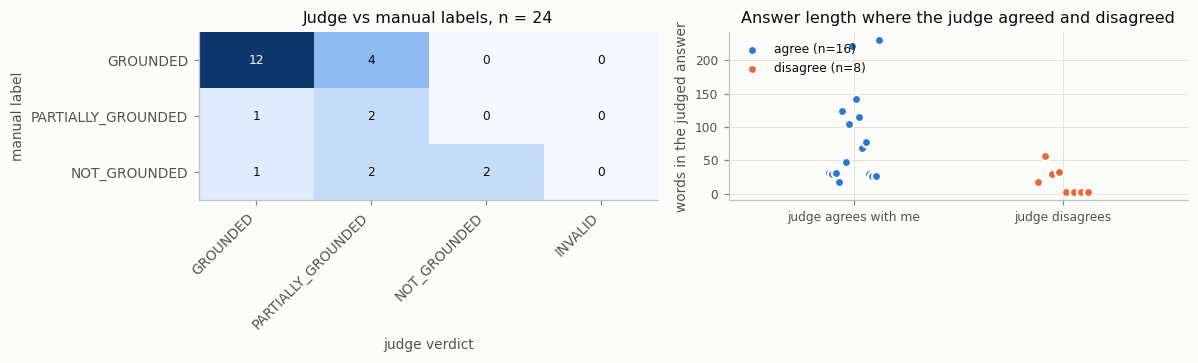

In [ ]:
for k, v in MANUAL_GROUNDEDNESS.items():
    assert v in VERDICTS or v == "", f"{k}: '{v}' is not a valid label"
keys = [k for k in MANUAL_GROUNDEDNESS if k in MANUAL_SHEET and MANUAL_GROUNDEDNESS[k]]
if not keys:
    print("MANUAL_GROUNDEDNESS is empty: fill it from the sheet above and re-run from this cell. n =", len(manual_keys))
    RESULTS["part_e"]["manual_agreement"] = None
else:
    m = [MANUAL_GROUNDEDNESS[k] for k in keys]
    j = [RUNS[k.split("|", 1)[0]][k.split("|", 1)[1]]["judge"]["verdict"] for k in keys]
    a3, a2 = kappa(m, j), kappa([binary(x) for x in m], [binary(x) for x in j])
    print(f"n={len(keys)} | 3-level agreement {a3['agreement']} kappa {a3['kappa']} | binary agreement {a2['agreement']} kappa {a2['kappa']}")
    print("label counts (manual, judge):", a3["counts"])
    conf = pd.crosstab(pd.Series(m, name="manual"), pd.Series(j, name="judge")).reindex(index=VERDICTS, columns=VERDICTS + ["INVALID"]).fillna(0).astype(int)
    display(conf)
    dis = [dict(key=k, manual=mm, judge=jj, answer_words=len((MANUAL_SHEET[k]["answer"] or "").split()),
                rationale=RUNS[k.split("|", 1)[0]][k.split("|", 1)[1]]["judge"]["rationale"][:140]) for k, mm, jj in zip(keys, m, j) if mm != jj]
    print(f"disagreements: {len(dis)}")
    if dis:
        display(pd.DataFrame(dis))
    agree_words = [len((MANUAL_SHEET[k]["answer"] or "").split()) for k, mm, jj in zip(keys, m, j) if mm == jj]
    print(f"mean answer length: agreements {np.mean(agree_words) if agree_words else float('nan'):.0f} words, disagreements "
          f"{np.mean([d['answer_words'] for d in dis]) if dis else float('nan'):.0f} words")
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    draw_heat(ax[0], conf.values, list(conf.index), list(conf.columns), vmin=0, vmax=max(1, conf.values.max()), fmt="{:.0f}", fontsize=8)
    ax[0].set_xlabel("judge verdict"); ax[0].set_ylabel("manual label"); ax[0].set_title(f"Judge vs manual labels, n = {len(keys)}")
    groups = [agree_words, [d["answer_words"] for d in dis]]
    for i_, (g, lab) in enumerate(zip(groups, ("agree", "disagree"))):
        ax[1].scatter(np.full(len(g), i_) + np.linspace(-0.12, 0.12, max(len(g), 1))[:len(g)], g, s=36, color=PAL[i_], edgecolor=SURFACE, linewidth=1.5, label=f"{lab} (n={len(g)})")
    ax[1].set_xticks([0, 1], ["judge agrees with me", "judge disagrees"]); ax[1].set_xlim(-0.6, 1.6); ax[1].set_ylabel("words in the judged answer")
    ax[1].set_title("Answer length where the judge agreed and disagreed"); ax[1].legend(loc="upper left")
    finish(fig, "e_manual_agreement")
    RESULTS["part_e"]["manual_agreement"] = dict(n=len(keys), three_level=a3, binary=a2, confusion=conf.to_dict(), disagreements=dis, labels=MANUAL_GROUNDEDNESS)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הסכמה 0.667 וקאפא 0.396 בשלוש רמות, 0.75 ו-⁠0.471 בשתיים. נטייה לאמצע: 8 PARTIALLY מול 3. ב-⁠RAG הסכמה מלאה, ובשאר שני&nbsp;דפוסים:</p>
<ul>
<li>הקלה ב-⁠closed-book — GROUNDED ל-⁠30 מיליון במקום 35 (Q06) ולחריג מומצא (Q08); PARTIALLY במקום NOT להיפוך 2(12) (Q04) ול-"10%&nbsp;מהמחזור"&nbsp;(Q18)</li>
<li>החמרה בתשובות סוכן קצרות ונכונות (T08 פעמיים ו-⁠T06) — PARTIALLY כי החישוב "אינו בראיות": פלט המחשבון ברשימה, אבל כמספר חשוף, בלי שם הכלי והביטוי, ראו agent_record</li>
<li>ב-⁠T09 השופט קיבל את 24 מיליון מפלט המחשבון; סעיף 101 לא נשלף והנוסחה שגויה (חלק ג׳), כך שה-⁠PARTIALLY סביר והתיוג הידני הוא&nbsp;המקל</li>
</ul>
<p>אורך ממוצע 83 מילים בהסכמות ו-⁠18 באי-ההסכמות, אבל כל 8 תשובות RAG, הארוכות, בהסכמה, וההשוואה מעורבבת בתנאי. באי-ההסכמות השופט הקל בתשובות של 18–57 מילים והחמיר בתשובות של 2–3: תואם הטיית אריכות או סוג תשובה, ו-⁠n=8 אינו מכריע. לעיון: 72.6% ב-⁠InstructGPT, קאפא&nbsp;0.25&nbsp;ב-⁠QLoRA.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת אריכות: תשובות RAG שקיבלו GROUNDED מרופדות ב-⁠PAD, שתי טענות לא נתמכות, ונשפטות שוב; מה שנשאר GROUNDED הוא&nbsp;פספוס.</p>
</div>

In [ ]:
PAD = (" In addition, the Regulation requires every such system to undergo an annual independent audit by the AI Office."
       " Non-compliance also triggers an automatic six-month suspension of the system across the Union.")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>pad_answer: מוסיפה את שתי הטענות הלא-נתמכות לפני שורת ה-⁠ANSWER, כך שהתשובה המרופדת נראית כמו תשובה רגילה.</p>
</div>

In [ ]:
def pad_answer(a):
    lines = (a or "").rstrip().splitlines()
    if lines and re.match(r"^\s*\**ANSWER\**\s*:", lines[-1], re.I):
        return "\n".join(lines[:-1]).rstrip() + PAD + "\n" + lines[-1]
    return (a or "").rstrip() + PAD

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>20 תשובות ה-⁠RAG הראשונות (Q01–Q08) שקיבלו GROUNDED ועונות על השאלה מרופדות ונשפטות. אחריהן הפסקים החדשים, ואורך לפי פסק בכל&nbsp;168&nbsp;התשובות.</p>
</div>

Loading weights:   0%|          | 0/243 [00:00<?, ?it/s]

padded answers: 20 | still judged GROUNDED: 1 ((0.05, 0.009, 0.236)) | at least one unsupported claim listed: 19
still GROUNDED after padding: ['probe|Q05|s2']


,mean,size
verdict,,
GROUNDED,68.6,98
NOT_GROUNDED,35.3,19
PARTIALLY_GROUNDED,35.9,51


,padded answers
GROUNDED,1
PARTIALLY_GROUNDED,19
NOT_GROUNDED,0
INVALID,0


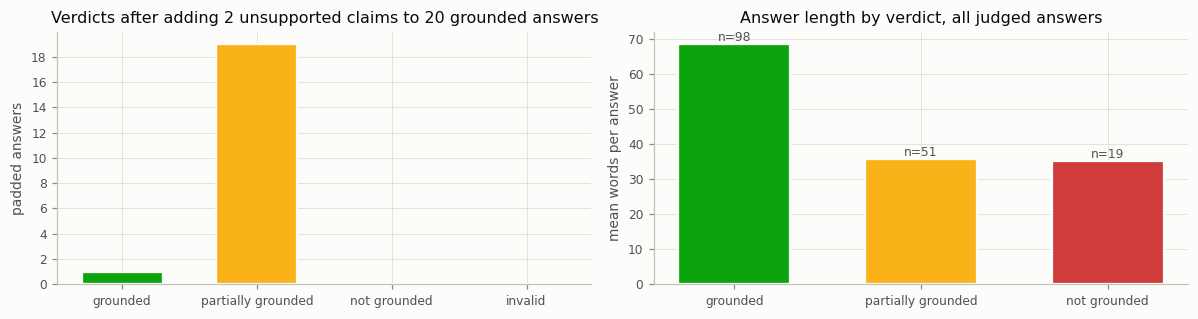

In [ ]:
probe_keys = [k for k in B_KEYS if RUNS["rag"][k]["judge"]["verdict"] == "GROUNDED" and RUNS["rag"][k]["judge"]["answers_question"]][:CFG["n_probe"]]
probe_items = [dict(key=f"probe|{k}", q=ITEM_TEXT[k.split("|")[0]], a=pad_answer(RUNS["rag"][k]["answer"]), evidence=RUNS["rag"][k]["evidence"]) for k in probe_keys]
probe = judge_groundedness(probe_items, label="E-probe") if probe_items else []
free_judge()
still = sum(1 for v in probe if v["verdict"] == "GROUNDED")
caught = sum(1 for v in probe if v["n_unsupported"] >= 1)
print(f"padded answers: {len(probe)} | still judged GROUNDED: {still} ({wilson(still, len(probe))}) | at least one unsupported claim listed: {caught}")
print("still GROUNDED after padding:", [it["key"] for it, v in zip(probe_items, probe) if v["verdict"] == "GROUNDED"])
verdict_len = pd.DataFrame([dict(cond=cond, verdict=RUNS[cond][k]["judge"]["verdict"], words=len((RUNS[cond][k]["answer"] or "").split()))
                            for cond, keys in CONSIST for k in keys]).groupby("verdict").words.agg(["mean", "size"]).round(1)
display(verdict_len)
probe_counts = pd.Series(Counter(v["verdict"] for v in probe)).reindex(VERDICTS + ["INVALID"]).fillna(0).astype(int)
display(probe_counts.rename("padded answers").to_frame())
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].bar(range(len(probe_counts)), probe_counts.values, color=[VERDICT_COLOR[v] for v in probe_counts.index], edgecolor=SURFACE, linewidth=1.5, width=0.6)
ax[0].set_xticks(range(len(probe_counts)), [v.replace("_", " ").lower() for v in probe_counts.index], fontsize=8)
ax[0].set_ylabel("padded answers"); ax[0].set_title(f"Verdicts after adding 2 unsupported claims to {len(probe)} grounded answers")
ax[0].yaxis.set_major_locator(MaxNLocator(integer=True))
vl = verdict_len.reindex([v for v in VERDICTS + ["INVALID"] if v in verdict_len.index])
ax[1].bar(range(len(vl)), vl["mean"], color=[VERDICT_COLOR[v] for v in vl.index], edgecolor=SURFACE, linewidth=1.5, width=0.6)
for x_, (m_, n_) in enumerate(zip(vl["mean"], vl["size"])):
    ax[1].text(x_, m_, f"n={int(n_)}", ha="center", va="bottom", fontsize=8, color=INK2)
ax[1].set_xticks(range(len(vl)), [v.replace("_", " ").lower() for v in vl.index], fontsize=8)
ax[1].set_ylabel("mean words per answer"); ax[1].set_title("Answer length by verdict, all judged answers")
finish(fig, "e_verbosity")
RESULTS["part_e"]["verbosity_probe"] = dict(n=len(probe), still_grounded=still, unsupported_listed=caught, still_rate=wilson(still, len(probe)),
                                            length_by_verdict=verdict_len.to_dict("index"))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>20 תשובות RAG רופדו בשתי טענות בדויות. 19 ירדו ל-⁠PARTIALLY_GROUNDED ואחת נשארה GROUNDED, שיעור 0.05 ורווח סמך&nbsp;0.01–0.24.</p>
<ul>
<li>הפספוס ב-⁠Q05 seed 2, רשימת הפרקטיקות האסורות: ככל הנראה תקרת 6 הטענות מוצתה לפני הריפוד. אם כך, זו חולשת התקרה ולא&nbsp;אריכות</li>
<li>אורך לפי פסק — GROUNDED 68.6 מילים (n=98), PARTIALLY 35.9 (51), NOT_GROUNDED 35.3 (19). הפער אינו ראיה להטיית אריכות: תשובות RAG ארוכות והן 52 מ-⁠98 ה-⁠GROUNDED, ותשובות closed-book והסוכן קצרות ונופלות יותר. בבדיקה היזומה, בתנאי קבוע, טענות בדויות שהוסיפו אורך לא זכו&nbsp;לתגמול</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק ה׳:</p>
<ul>
<li>עקביות בהיפוך סדר — קאפא 0.66 ב-⁠3 רמות ו-⁠0.70 ב-⁠2 (n=168). 30 מ-⁠31 ההיפוכים בין רמות סמוכות; 21 עלו ו-⁠10 ירדו: נטייה להקלה בסדר ההפוך, לא&nbsp;מכריעה</li>
<li>מול תיוג ידני — קאפא 0.40 ב-⁠3 רמות (n=24), וב-⁠RAG הסכמה מלאה. שני דפוסים, 4 פריטים כל אחד: מקל ב-⁠closed-book, מחמיר בתשובות סוכן קצרות שהמספר בהן מחושב ומוצג לו&nbsp;חשוף</li>
<li>אי-יציבות בנדירים — ב-⁠RAG הסכמה 93% אבל קאפא 0.04-: שני החריגים שונים בכל סדר. פסק בודד מחייב בדיקה, לא&nbsp;מסקנה</li>
<li>מבוסס אינו נכון — 7 ריצות שנכשלו קיבלו GROUNDED, ו-⁠6 מ-⁠20 תשובות RAG מבוססות בחלק ו׳ שגויות: השופט בודק תמיכה, לא&nbsp;הרכבה</li>
<li>רגישות למדידה — פיצול הסעיפים לבדו הוריד NOT_GROUNDED של function&nbsp;calling מ-⁠12 בהרצה מוקדמת ל-⁠5: יותר מפער&nbsp;הגישות</li>
<li>הטיית אריכות — לא נמצאה בבדיקה היזומה: 19 מ-⁠20 תשובות שרופדו בטענות בדויות ירדו מ-⁠GROUNDED; ריפוד בתוכן נתמך לא נבדק. פער האורך בין הפסקים מוסבר&nbsp;בתנאי</li>
<li>תקרת הטענות — לפי יומן הקריאות, 172 מ-⁠502 פסקים הגיעו ל-⁠6 טענות ומעלה, 21 מהם מעבר לתקרה, ברוב התשובות הארוכות: חלק הלא-נתמכות הוא חסם תחתון, ותשובה ארוכה נבדקת&nbsp;חלקית</li>
</ul>
<p>השופט שימושי כמדד מצרפי גס: מוטה לפי סוג התשובה ורגיש לסדר, ולכן פער קטן בין תנאים, ופסק בודד, אינם מכריעים. מגבלות: ריפוד אחד, הפרעת סדר אחת, 24 פריטים ומתייג יחיד: די לדפוסים, לא לאמידת&nbsp;קאפא.</p>
</div>

In [ ]:
checkpoint("Part E")

[checkpoint after Part E] /content/drive/MyDrive/FM/Final_Project/outputs/project_results.json (1.20 MB) | cache hits 3, misses 662


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלק ו׳ — אבלציה</p>
<ul>
<li>שלושה תנאים — LLM בלבד, RAG בלבד וסוכן מלא ב-⁠function&nbsp;calling — על אותם 28 פריטים, 18 שאילתות ו-⁠10 משימות, ב-⁠3&nbsp;seeds</li>
<li>הצלחה: במשימות בדיקה אוטומטית, בשאילתות פסק השופט GROUNDED ועונה לשאלה. לכן שלושה חתכים: כל הפריטים, משימות&nbsp;ושאילתות</li>
<li>הזיה: שיעור הפסקים שאינם GROUNDED מבין התקינים, וברמת הטענה חלק הטענות&nbsp;הלא-נתמכות</li>
<li>יעילות: קריאות למודל ולכלים, טוקני פרומפט ויצירה בנפרד, כמו prefill מול decode בהרצאה 3, וזמן&nbsp;לפריט</li>
<li>יציבות: הצלחה לפי seed, ו-⁠pass^3 על&nbsp;המשימות</li>
<li>שאלת הניתוח: היכן הסוכן השתפר הכי הרבה, והיכן RAG בלבד הספיק והסוכן רק הוסיף&nbsp;מורכבות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>השלמת ריצות: משימות ל-⁠LLM בלבד ול-⁠RAG, ושאילתות לסוכן, שמשימותיו מחלק ג׳. שיפוט, והצלחה בשאילתות היא GROUNDED שעונה&nbsp;לשאלה.</p>
</div>

Loading weights:   0%|          | 0/243 [00:00<?, ?it/s]

records per condition: 84 | agent calls so far 477, 39.0 min


,Q01,Q02,Q03,Q04,Q05,Q06,Q07,Q08,Q09,Q10,...,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10
llm_only,0.67,1.00,0.00,0.33,0.67,0.67,0.0,1.0,1.0,0.33,...,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00
rag,1.00,0.67,1.00,1.00,0.67,1.00,1.0,1.0,1.0,1.00,...,1.00,1.0,0.0,0.00,0.0,0.00,0.0,1.0,0.0,1.00
agent_fc,1.00,0.33,0.67,1.00,1.00,0.67,0.0,1.0,1.0,0.33,...,0.33,1.0,1.0,0.33,0.0,0.67,0.0,1.0,1.0,0.67


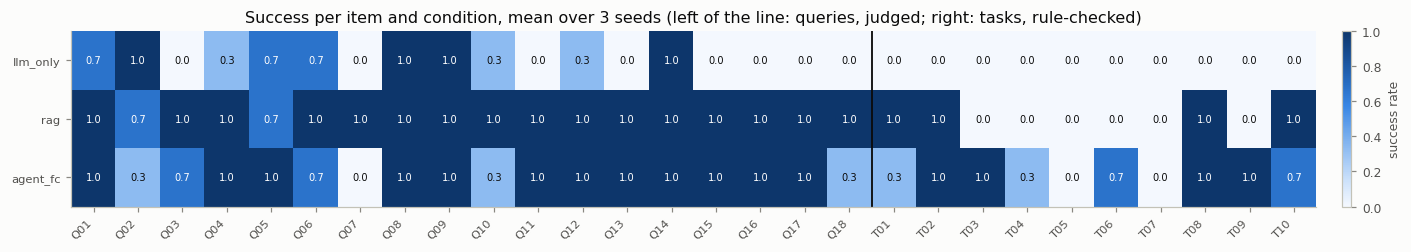

In [ ]:
for t in TASKS:
    for seed in CFG["seeds"]:
        for cond, fn in (("llm_only", answer_llm_only), ("rag", answer_rag)):
            RUNS[cond][rkey(t["id"], seed)] = fn(t["q"], seed)
            RUNS[cond][rkey(t["id"], seed)]["success"] = bool(t["check"](RUNS[cond][rkey(t["id"], seed)]["answer"]))
for q in QUERIES:
    for seed in CFG["seeds"]:
        tr = run_function_calling(dict(id=q["id"], q=q["q"], chain=[], last=None, check=None), seed)
        tr["success"], tr["chain_ok"] = bool(tr["final"]), True
        RUNS["agent_fc"][rkey(q["id"], seed)] = agent_record(tr)
        RESULTS["traces"].append(tr)
judge_runs("llm_only", C_KEYS, "F")
judge_runs("rag", C_KEYS, "F")
judge_runs("agent_fc", B_KEYS, "F")
free_judge()
for cond in ("llm_only", "rag", "agent_fc"):
    for k in B_KEYS:
        RUNS[cond][k]["success"] = RUNS[cond][k]["judge"]["verdict"] == "GROUNDED" and RUNS[cond][k]["judge"]["answers_question"]
ALL_KEYS = B_KEYS + C_KEYS
print(f"records per condition: {len(ALL_KEYS)} | agent calls so far {AGENT.calls}, {AGENT.seconds / 60:.1f} min")
item_ids = [q["id"] for q in QUERIES] + [t["id"] for t in TASKS]
succ_map = pd.DataFrame({c: [float(np.mean([bool(RUNS[c][rkey(i, s)].get("success")) for s in CFG["seeds"]])) for i in item_ids] for c in ("llm_only", "rag", "agent_fc")}, index=item_ids)
display(succ_map.T.round(2))
fig, ax = plt.subplots(figsize=(13, 2.4))
draw_heat(ax, succ_map.T.values, list(succ_map.columns), list(succ_map.index), vmin=0, vmax=1, fmt="{:.1f}", fontsize=6.5, cbar_label="success rate")
ax.axvline(len(QUERIES) - 0.5, color=INK, linewidth=1.2)
ax.set_title(f"Success per item and condition, mean over {len(CFG['seeds'])} seeds (left of the line: queries, judged; right: tasks, rule-checked)")
finish(fig, "f_success_map")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>84 רשומות לתנאי: 54 שאילתות, 30 משימות. עד כאן מודל הסוכן נקרא 477 פעמים, 39.0 דקות. מפת&nbsp;ההצלחה:</p>
<ul>
<li>ב-⁠LLM בלבד — אפס במשימות. בשאילתות הצלחה מלאה בעקרוניות, Q08, Q09 ו-⁠Q14, וב-⁠Q02, אף ששתיים שגויות: הקלת השופט מחלק&nbsp;ב׳</li>
<li>ב-⁠RAG בלבד — השאילתות תמיד, חוץ מ-⁠Q02 ו-⁠Q05. במשימות T01, T02, T08 ו-⁠T10: שליפה, וב-⁠T08 חיסור; בשאר מרשם, תאריך,&nbsp;סף</li>
<li>בסוכן — T02, T03, T08 ו-⁠T09 בכל ה-⁠seeds; T05 ו-⁠T07 אף פעם. בשאילתות 12 מתוך 18 בכל ה-⁠seeds, ו-⁠Q07 אף&nbsp;פעם</li>
</ul>
<p>יתרון הסוכן מרוכז ב-⁠4 משימות, T03, T04, T06 ו-⁠T09, ובשאילתה Q05; חסרונו ב-⁠6 שאילתות ובשתי משימות של צעד אחד, T01&nbsp;ו-⁠T10.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>cond_stats: מסכמת תנאי: הצלחה, והזיה מבין התקינים, שתיהן עם רווח Wilson; חלק הטענות הלא-נתמכות, הימנעות, פסולים&nbsp;ויעילות.</p>
</div>

In [ ]:
def cond_stats(cond, keys):
    recs = [RUNS[cond][k] for k in keys]
    n = len(recs)
    valid = [r for r in recs if r["judge"]["verdict"] in VERDICTS]
    succ = sum(bool(r.get("success")) for r in recs)
    hall = sum(r["judge"]["verdict"] != "GROUNDED" for r in valid)
    claims = sum(r["judge"]["n_claims"] for r in valid)
    unsup = sum(r["judge"]["n_unsupported"] for r in valid)
    return dict(condition=cond, n=n, success=succ, success_rate=wilson(succ, n), hallucination_rate=wilson(hall, len(valid)),
                unsupported_claim_share=round(unsup / claims, 3) if claims else float("nan"),
                abstain_rate=round(sum(not r["judge"]["answers_question"] for r in recs) / n, 3), invalid_judge=n - len(valid),
                llm_calls=round(float(np.mean([r["llm_calls"] for r in recs])), 2), tool_calls=round(float(np.mean([r["tool_calls"] for r in recs])), 2),
                prompt_tokens=round(float(np.mean([r["prompt_tokens"] for r in recs])), 0), gen_tokens=round(float(np.mean([r["gen_tokens"] for r in recs])), 0),
                seconds=round(float(np.mean([r["seconds"] for r in recs])), 2))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלוש טבלאות: כל הפריטים, משימות ושאילתות. הצלחה לפי seed, כי מסקנה אמינה מחזיקה בכולם, ו-⁠pass^3 למשימה: פתרון בכל&nbsp;seed.</p>
</div>

all items


,n,success,success_rate,hallucination_rate,unsupported_claim_share,abstain_rate,invalid_judge,llm_calls,tool_calls,prompt_tokens,gen_tokens,seconds
condition,,,,,,,,,,,,
llm_only,84,21,"(0.25, 0.17, 0.352)","(0.714, 0.61, 0.8)",0.361,0.036,0,1.00,0.00,133.0,49.0,2.64
rag,84,64,"(0.762, 0.661, 0.84)","(0.202, 0.13, 0.3)",0.121,0.107,0,1.00,0.00,1035.0,104.0,6.53
agent_fc,84,61,"(0.726, 0.623, 0.81)","(0.321, 0.231, 0.427)",0.125,0.024,0,2.37,1.52,3474.0,192.0,11.25


tasks only (rule-based success)


,n,success,success_rate,hallucination_rate,unsupported_claim_share,abstain_rate,invalid_judge,llm_calls,tool_calls,prompt_tokens,gen_tokens,seconds
condition,,,,,,,,,,,,
llm_only,30,0,"(0.0, 0.0, 0.114)","(0.9, 0.744, 0.965)",0.583,0.100,0,1.00,0.00,158.0,44.0,2.42
rag,30,12,"(0.4, 0.246, 0.577)","(0.5, 0.332, 0.668)",0.520,0.300,0,1.00,0.00,1026.0,27.0,2.54
agent_fc,30,18,"(0.6, 0.423, 0.754)","(0.533, 0.361, 0.698)",0.300,0.067,0,3.03,2.47,4983.0,158.0,9.91


queries only (judge-based success)


,n,success,success_rate,hallucination_rate,unsupported_claim_share,abstain_rate,invalid_judge,llm_calls,tool_calls,prompt_tokens,gen_tokens,seconds
condition,,,,,,,,,,,,
llm_only,54,21,"(0.389, 0.27, 0.522)","(0.611, 0.478, 0.73)",0.261,0.0,0,1.0,0.0,118.0,52.0,2.76
rag,54,52,"(0.963, 0.875, 0.99)","(0.037, 0.01, 0.125)",0.004,0.0,0,1.0,0.0,1040.0,147.0,8.75
agent_fc,54,43,"(0.796, 0.671, 0.882)","(0.204, 0.118, 0.329)",0.065,0.0,0,2.0,1.0,2636.0,212.0,11.99


success rate per seed, all items


,seed 1,seed 2,seed 3,min,max
llm_only,0.214,0.250,0.286,0.214,0.286
rag,0.750,0.786,0.750,0.750,0.786
agent_fc,0.750,0.750,0.679,0.679,0.750


pass^3 per task and condition


,llm_only,rag,agent_fc
T01,0.0,1.0,0.0
T02,0.0,1.0,1.0
T03,0.0,0.0,1.0
T04,0.0,0.0,0.0
T05,0.0,0.0,0.0
T06,0.0,0.0,0.0
T07,0.0,0.0,0.0
T08,0.0,1.0,1.0
T09,0.0,0.0,1.0
T10,0.0,1.0,0.0


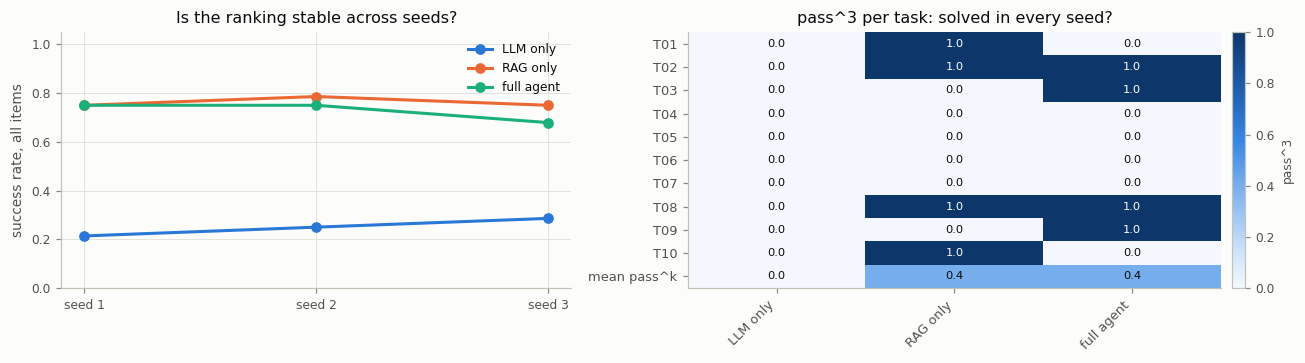

In [ ]:
CONDS = ["llm_only", "rag", "agent_fc"]
abl_all = pd.DataFrame([cond_stats(c, ALL_KEYS) for c in CONDS]).set_index("condition")
abl_tasks = pd.DataFrame([cond_stats(c, C_KEYS) for c in CONDS]).set_index("condition")
abl_queries = pd.DataFrame([cond_stats(c, B_KEYS) for c in CONDS]).set_index("condition")
print("all items"); display(abl_all)
print("tasks only (rule-based success)"); display(abl_tasks)
print("queries only (judge-based success)"); display(abl_queries)
per_seed = pd.DataFrame({f"seed {s}": {c: cond_stats(c, [k for k in ALL_KEYS if k.endswith(f"|s{s}")])["success_rate"][0] for c in CONDS} for s in CFG["seeds"]})
per_seed["min"], per_seed["max"] = per_seed.min(axis=1), per_seed.max(axis=1)
print("success rate per seed, all items"); display(per_seed)
n_seeds = len(CFG["seeds"])
passk = pd.DataFrame({c: {t["id"]: pass_hat_k(n_seeds, sum(bool(RUNS[c][rkey(t["id"], s)]["success"]) for s in CFG["seeds"]), n_seeds) for t in TASKS} for c in CONDS})
passk.loc["mean pass^k"] = passk.mean()
print(f"pass^{n_seeds} per task and condition"); display(passk.round(2))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw=dict(width_ratios=[1, 1.1]))
seeds_cols = [f"seed {s}" for s in CFG["seeds"]]
for c in CONDS:
    ax[0].plot(range(len(seeds_cols)), per_seed.loc[c, seeds_cols].values, marker="o", color=COLOR[c], label=COND_NAME[c])
ax[0].set_xticks(range(len(seeds_cols)), seeds_cols); ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("success rate, all items")
ax[0].set_title("Is the ranking stable across seeds?"); ax[0].legend(loc="upper right")
draw_heat(ax[1], passk.values, list(passk.index), ["LLM only", "RAG only", "full agent"], vmin=0, vmax=1, fmt="{:.1f}", fontsize=7.5, cbar_label=f"pass^{n_seeds}")
ax[1].set_title(f"pass^{n_seeds} per task: solved in every seed?")
finish(fig, "f_seeds_passk")
RESULTS["part_f"] = dict(all=abl_all.astype(str).to_dict("index"), tasks=abl_tasks.astype(str).to_dict("index"), queries=abl_queries.astype(str).to_dict("index"),
                         per_seed=per_seed.round(3).to_dict(), pass_hat_k=passk.round(3).to_dict())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושת החתכים:</p>
<ul>
<li>כל הפריטים, מתוך 84 — LLM בלבד 21, 0.25 (0.17–0.35); RAG 64, 0.76 (0.66–0.84); סוכן 61, 0.73 (0.62–0.81). רווחי RAG והסוכן&nbsp;חופפים</li>
<li>משימות — 0, 12 ו-⁠18 מתוך 30: 0 (0–0.11), 0.40 (0.25–0.58), 0.60 (0.42–0.75). הסוכן מוביל, רווחים חופפים</li>
<li>שאילתות — 21, 52 ו-⁠43 מתוך 54: 0.39, 0.96 (0.88–0.99), 0.80 (0.67–0.88). RAG מוביל</li>
<li>הזיה — לא מבוססות במלואן: 0.71, 0.20, 0.32. ברמת הטענה RAG והסוכן כמעט שווים, 0.121 ו-⁠0.125, מול 0.361</li>
<li>הימנעות, לפי דגל השופט — RAG ב-⁠9 מ-⁠30 ריצות משימות: T03, T04 ו-⁠T09 בכל ה-⁠seeds, כי המרשם אינו בקורפוס; ב-⁠T09 ענה 15 מיליון, הקנס הקבוע בלי המחזור. הסוכן ב-⁠2 ו-⁠LLM בלבד&nbsp;ב-⁠3</li>
<li>יעילות — סוכן: 2.37 למודל, 1.52 לכלים, 3,474 פרומפט, 192 יצירה, 11.25 שניות. RAG: 1,035, 104, 6.53. פי 3.4 בפרומפט, 1.8 ביצירה, 1.7&nbsp;בזמן</li>
<li>יציבות — RAG לא נמוך מהסוכן באף seed: סוכן 0.750, 0.750, 0.679; RAG 0.750, 0.786, 0.750; LLM בלבד 0.214–0.286. בין RAG לסוכן פער 0–2&nbsp;מ-⁠28</li>
<li>מדד pass^3 — 0.4 לשניהם, על סטים שונים בחלקם: RAG T01, T02, T08 ו-⁠T10; סוכן T02, T03, T08 ו-⁠T09. LLM בלבד אפס</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה גרפים: הצלחה והזיה בשלושת החתכים, והצלחה מול טוקנים שנוצרו על כל הפריטים, כ-⁠Pareto frontier בהרצאה 8, וטבלה עם&nbsp;הרווחים.</p>
</div>

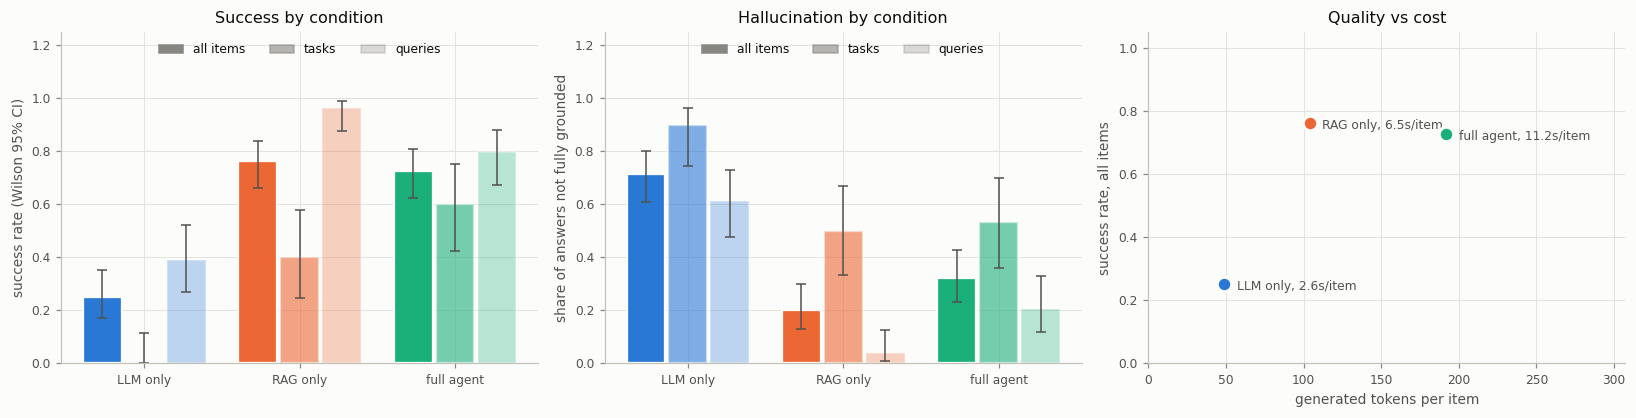

,LLM only,RAG only,full agent
"success, all",0.25 [0.17-0.35],0.76 [0.66-0.84],0.73 [0.62-0.81]
"success, tasks",0.00 [0.00-0.11],0.40 [0.25-0.58],0.60 [0.42-0.75]
"success, queries",0.39 [0.27-0.52],0.96 [0.88-0.99],0.80 [0.67-0.88]
"not fully grounded, all",0.71 [0.61-0.80],0.20 [0.13-0.30],0.32 [0.23-0.43]
unsupported claims share,0.361,0.121,0.125
generated tokens / item,49.0,104.0,192.0
seconds / item,2.64,6.53,11.25


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.9))
cuts = (("all items", abl_all, 1.0), ("tasks", abl_tasks, 0.6), ("queries", abl_queries, 0.3))
for panel, metric, title, ylab in ((0, "success_rate", "Success by condition", "success rate (Wilson 95% CI)"),
                                   (1, "hallucination_rate", "Hallucination by condition", "share of answers not fully grounded")):
    for j, (label, tab, alpha) in enumerate(cuts):
        bars_ci(ax[panel], np.arange(len(CONDS)) + (j - 1) * 0.27, tab[metric].tolist(), [COLOR[c] for c in CONDS], width=0.25, alpha=alpha)
    ax[panel].set_xticks(np.arange(len(CONDS)), ["LLM only", "RAG only", "full agent"]); ax[panel].set_ylim(0, 1.25)
    ax[panel].set_ylabel(ylab); ax[panel].set_title(title)
    ax[panel].legend([plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=a) for _, _, a in cuts], [l for l, _, _ in cuts], loc="upper center", ncol=3)
for c in CONDS:
    ax[2].scatter(abl_all.loc[c, "gen_tokens"], abl_all.loc[c, "success_rate"][0], s=90, color=COLOR[c], edgecolor=SURFACE, linewidth=2, zorder=3)
    ax[2].annotate(f"{COND_NAME[c]}, {abl_all.loc[c, 'seconds']:.1f}s/item",
                   (abl_all.loc[c, "gen_tokens"], abl_all.loc[c, "success_rate"][0]), textcoords="offset points", xytext=(8, -4), fontsize=8, color=INK2)
ax[2].set_xlabel("generated tokens per item"); ax[2].set_ylabel("success rate, all items"); ax[2].set_ylim(0, 1.05)
ax[2].set_xlim(0, abl_all.gen_tokens.max() * 1.6); ax[2].set_title("Quality vs cost")
finish(fig, "f_ablation")
twin = pd.DataFrame({c: {"success, all": ci_text(abl_all.loc[c, "success_rate"]), "success, tasks": ci_text(abl_tasks.loc[c, "success_rate"]),
                         "success, queries": ci_text(abl_queries.loc[c, "success_rate"]), "not fully grounded, all": ci_text(abl_all.loc[c, "hallucination_rate"]),
                         "unsupported claims share": abl_all.loc[c, "unsupported_claim_share"], "generated tokens / item": abl_all.loc[c, "gen_tokens"],
                         "seconds / item": abl_all.loc[c, "seconds"]} for c in CONDS})
twin.columns = ["LLM only", "RAG only", "full agent"]
display(twin)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בגרף השמאלי הסוכן מוביל רק בחתך המשימות, ו-⁠RAG בשאילתות ובכלל הפריטים. באמצעי RAG המבוסס ביותר בכל חתך; במשימות RAG והסוכן כמעט שווים, 0.50 מול 0.53, וזה כולל 6 הימנעויות של RAG שנפסקו GROUNDED; בקרב התשובות שענו, הסוכן מבוסס יותר במשימות, 14 מ-⁠28 מול 9 מ-⁠21. בימני, איכות מול עלות על כל הפריטים, RAG שולט בסוכן: 0.76 מול 0.73, ב-⁠104 טוקנים במקום 192 וב-⁠6.53 שניות במקום 11.25, אף שהרווחים חופפים. ל-⁠LLM בלבד העלות הנמוכה ביותר, אך גם ההצלחה הנמוכה ביותר, 0.25. הסוכן אינו על החזית, ומשתלם רק&nbsp;במשימות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת נכונות בלי שופט: ל-⁠7 מתוך 18 השאילתות, שיש להן תשובה חדה, נכתבה בדיקה אוטומטית לפי לשון החוק על שורת&nbsp;ANSWER:</p>
<ul>
<li>ב-⁠Q02 — סינון קורות חיים הוא בסיכון גבוה, נספח III נקודה 4(a); נכון רק yes או high-risk בלי הסתייגות</li>
<li>ב-⁠Q03 — חובות GPAI מ-⁠2.8.2025, סעיף 113(b)</li>
<li>ב-⁠Q06 — עד 35 מיליון יורו או 7%, סעיף 99(3); נבדק הסכום</li>
<li>ב-⁠Q07 — סף 10^25 פעולות חישוב, סעיף 51(2)</li>
<li>ב-⁠Q10 — כן, אלא אם ברור מההקשר, סעיף 50(1); נבדק ה-⁠yes בפתיחה</li>
<li>ב-⁠Q16 — 10 שנים לתיעוד וחצי שנה ללוגים, סעיפים 18(1) ו-⁠26(6); נדרשים שניהם</li>
<li>ב-⁠Q18 — עד 7.5 מיליון יורו או 1%, סעיף 99(5); נבדק הסכום</li>
</ul>
</div>

In [ ]:
FACTS = {
    "Q02": ("high-risk, Annex III point 4", lambda l: bool(re.match(r"\W*(yes|high-risk)\b", l, re.I)) and not re.search(r"\bno\b|\bnot\b|low-risk", l, re.I)),
    "Q03": ("2 August 2025", lambda l: bool(re.search(r"\b2 august,? 2025|august 2,? 2025|2025-08-02", l, re.I))),
    "Q06": ("EUR 35 million or 7%", lambda l: any(abs(x - 35e6) < 1 for x in nums_in(l))),
    "Q07": ("10^25 floating point operations", lambda l: bool(re.search(r"10\s*\^\s*\{?\s*25\b|10\s*\*\*\s*25\b|\b1e\+?25\b", l, re.I)) or any(abs(x - 1e25) < 1e23 for x in nums_in(l))),
    "Q10": ("yes, unless it is obvious", lambda l: bool(re.match(r"\W*yes\b", l, re.I))),
    "Q16": ("10 years and 6 months", lambda l: bool(re.search(r"\b(10|ten) years\b", l, re.I)) and bool(re.search(r"\b(6|six) months\b", l, re.I))),
    "Q18": ("EUR 7.5 million or 1%", lambda l: any(abs(x - 7.5e6) < 1 for x in nums_in(l))),
}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>fact_ok: בודקת את שורת ה-⁠ANSWER של שאילתה, ובהיעדרה את השורה האחרונה, מול הבדיקה שלה ב-⁠FACTS.</p>
</div>

In [ ]:
def fact_ok(qid, answer):
    return bool(FACTS[qid][1](answer_line(answer)))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נכונות לכל תנאי: טבלת סיכום עם רווח Wilson, טבלה לפי שאילתה, וגרף: שיעור הנכונות והצלבתו עם פסק השופט. בתא&nbsp;grounded,&nbsp;wrong תשובות שאושרו אך&nbsp;שגויות.</p>
</div>

,n,correct,correct_rate,judged_grounded,grounded_but_wrong,correct_not_grounded
condition,,,,,,
llm_only,21,2,0.10 [0.03-0.29],6,5,1
rag,21,14,0.67 [0.45-0.83],20,6,0
agent_fc,21,8,0.38 [0.21-0.59],10,5,3


condition,expected answer,llm_only,rag,agent_fc
query,,,,
Q02,"high-risk, Annex III point 4",0.33,0.00,0.33
Q03,2 August 2025,0.00,0.00,0.00
Q06,EUR 35 million or 7%,0.00,1.00,1.00
Q07,10^25 floating point operations,0.00,1.00,0.00
Q10,"yes, unless it is obvious",0.33,1.00,0.00
Q16,10 years and 6 months,0.00,1.00,0.33
Q18,EUR 7.5 million or 1%,0.00,0.67,1.00


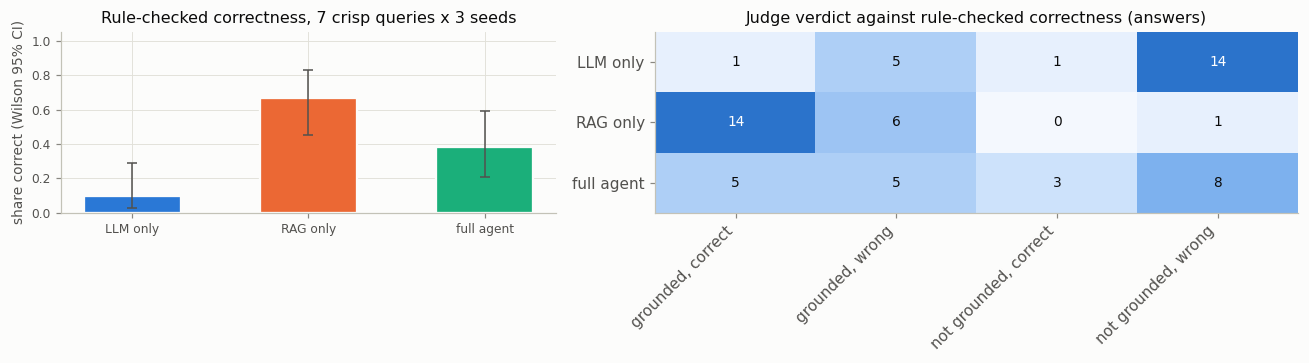

In [ ]:
QIDS = {q["id"] for q in QUERIES}
FACT_KEYS = [rkey(q, s) for q in FACTS if q in QIDS for s in CFG["seeds"]]
fact_df = pd.DataFrame([dict(condition=c, key=k, query=k.split("|")[0], correct=fact_ok(k.split("|")[0], RUNS[c][k]["answer"]),
                             grounded=RUNS[c][k]["judge"]["verdict"] == "GROUNDED") for c in CONDS for k in FACT_KEYS])
fact_tab = pd.DataFrame([dict(condition=c, n=len(g), correct=int(g.correct.sum()), correct_rate=ci_text(wilson(int(g.correct.sum()), len(g))),
                              judged_grounded=int(g.grounded.sum()), grounded_but_wrong=int((g.grounded & ~g.correct).sum()),
                              correct_not_grounded=int((~g.grounded & g.correct).sum())) for c, g in fact_df.groupby("condition", sort=False)]).set_index("condition")
display(fact_tab)
per_q = fact_df.pivot_table(index="query", columns="condition", values="correct", aggfunc="mean")[CONDS].round(2)
per_q.insert(0, "expected answer", [FACTS[q][0] for q in per_q.index])
display(per_q)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw=dict(width_ratios=[1, 1.3]))
bars_ci(ax[0], np.arange(len(CONDS)), [wilson(int(fact_tab.loc[c, "correct"]), int(fact_tab.loc[c, "n"])) for c in CONDS], [COLOR[c] for c in CONDS], width=0.55)
ax[0].set_xticks(np.arange(len(CONDS)), [COND_NAME[c] for c in CONDS]); ax[0].set_ylim(0, 1.05)
ax[0].set_ylabel("share correct (Wilson 95% CI)")
ax[0].set_title(f"Rule-checked correctness, {len(FACT_KEYS) // len(CFG['seeds'])} crisp queries x {len(CFG['seeds'])} seeds")
quad = pd.DataFrame({c: [int((g.grounded & g.correct).sum()), int((g.grounded & ~g.correct).sum()), int((~g.grounded & g.correct).sum()), int((~g.grounded & ~g.correct).sum())]
                     for c, g in fact_df.groupby("condition", sort=False)}, index=["grounded, correct", "grounded, wrong", "not grounded, correct", "not grounded, wrong"])[CONDS]
draw_heat(ax[1], quad.T.values, [COND_NAME[c] for c in CONDS], list(quad.index), vmin=0, vmax=max(1, len(FACT_KEYS)), fmt="{:.0f}", fontsize=9)
ax[1].set_title("Judge verdict against rule-checked correctness (answers)")
finish(fig, "f_correctness")
RESULTS["part_f"]["correctness"] = dict(summary=fact_tab.to_dict("index"), per_query=per_q.to_dict("index"), quadrants=quad.to_dict())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נכונות בלי שופט, מתוך 21: ל-⁠LLM בלבד 2, 0.10 (0.03–0.29); ל-⁠RAG 14, 0.67 (0.45–0.83); לסוכן 8, 0.38&nbsp;(0.21–0.59). הדירוג&nbsp;זהה&nbsp;לשופט.</p>
<ul>
<li>ב-⁠LLM בלבד — 6 GROUNDED, 5 מהן שגויות: 30 מיליון ב-⁠Q06, low-risk ב-⁠Q02 ועמומה ב-⁠Q10. GROUNDED כאן כמעט לא מעיד על&nbsp;נכונות</li>
<li>ב-⁠RAG — 20 מ-⁠21 GROUNDED, 6 מהן שגויות: Q03 בכל ה-⁠seeds, 2.8.2027 מסעיף 111; Q02 בשניים, נספח III לא אוחזר; ו-⁠Q18 פעם,&nbsp;סינתזה</li>
<li>בסוכן — 10 GROUNDED, 5 מהן שגויות: Q03 בשניים, 2.8.2027 כמו RAG; Q16 בשניים, מסעיף 59; Q10 פעם. 3 נכונות לא אושרו: Q18 בשני seeds ו-⁠Q06 באחד. ב-⁠Q07, שלא אושרה, מצא 10^25 וכתב ב-⁠ANSWER&nbsp;10^24</li>
<li>לפי שאילתה — Q03 שגויה תמיד: RAG והסוכן לא הביאו את סעיף 113 באף seed, ו-⁠LLM בלבד אינו מאחזר. RAG נכון בכל ה-⁠seeds ב-⁠Q06, Q07, Q10 ו-⁠Q16; הסוכן רק ב-⁠Q06&nbsp;ו-⁠Q18</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>item_rate: מחזירה את שיעור ההצלחה של פריט בתנאי, ממוצע על&nbsp;ה-⁠seeds.</p>
</div>

In [ ]:
def item_rate(cond, item_id):
    return float(np.mean([bool(RUNS[cond][rkey(item_id, s)]["success"]) for s in CFG["seeds"]]))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>היכן הסוכן עזר והיכן הזיק: הפרש ההצלחה בין הסוכן ל-⁠RAG לכל פריט, ממוצע על ה-⁠seeds. בירוק הסוכן עדיף, בכתום RAG; בתיקו אין&nbsp;עמודה.</p>
</div>

agent helped most:


,kind,llm_only,rag,agent,agent_minus_rag
item,,,,,
T03,task,0.000000,0.000000,1.000000,1.00
T09,task,0.000000,0.000000,1.000000,1.00
T06,task,0.000000,0.000000,0.666667,0.67
Q05,query,0.666667,0.666667,1.000000,0.33
T04,task,0.000000,0.000000,0.333333,0.33


RAG alone was enough and the agent did worse:


,kind,llm_only,rag,agent,agent_minus_rag
item,,,,,
Q02,query,1.000000,0.666667,0.333333,-0.33
Q03,query,0.000000,1.000000,0.666667,-0.33
Q06,query,0.666667,1.000000,0.666667,-0.33
Q07,query,0.000000,1.000000,0.000000,-1.00
Q10,query,0.333333,1.000000,0.333333,-0.67
Q18,query,0.000000,1.000000,0.333333,-0.67
T01,task,0.000000,1.000000,0.333333,-0.67
T10,task,0.000000,1.000000,0.666667,-0.33


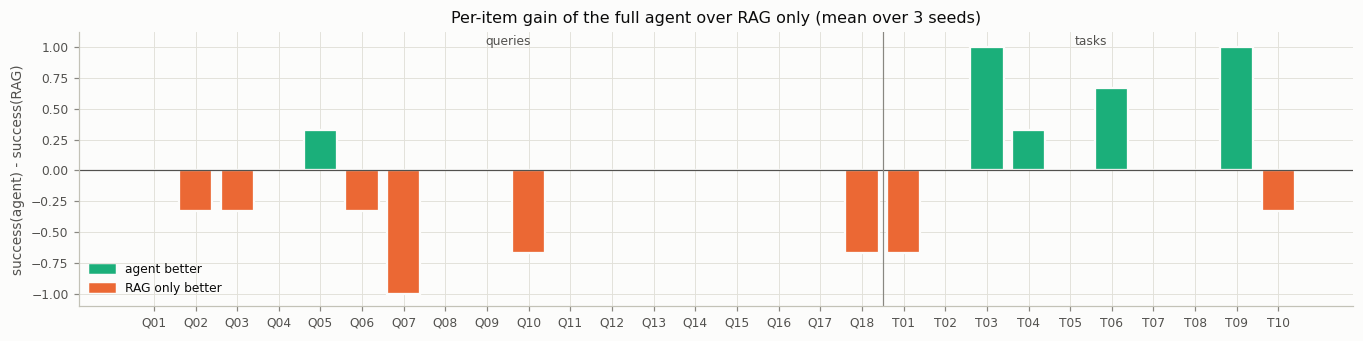

In [ ]:
items = [q["id"] for q in QUERIES] + [t["id"] for t in TASKS]
delta = pd.DataFrame([dict(item=i, kind=("task" if i.startswith("T") else "query"), llm_only=item_rate("llm_only", i), rag=item_rate("rag", i), agent=item_rate("agent_fc", i)) for i in items]).set_index("item")
delta["agent_minus_rag"] = (delta.agent - delta.rag).round(2)
print("agent helped most:"); display(delta.sort_values("agent_minus_rag", ascending=False).head(5))
print("RAG alone was enough and the agent did worse:"); display(delta[delta.agent_minus_rag < 0])
fig, ax = plt.subplots(figsize=(12.5, 3.2))
ax.bar(range(len(delta)), delta.agent_minus_rag, color=[COLOR["agent_fc"] if v > 0 else (COLOR["rag"] if v < 0 else BASE) for v in delta.agent_minus_rag], edgecolor=SURFACE, linewidth=1.5)
ax.set_xticks(range(len(delta)), delta.index, fontsize=8); ax.axhline(0, color=INK2, linewidth=0.8); ax.axvline(len(QUERIES) - 0.5, color=MUTED, linewidth=0.8)
ax.text(len(QUERIES) / 2 - 0.5, 1.02, "queries", ha="center", fontsize=8, color=INK2); ax.text(len(QUERIES) + len(TASKS) / 2 - 0.5, 1.02, "tasks", ha="center", fontsize=8, color=INK2)
ax.set_ylim(-1.1, 1.12); ax.set_ylabel("success(agent) - success(RAG)")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=COLOR["agent_fc"]), plt.Rectangle((0, 0), 1, 1, color=COLOR["rag"])], ["agent better", "RAG only better"], loc="lower left")
ax.set_title(f"Per-item gain of the full agent over RAG only (mean over {len(CFG['seeds'])} seeds)")
finish(fig, "f_agent_vs_rag")
RESULTS["part_f"]["per_item"] = delta.to_dict("index")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>היכן הסוכן השתפר ביותר: במשימות המרשם T03 ו-⁠T09, מאפס ל-⁠3, כי ל-⁠RAG אין מרשם: ב-⁠T03 כתב שאין מידע, וב-⁠T09 ענה 15 מיליון, הקנס הקבוע, בלי המחזור. אחריהן T06, מאפס ל-⁠2, ו-⁠T04 ו-⁠Q05&nbsp;בשליש.</p>
<p>היכן RAG הספיק והסוכן הזיק: 6 שאילתות ו-⁠2 משימות. ההצלבה עם&nbsp;הנכונות:</p>
<ul>
<li>הפסד אמיתי — Q07 ו-⁠Q10: 0 מ-⁠3 נכונות אצל הסוכן מול 3 ב-⁠RAG. במשימות, בלי שופט: ב-⁠T01 פעם לא הגיע לסעיף 99 ופעם חישב 3% ממחזור מומצא, ב-⁠T10 פעם 120&nbsp;חודשים</li>
<li>תלוי-שופט — Q18 ו-⁠Q06: הסוכן תמיד נכון, ולא תמיד אושר. ב-⁠Q03 שניהם שגויים, ובשני seeds של הסוכן באותה שגיאה, 2.8.2027 מסעיף 111. ב-⁠Q02 הפוך: RAG שגוי, והסוכן נכון&nbsp;פעם</li>
<li>הפסד שהשופט לא ראה — Q16: לשופט שניהם 1.0, ובנכונות RAG 3 והסוכן 1. בשני seeds לא מצא סעיף 26 וענה מסעיף 59, על&nbsp;ה-⁠sandbox</li>
</ul>
<p>התא הבא בודק למה הסוכן חלש מ-⁠RAG בשאלות&nbsp;ישירות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>למה הסוכן חלש מ-⁠RAG בשאלות ישירות: ב-⁠RAG מחפשים עם השאלה עצמה, ואצל הסוכן עם שאילתה שהמודל כתב, כך שמשווים pipelines ולא&nbsp;הסקה.</p>
</div>

agent runs on the queries: 54 | tool calls per run: 1 to 1
runs whose context held every gold document: RAG 42 of 54, agent 39 of 54


,agent_search,gold_found_rag,gold_found_agent,success_rag,success_agent
id,,,,,
Q01,,1.0,1.00,1.00,1.00
Q02,CV screening AI / CV screening,0.5,0.17,0.67,0.33
Q03,obligations general-purpose AI models / obligations general-purpose AI models start apply,0.0,0.00,1.00,0.67
Q04,free and open-source / free and open-source AI models,1.0,1.00,1.00,1.00
Q05,prohibited AI practices,1.0,1.00,0.67,1.00
Q06,maximum administrative fine prohibited AI practice,1.0,1.00,1.00,0.67
Q07,systemic risk training data / systemic risk training compute,1.0,1.00,1.00,0.00
Q08,emotion,1.0,1.00,1.00,1.00
Q09,live facial recognition / live facial recognition public streets,1.0,1.00,1.00,1.00


queries where the agent did worse on average; the passages each system read in seed 1, by legal location, in rank order:
  Q02 | RAG: Art. 6(3), Art. 80(1), Art. 6(1), Art. 6(2), Art. 80(2)
      | agent, query 'CV screening AI': Annex III, point 3, Annex III, point 4, Art. 95(2), Art. 27(5), Art. 60(2)
  Q03 | RAG: Art. 111(3), Art. 111(2), Art. 53(4), Art. 53(1), Art. 55(2)
      | agent, query 'obligations general-purpose AI models': Art. 53(1), Art. 55(1), Art. 53(3), Art. 53(4), Art. 55(2)
  Q06 | RAG: Art. 99(3), Art. 100(2), Art. 100(3), Art. 5(1), Art. 5(1)
      | agent, query 'maximum administrative fine prohibited AI practice': Art. 100(2), Art. 99(3), Art. 100(3), Art. 5(1), Art. 5(1)
  Q07 | RAG: Art. 51(2), Art. 3, Annex XIII, Art. 51(1), Art. 101(1)
      | agent, query 'systemic risk training data': Annex XIII, Art. 56(2), Art. 10(3), Art. 51(2), Art. 55(1)
  Q10 | RAG: Art. 50(1), Art. 3, Art. 50(3), Art. 5(1), Art. 50(4)
      | agent, query 'transparency obligations'

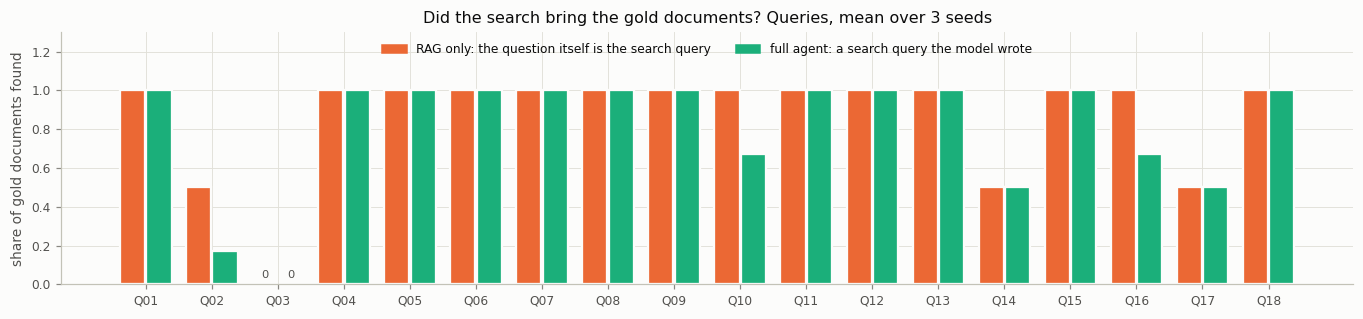

In [ ]:
qs_rows = []
for q in QUERIES:
    gold = set(q["gold"])
    searches = [str(st["args"].get("query") if isinstance(st["args"], dict) else st["args"]) for t in RESULTS["traces"]
                if t["task"] == q["id"] and t["approach"] == "function_calling" for st in t["steps"] if st["tool"] == "search_act"]
    qs_rows.append(dict(id=q["id"], agent_search=" / ".join(dict.fromkeys(searches)),
                        gold_found_rag=float(np.mean([len(gold & set(RUNS["rag"][rkey(q["id"], s)]["retrieved"])) / len(gold) for s in CFG["seeds"]])),
                        gold_found_agent=float(np.mean([len(gold & set(RUNS["agent_fc"][rkey(q["id"], s)]["retrieved"])) / len(gold) for s in CFG["seeds"]])),
                        success_rag=item_rate("rag", q["id"]), success_agent=item_rate("agent_fc", q["id"])))
qsearch = pd.DataFrame(qs_rows).set_index("id").round(2)
n_steps = [len(t["steps"]) for t in RESULTS["traces"] if t["task"] in QIDS and t["approach"] == "function_calling"]
full_gold = {c: sum(set(q["gold"]) <= set(RUNS[c][rkey(q["id"], s)]["retrieved"]) for q in QUERIES for s in CFG["seeds"]) for c in ("rag", "agent_fc")}
print(f"agent runs on the queries: {len(n_steps)} | tool calls per run: {min(n_steps)} to {max(n_steps)}")
print(f"runs whose context held every gold document: RAG {full_gold['rag']} of {len(B_KEYS)}, agent {full_gold['agent_fc']} of {len(B_KEYS)}")
display(qsearch)
loc_re = re.compile(r"\[(?:art|anx)-[^\]|]+\| ([^\]]+)\]")
s0 = CFG["seeds"][0]
short = lambda m: m.replace(" AI Act", "").split(",")[0] if m.startswith("Annex") and ", point" not in m else m.replace(" AI Act", "")
worse = [q for q in qsearch.index if qsearch.loc[q, "success_agent"] < qsearch.loc[q, "success_rag"] or qsearch.loc[q, "gold_found_agent"] < qsearch.loc[q, "gold_found_rag"]]
print(f"queries where the agent did worse on average; the passages each system read in seed {s0}, by legal location, in rank order:")
for q in worse:
    tr = next(t for t in RESULTS["traces"] if t["task"] == q and t["approach"] == "function_calling" and t["seed"] == s0)
    agent_locs = [short(m) for st in tr["steps"] for m in loc_re.findall(st.get("result") or "")]
    rag_locs = [short(m) for e in RUNS["rag"][rkey(q, s0)]["evidence"] for m in loc_re.findall(e)]
    print(f"  {q} | RAG: {', '.join(rag_locs)}")
    print(f"      | agent, query '{qsearch.loc[q, 'agent_search'].split(' / ')[0]}': {', '.join(agent_locs)}")
fig, ax = plt.subplots(figsize=(12.5, 3.0))
x = np.arange(len(qsearch))
ax.bar(x - 0.2, qsearch.gold_found_rag, width=0.38, color=COLOR["rag"], edgecolor=SURFACE, linewidth=1.5)
ax.bar(x + 0.2, qsearch.gold_found_agent, width=0.38, color=COLOR["agent_fc"], edgecolor=SURFACE, linewidth=1.5)
for x_, a_, b_ in zip(x, qsearch.gold_found_rag, qsearch.gold_found_agent):
    for dx, v in ((-0.2, a_), (0.2, b_)):
        if v == 0:
            ax.text(x_ + dx, 0.02, "0", ha="center", va="bottom", fontsize=7.5, color=INK2)
ax.set_xticks(x, qsearch.index, fontsize=8); ax.set_ylim(0, 1.3); ax.set_ylabel("share of gold documents found")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=COLOR["rag"]), plt.Rectangle((0, 0), 1, 1, color=COLOR["agent_fc"])],
          ["RAG only: the question itself is the search query", "full agent: a search query the model wrote"], loc="upper center", ncol=2)
ax.set_title(f"Did the search bring the gold documents? Queries, mean over {len(CFG['seeds'])} seeds")
finish(fig, "f_agent_search")
RESULTS["part_f"]["agent_search"] = dict(table=qsearch.to_dict("index"), runs_with_all_gold=full_gold, tool_calls_per_run=[min(n_steps), max(n_steps)])

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כל 54 ריצות הסוכן על השאילתות הפעילו כלי אחד: ב-⁠Q01 get_provision לסעיף 3, ובשאר חיפוש, בשאילתה של 1–6 מילים במקום השאלה&nbsp;המלאה.</p>
<ul>
<li>מסמכי זהב בהקשר — RAG ב-⁠42 מ-⁠54, הסוכן ב-⁠39. הפער ב-⁠Q10, שבה חיפש פעם inform, וב-⁠Q16, שבה פעמיים חסר סעיף 26; ב-⁠Q02 גם RAG מצא רק מסמך זהב אחד בכל&nbsp;seed</li>
<li>גם כשהמסמך נמצא, הפסקה לא בהכרח: ב-⁠Q10 seed 1 הסוכן קיבל 50(2)–50(6) בלי 50(1), ו-⁠RAG קיבל אותה&nbsp;ראשונה</li>
<li>ב-⁠Q06 וב-⁠Q18 כמעט אותם קטעים והסוכן צדק: ההפסד בשיפוט, לא בתשובה. ב-⁠Q07 שניהם קראו 51(2), והכשל בהעתקה, 10^24. ב-⁠Q03 לשניהם חסר&nbsp;113</li>
<li>שאילתה משלו יכולה גם לעזור: ב-⁠Q02 seed 1 החיפוש CV screening AI הביא את נספח III נקודה 4, ש-⁠RAG לא&nbsp;הביא</li>
<li>מדידה — ההקשר של RAG הוא 5 קטעים, לא 5 מסמכים: ב-⁠Q14 סעיף 3 בין 4 המסמכים שחלק א׳ מדד אך לא בין 5 הקטעים שהמודל קיבל, ולכן&nbsp;0.5</li>
</ul>
<p>בשאלות ישירות הסוכן מוסיף צעד שבעיקר מזיק: ניסוח לשאילתה קצרה, בלי חיפוש שני. תיקון אפשרי, לא נבדק: חיפוש ראשון בשאלה&nbsp;המקורית.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — חלק ו׳:</p>
<ul>
<li>שורה ראשית — RAG 0.76, סוכן 0.73, LLM 0.25, מ-⁠84 רשומות לתנאי. RAG מול סוכן בתוך הרעש: פער 0–2 מ-⁠28 בכל seed, רווחים&nbsp;חופפים</li>
<li>הסוכן השתפר ביותר במשימות של נתון חיצוני, מרשם או תאריך: T03 ו-⁠T09 ל-⁠3, T06 ל-⁠2; במשימות 0.60 מול 0.40. בחישוב בלבד, T07 ו-⁠T08, אין הבדל. ל-⁠RAG אין מרשם, ולכן נכשל בהן&nbsp;מבנית</li>
<li>בשאלות ישירות RAG הספיק: לפי השופט RAG עדיף ב-⁠6 שאילתות והסוכן באחת, אך בנכונות הסוכן נמוך רק ב-⁠Q07, Q10 ו-⁠Q16, וב-⁠Q06 וב-⁠Q18 הוא דווקא&nbsp;צדק</li>
<li>וכך גם במשימות פשוטות: ב-⁠T01 וב-⁠T10, צעד אחד, RAG 6 מ-⁠6 והסוכן 3 מ-⁠6; ב-⁠T02, צעד אחד, וב-⁠T08, שליפה וחיסור, שניהם 3 מ-⁠3, והסוכן רק הוסיף&nbsp;עלות</li>
<li>נכונות בלי שופט (7 שאילתות) — RAG 14 מתוך 21, סוכן 8, LLM בלבד 2. הדירוג מחזיק, הפער 6 תשובות, רווחים חופפים</li>
<li>עלות — על כל הפריטים פי 3.4 בפרומפט, פי 1.8 ביצירה, פי 1.7 בזמן; בשאילתות פי 2.5, 1.4 ו-⁠1.4, בלי תמורה. RAG שולט בחזית איכות-עלות; הסוכן משתלם רק במשימות</li>
</ul>
<p>שכבת הסוכן משתלמת רק כשהשאלה דורשת מה שהאחזור לא נותן: נתון חיצוני, כמו מרשם או תאריך. בין&nbsp;pipelines, חלק מההפסד בניסוח השאילתה, לא בהסקה. מה לא ניתן להסיק: 28 פריטים ו-⁠3 seeds; הצלחה בשאילתות תלויה בשופט; נכונות נבדקה ב-⁠7 שאילתות; הסוכן ב-⁠function&nbsp;calling.</p>
</div>

In [ ]:
checkpoint("Part F")

[checkpoint after Part F] /content/drive/MyDrive/FM/Final_Project/outputs/project_results.json (1.88 MB) | cache hits 3, misses 944


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בונוס — dense מול BM25 מול hybrid, וההשפעה במורד הזרם</p>
<ul>
<li>תנאי RAG בלבד של חלק ו׳, עם מועמדים מ-⁠embeddings או מ-⁠BM25, עם reranking, מול hybrid; שלושה seeds, כנדרש&nbsp;בהנחיות</li>
<li>לכל שיטה: מדדי האחזור מחלק א׳, הצלחה כוללת ולפי seed, שיעור הזיה וחלק הטענות&nbsp;הלא-נתמכות</li>
<li>השאלה: האם שיפור באחזור מתורגם ל-⁠groundedness של&nbsp;התשובה</li>
</ul>
</div>

Loading weights:   0%|          | 0/243 [00:00<?, ?it/s]

,p_at_5,r_at_5,ndcg_at_5,recall_cand,success_rate,hallucination_rate,unsupported_claim_share,n,mrr
mode,,,,,,,,,
hybrid,0.217,0.889,0.897,0.917,0.76 [0.66-0.84],0.20 [0.13-0.30],0.121,84,0.944
dense,0.203,0.861,0.859,0.889,0.75 [0.65-0.83],0.24 [0.16-0.34],0.120,84,0.917
bm25,0.211,0.889,0.869,0.917,0.73 [0.62-0.81],0.20 [0.13-0.30],0.108,84,0.907


success rate per seed


,seed 1,seed 2,seed 3,min,max
hybrid,0.750,0.786,0.750,0.750,0.786
dense,0.714,0.786,0.750,0.714,0.786
bm25,0.714,0.750,0.714,0.714,0.750


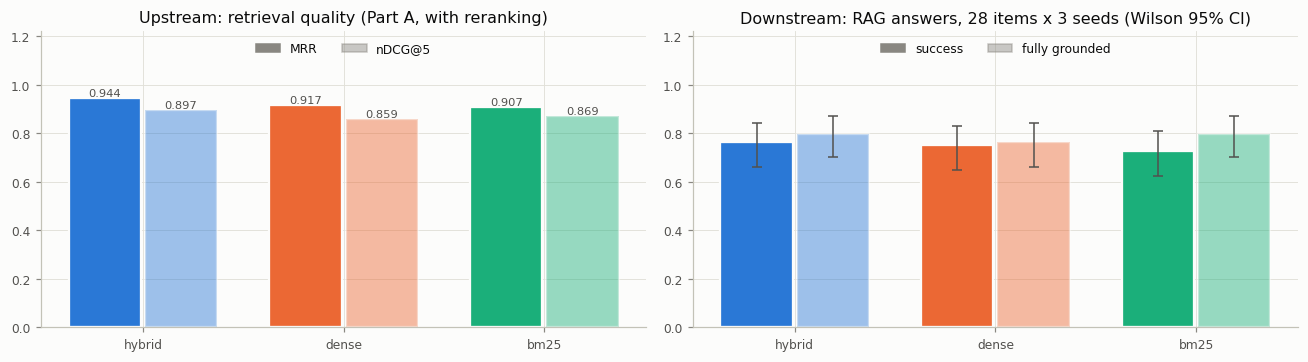

In [ ]:
seed0 = CFG["seeds"][0]
KEYS0 = [k for k in ALL_KEYS if k.endswith(f"|s{seed0}")]
for mode in ("dense", "bm25"):
    cond = f"rag_{mode}"
    for k in ALL_KEYS:
        item_id = k.split("|")[0]
        RUNS[cond][k] = answer_rag(ITEM_TEXT[item_id], int(k.split("|s")[1]), mode=mode)
        if item_id in TASK_BY_ID:
            RUNS[cond][k]["success"] = bool(TASK_BY_ID[item_id]["check"](RUNS[cond][k]["answer"]))
    judge_runs(cond, ALL_KEYS, "BONUS")
    for k in ALL_KEYS:
        if k.split("|")[0] not in TASK_BY_ID:
            RUNS[cond][k]["success"] = RUNS[cond][k]["judge"]["verdict"] == "GROUNDED" and RUNS[cond][k]["judge"]["answers_question"]
free_judge()
bonus_rows = []
for mode, cond in (("hybrid", "rag"), ("dense", "rag_dense"), ("bm25", "rag_bm25")):
    ret = RESULTS["retrieval"]["conditions"][f"structural/{mode}/rerank"]
    st = cond_stats(cond, ALL_KEYS)
    bonus_rows.append(dict(mode=mode, p_at_5=ret["p_at_5"], r_at_5=ret["r_at_5"], ndcg_at_5=ret["ndcg_at_5"], recall_cand=ret["recall_cand"],
                           success_rate=st["success_rate"], hallucination_rate=st["hallucination_rate"], unsupported_claim_share=st["unsupported_claim_share"], n=st["n"]))
bonus_tab = pd.DataFrame(bonus_rows).set_index("mode")
bonus_tab["mrr"] = [RESULTS["retrieval"]["conditions"][f"structural/{m}/rerank"]["mrr"] for m in bonus_tab.index]
display(bonus_tab.assign(success_rate=bonus_tab.success_rate.map(ci_text), hallucination_rate=bonus_tab.hallucination_rate.map(ci_text)))
bonus_seeds = pd.DataFrame({f"seed {s}": {m: cond_stats(c, [k for k in ALL_KEYS if k.endswith(f"|s{s}")])["success_rate"][0] for m, c in (("hybrid", "rag"), ("dense", "rag_dense"), ("bm25", "rag_bm25"))}
                            for s in CFG["seeds"]})
bonus_seeds["min"], bonus_seeds["max"] = bonus_seeds.min(axis=1), bonus_seeds.max(axis=1)
print("success rate per seed"); display(bonus_seeds.round(3))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
x = np.arange(len(bonus_tab))
mcols = [COLOR[m] for m in bonus_tab.index]
ax[0].bar(x - 0.19, bonus_tab.mrr, width=0.36, color=mcols, edgecolor=SURFACE, linewidth=1.5)
ax[0].bar(x + 0.19, bonus_tab.ndcg_at_5, width=0.36, color=mcols, alpha=0.45, edgecolor=SURFACE, linewidth=1.5)
for x_, (m_, n_) in enumerate(zip(bonus_tab.mrr, bonus_tab.ndcg_at_5)):
    ax[0].text(x_ - 0.19, m_, f"{m_:.3f}", ha="center", va="bottom", fontsize=7.5, color=INK2)
    ax[0].text(x_ + 0.19, n_, f"{n_:.3f}", ha="center", va="bottom", fontsize=7.5, color=INK2)
ax[0].set_xticks(x, bonus_tab.index); ax[0].set_ylim(0, 1.22); ax[0].set_title("Upstream: retrieval quality (Part A, with reranking)")
ax[0].legend([plt.Rectangle((0, 0), 1, 1, color=MUTED), plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.45)], ["MRR", "nDCG@5"], loc="upper center", ncol=2)
bars_ci(ax[1], x - 0.19, list(bonus_tab.success_rate), mcols)
bars_ci(ax[1], x + 0.19, [(1 - r[0], 1 - r[2], 1 - r[1]) for r in bonus_tab.hallucination_rate], mcols, alpha=0.45)
ax[1].set_xticks(x, bonus_tab.index); ax[1].set_ylim(0, 1.22)
ax[1].legend([plt.Rectangle((0, 0), 1, 1, color=MUTED), plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.45)], ["success", "fully grounded"], loc="upper center", ncol=2)
ax[1].set_title(f"Downstream: RAG answers, {len(QUERIES) + len(TASKS)} items x {len(CFG['seeds'])} seeds (Wilson 95% CI)")
finish(fig, "bonus_retrieval_downstream")
RESULTS["bonus"] = bonus_tab.astype(str).to_dict("index")
RESULTS["bonus_per_seed"] = bonus_seeds.round(3).to_dict()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלוש שיטות מועמדים עם reranking, 84 תשובות לשיטה:</p>
<ul>
<li>אחזור — hybrid MRR 0.944, nDCG@5 0.897; dense 0.917, 0.859; BM25 0.907, 0.869. פערים 0.03–0.04</li>
<li>הצלחה — hybrid 0.76 (0.66–0.84), dense 0.75 (0.65–0.83), BM25 0.73 (0.62–0.81): 64, 63 ו-⁠61 מ-⁠84. בסדר של MRR, פער 3&nbsp;תשובות</li>
<li>לא מבוססות במלואן — hybrid ו-⁠BM25 0.20, dense 0.24. טענות לא-נתמכות: ב-⁠BM25 0.108, ב-⁠dense 0.120, ב-⁠hybrid 0.121</li>
<li>לפי seed — hybrid לא נמוך מהאחרות באף seed; dense נמוך ב-⁠seed 1 ושווה בשאר; BM25 נמוך בתשובה אחת בכל seed, 3 בסך&nbsp;הכל</li>
</ul>
<p>כל הרווחים חופפים כמעט לגמרי.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ממצאים ומסקנות — הבונוס:</p>
<ul>
<li>שיפור באחזור לא מתורגם ל-⁠groundedness באופן מדיד: הצלחה 0.76 ב-⁠hybrid מול 0.75 ו-⁠0.73 בחפיפה; מבוססות ב-⁠hybrid וב-⁠BM25&nbsp;0.80</li>
<li>הסבר אפשרי: אחרי reranking recall@5 לכולן 0.86–0.89, ו-⁠Q03 קשה לכולן. ההבדלים בסדר בתוך החמישייה, והמודל קורא את&nbsp;כולה</li>
<li>הסבר אפשרי לכוחו של BM25 בטקסט משפטי: מספרי סעיפים וניסוח חוזר; ב-⁠provider (Q01) הוא נכשל בשלושה מארבעת תנאי חלק א׳, אך לא בתנאי של&nbsp;הבונוס</li>
<li>יציבות: hybrid אינו נמוך מהאחרות באף seed, ו-⁠BM25 נמוך בתשובה בכל seed, כיוון עקבי וקטן&nbsp;מהרעש</li>
</ul>
<p>סביר להעדיף hybrid, אבל BM25 עם reranking כמעט שקול וזול. מה לא ניתן להסיק: תשובה שווה 1.2 נקודות אחוז, ו-⁠3 תשובות הן&nbsp;רעש.</p>
</div>

In [ ]:
checkpoint("Bonus")

[checkpoint after Bonus] /content/drive/MyDrive/FM/Final_Project/outputs/project_results.json (2.04 MB) | cache hits 135, misses 1148


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סינתזה מסכמת — פרופיל סוכן</p>
<ul>
<li>טבלה מסכמת: LLM בלבד, RAG בלבד וסוכן מלא מול הצלחה, שיעור הזיה ויעילות, על 28 הפריטים ושלושה&nbsp;seeds</li>
<li>פילוח כשלי הסוכן לפי הטקסונומיה מחלק ד׳: אילו סוגי כשל היו הדומיננטיים,&nbsp;ולמה</li>
<li>מה השתפר בוודאות סבירה, כלומר נתמך במדידה שאינה עוברת דרך השופט ומחזיק בכל ה-⁠seeds, ומה תלוי-שופט ולכן פחות&nbsp;ודאי</li>
<li>המלצה מנומקת: מתי RAG בלבד ומתי סוכן מלא עם כלים בסביבת&nbsp;production</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הטבלה ופילוח הכשלים מחושבים מהחלקים הקודמים, לא מוקלדים. הגרף הוא פרופיל הסוכן: הצלחה ומבוססות, מחיר לפריט, והיכן הוא&nbsp;נשבר.</p>
</div>

,n,success,success_rate,hallucination_rate,unsupported_claim_share,llm_calls,tool_calls,prompt_tokens,gen_tokens,seconds
LLM only,84,21,"(0.25, 0.17, 0.352)","(0.714, 0.61, 0.8)",0.361,1.00,0.00,133.0,49.0,2.64
RAG only (hybrid + rerank),84,64,"(0.762, 0.661, 0.84)","(0.202, 0.13, 0.3)",0.121,1.00,0.00,1035.0,104.0,6.53
"full agent (RAG + tools, function calling)",84,61,"(0.726, 0.623, 0.81)","(0.321, 0.231, 0.427)",0.125,2.37,1.52,3474.0,192.0,11.25


approach,function_calling,react
final,,
tool_prediction/no_tool,0.00,0.00
tool_prediction/hallucinated_tool,0.00,0.00
tool_prediction/wrong_tool,0.17,0.59
tool_prediction/wrong_argument,0.58,0.29
tool_call/wrong_response,0.25,0.00
tool_call/no_response,0.00,0.00
response_generation/wrong_response,0.00,0.12


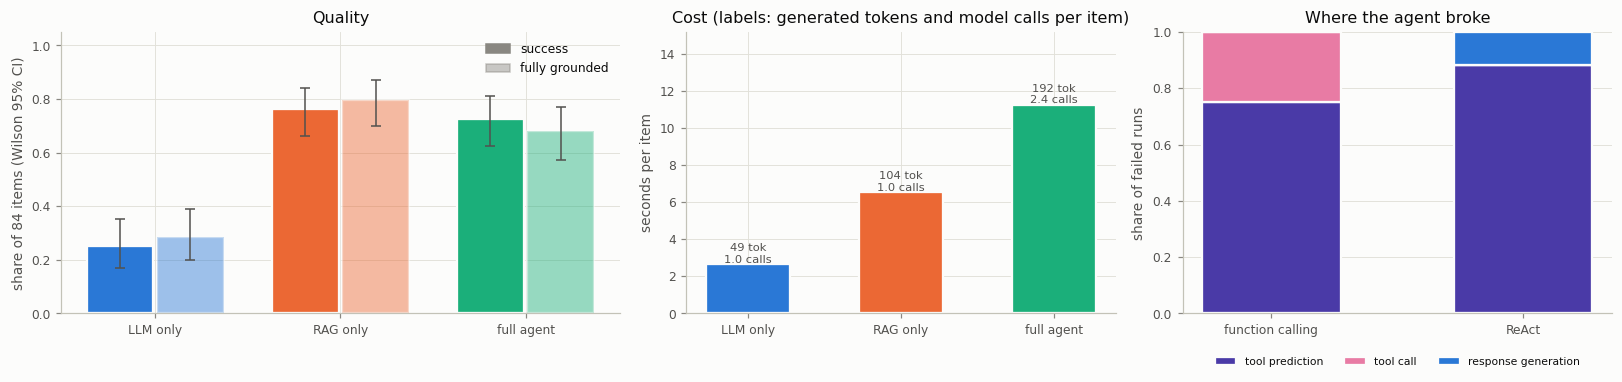

In [ ]:
synth = abl_all[["n", "success", "success_rate", "hallucination_rate", "unsupported_claim_share", "llm_calls", "tool_calls", "prompt_tokens", "gen_tokens", "seconds"]].copy()
synth.index = ["LLM only", "RAG only (hybrid + rerank)", "full agent (RAG + tools, function calling)"]
display(synth)
fail_share = (freq.drop(index="success") / freq.drop(index="success").sum()).round(2)
display(fail_share)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6), gridspec_kw=dict(width_ratios=[1.3, 1, 1]))
x = np.arange(len(CONDS))
bars_ci(ax[0], x - 0.19, [abl_all.loc[c, "success_rate"] for c in CONDS], [COLOR[c] for c in CONDS])
bars_ci(ax[0], x + 0.19, [(1 - abl_all.loc[c, "hallucination_rate"][0], 1 - abl_all.loc[c, "hallucination_rate"][2], 1 - abl_all.loc[c, "hallucination_rate"][1]) for c in CONDS],
        [COLOR[c] for c in CONDS], alpha=0.45)
ax[0].set_xticks(x, [COND_NAME[c] for c in CONDS]); ax[0].set_ylim(0, 1.05); ax[0].set_ylabel(f"share of {int(abl_all.n.iloc[0])} items (Wilson 95% CI)")
ax[0].legend([plt.Rectangle((0, 0), 1, 1, color=MUTED), plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.45)], ["success", "fully grounded"], loc="upper right")
ax[0].set_title("Quality")
ax[1].bar(x, [abl_all.loc[c, "seconds"] for c in CONDS], color=[COLOR[c] for c in CONDS], edgecolor=SURFACE, linewidth=1.5, width=0.55)
for x_, c in enumerate(CONDS):
    ax[1].text(x_, abl_all.loc[c, "seconds"], f"{abl_all.loc[c, 'gen_tokens']:.0f} tok{chr(10)}{abl_all.loc[c, 'llm_calls']:.1f} calls", ha="center", va="bottom", fontsize=7.5, color=INK2)
ax[1].set_xticks(x, [COND_NAME[c] for c in CONDS]); ax[1].set_ylabel("seconds per item"); ax[1].set_ylim(0, max(abl_all.seconds) * 1.35)
ax[1].set_title("Cost (labels: generated tokens and model calls per item)")
levels = ["tool_prediction", "tool_call", "response_generation"]
lv = lab_df[lab_df.final != "success"].assign(level=lambda d: d.final.str.split("/").str[0]).pivot_table(index="level", columns="approach", values="key", aggfunc="count").reindex(levels).fillna(0)
lv = (lv / lv.sum()).fillna(0)
bottom = np.zeros(lv.shape[1])
for lev, col in zip(levels, (PAL[6], PAL[4], PAL[0])):
    ax[2].bar(range(lv.shape[1]), lv.loc[lev].values, bottom=bottom, color=col, label=lev.replace("_", " "), edgecolor=SURFACE, linewidth=1.5, width=0.55)
    bottom += lv.loc[lev].values
ax[2].set_xticks(range(lv.shape[1]), ["function calling" if a == "function_calling" else "ReAct" for a in lv.columns]); ax[2].set_ylim(0, 1)
ax[2].set_ylabel("share of failed runs"); ax[2].set_title("Where the agent broke"); ax[2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=7)
finish(fig, "synthesis_agent_profile")
RESULTS["synthesis"] = dict(table=synth.astype(str).to_dict("index"), failure_share=fail_share.to_dict())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הטבלה חוזרת על השורה הראשית של חלק ו׳. בגרפים:</p>
<ul>
<li>איכות — RAG מוביל בהצלחה ובמבוססות, 0.76 ו-⁠0.80. אצל הסוכן המבוססות, 0.68, נמוכה מההצלחה, 0.73: הראיות מציגות את פלטי הכלים כמספרים חשופים, והשופט מחמיר&nbsp;איתם</li>
<li>עלות — הסוכן 11.3 שניות, 192 טוקנים שנוצרו ו-⁠2.4 קריאות לפריט, מול 6.5, 104 ו-⁠1.0 ב-⁠RAG: כמעט כפול, בלי תמורה בהצלחה הכוללת; התמורה רק&nbsp;במשימות</li>
<li>היכן נשבר, לפי התיוג הידני — ב-⁠function calling בחיזוי כלי ובקריאה לכלי, 9 ו-⁠3 מ-⁠12; ב-⁠ReAct מוקדם, 15 מ-⁠17 בחיזוי כלי, 10 מהם&nbsp;wrong_tool</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פרופיל סוכן — עמוד הסיכום</p>
<table>
<tr><th>תנאי</th><th>הצלחה, כל הפריטים</th><th>משימות</th><th>שאילתות</th><th>נכונות, 7 שאילתות</th><th>לא מבוססות במלואן</th><th>קריאות למודל / לכלים</th><th>טוקנים שנוצרו</th><th>שניות לפריט</th></tr>
<tr><td>LLM בלבד</td><td>0.25 (0.17–0.35)</td><td>0.00 (0.00–0.11)</td><td>0.39 (0.27–0.52)</td><td>2/21</td><td>0.71</td><td>1 / 0</td><td>49</td><td>2.64</td></tr>
<tr><td>RAG בלבד</td><td>0.76 (0.66–0.84)</td><td>0.40 (0.25–0.58)</td><td>0.96 (0.88–0.99)</td><td>14/21</td><td>0.20</td><td>1 / 0</td><td>104</td><td>6.53</td></tr>
<tr><td>סוכן מלא</td><td>0.73 (0.62–0.81)</td><td>0.60 (0.42–0.75)</td><td>0.80 (0.67–0.88)</td><td>8/21</td><td>0.32</td><td>2.37 / 1.52</td><td>192</td><td>11.25</td></tr>
</table>
<p>גודל המדגם: 84 רשומות לתנאי (28 פריטים × 3 seeds), 30 ריצות משימות, 54 ריצות שאילתות, 21 תשובות בבדיקת הנכונות.</p>
<p>פילוח כשלי הסוכן (חלק ד׳, תיוג ידני של 29 הריצות הכושלות):</p>
<ul>
<li>ב-⁠function calling, 12 מ-⁠30: 9 בחיזוי כלי, 7 מהם ארגומנט שגוי, כולל נוסחה שגויה במחשבון; 3 בקריאה לכלי, כולם T07, נספח XIII במקום סעיף 51; אפס ביצירת&nbsp;תשובה</li>
<li>ב-⁠ReAct, 17 מ-⁠30: 15 בחיזוי כלי, 10 מהם wrong_tool, בעיקר דילוג על שליפת הסעיף. הסבר אפשרי: הנחיית ReAct אינה אומרת מתי לפנות לכלי, וחופש הפורמט מסביר רק את הסכמות&nbsp;השגויות</li>
<li>משותף: הקושי אינו רק אורך השרשרת אלא בחירת הסעיף ויישומו. T05 ו-⁠T07 נכשלו ב-⁠6 מתוך&nbsp;6</li>
</ul>
<p>מה השתפר בוודאות סבירה (נמדד בלי שופט, מחזיק בכל seed):</p>
<ul>
<li>מול LLM בלבד — RAG בנכונות 14 מול 2 מתוך 21 ובמשימות 12 מול 0 מתוך 30, הסוכן במשימות 18 מול 0. רווחים לא&nbsp;חופפים</li>
<li>סוכן מול RAG בארבע משימות המרשם (T03, T04, T05, T09) — 7 מול 0 מתוך 12, ו-⁠T03 ו-⁠T09 בכל seed; 3 מההצלחות בלי שרשור תקין. הבדל מבני: ל-⁠RAG אין&nbsp;מרשם</li>
</ul>
<p>מה תלוי-שופט או בתוך הרעש, ולכן פחות ודאי:</p>
<ul>
<li>בשאילתות, RAG מול סוכן 0.96 מול 0.80; גם הנכונות, 14 מול 8, ברווחים חופפים, ובשתי שאילתות השופט לא אישר תשובות&nbsp;נכונות</li>
<li>מול תיוג ידני קאפא 0.40, n=24; השופט מחמיר עם תשובות סוכן נכונות שהמספר בהן מחושב, כי הראיות מציגות אותו כמספר&nbsp;חשוף</li>
<li>21 ה-⁠GROUNDED מתוך 54 של LLM בלבד — גבול עליון, השופט מקל: 30 מיליון ב-⁠Q06 קיבל GROUNDED, ובתיוג הידני&nbsp;NOT_GROUNDED</li>
<li>סוכן מול RAG על כל הפריטים, 0.73 מול 0.76 — בתוך&nbsp;הרעש</li>
</ul>
<p>המלצה ל-⁠production, במסגרת מה שהניסוי הזה מראה:</p>
<ul>
<li>לשאלות שהתשובה להן בקורפוס — RAG עם hybrid ו-⁠reranking. הוא המבוסס ביותר, זול פי 1.7 בזמן, ולא תלוי בניסוח מחדש של&nbsp;השאלה</li>
<li>סוכן עם כלים כשנדרש נתון חיצוני, כמו מרשם או תאריך; בחישוב בלבד לא נמצא יתרון. ניתוב לפי סימנים בשאלה: שם חברה, מספרים, מילות&nbsp;זמן</li>
<li>בתוך הסוכן — function calling, חיפוש ראשון בשאלה המקורית, בדיקה ששורת ANSWER תואמת לטקסט, וחובת שליפת סעיף לפני חישוב (תיקונים שלא נבדקו&nbsp;בניסוי)</li>
<li>שופט groundedness כבקרה מצרפית ולא לתשובה בודדת, לצד בדיקות נכונות מבוססות-כללים, ועם פלטי כלים מסומנים כראיות&nbsp;מלאות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מגבלות מתודולוגיות:</p>
<ul>
<li>הצלחת השאילתות בחלק ו׳ נמדדת בפסק השופט; במשימות בבדיקה אוטומטית מול ערך שנרשם&nbsp;מראש</li>
<li>השופט אינו מתייג כשלים בחלק ד׳, ולכן אין מעגליות. התיוג הידני בחלקים א׳, ד׳ ו-ה׳ בידי מחבר הפרויקט בלבד, בלי מדידת&nbsp;הסכמה</li>
<li>מדגמים קטנים: 18 שאילתות, 10 משימות, 3 seeds, 24 פריטים בהשוואה לשופט. רווחי Wilson בכל מקום; רווחים חופפים אינם קובעים&nbsp;הבדל</li>
<li>הסוכן והשופט ב-⁠NF4 בלי אימון. במטלה 1 הכימות הוריד פריט הסקה אחד מ-⁠24 ב-⁠Qwen2.5-3B; חלק מכשלי ההסקה עשויים לנבוע&nbsp;ממנו</li>
<li>המודל ראה כנראה טיוטות של החוק באימון; בחלק ב׳ הוא נותן ב-⁠closed-book סכומים מהצעת&nbsp;2021</li>
<li>המרשם מדומה, ורק לסוכן יש גישה אליו; משימות המרשם בודקות שרשור כלים, לא ידע עולם, ויתרון הסוכן בהן&nbsp;מבני</li>
<li>הכלי get_provision מחזיר עד 9,000 תווים; סעיף ארוך יותר נחתך, כמו סעיף 5 ב-⁠T01. מקור אפשרי ל-⁠wrong_response שלא באשמת&nbsp;המודל</li>
<li>השופט רואה עד 8 קטעים, ופסקיו תלויים בבחירתם: ב-⁠function calling, פיצול הסעיפים הוריד NOT_GROUNDED מ-⁠12 בהרצה מוקדמת&nbsp;ל-⁠5</li>
<li>תבנית השופט מגבילה ל-⁠6 טענות, והתקרה פעילה ב-⁠172 מ-⁠502 פסקים, 21 מהם אף חרגו ממנה, ברוב התשובות הארוכות: חלק הטענות הלא-נתמכות הוא חסם תחתון, וזה ככל הנראה הפספוס היחיד בבדיקת&nbsp;הריפוד</li>
<li>ההקשר של RAG הוא 5 קטעים, ומדדי חלק א׳ על 5 מסמכים אחרי הסרת כפילויות, ולכן recall@5 יכול לעלות על מה שהמודל ראה&nbsp;(Q14)</li>
<li>בשאילתות הסוכן כותב שאילתת חיפוש משלו ומבצע קריאת כלי אחת; ההשוואה ל-⁠RAG היא בין pipelines שלמים, והסוכן נבדק כפי&nbsp;שהוא</li>
<li>ה-⁠function calling רץ בתבנית הרשמית של Qwen, לא דרך API של ספק; ההנחיות מתירות מודלים מקומיים, והמחברת תומכת גם&nbsp;ב-⁠API</li>
<li>ציון groundedness אינו נכונות; בדיקת הנכונות מכסה 7 מתוך 18&nbsp;שאילתות</li>
<li>בדיקות המשימות מחפשות תת-מחרוזת ואינן מזהות שלילה: ב-⁠T03 FC seed 2 התשובה נטתה ל-⁠low-risk ונספרה כהצלחה, ולכן ב-⁠T03 ב-⁠function calling 2 מ-⁠3 בקריאה&nbsp;מחמירה</li>
<li>הפרומפט של function calling אומר מתי לפנות לכלי, ושל ReAct לא; חלק מפער ה-⁠wrong_tool עשוי לנבוע מההנחיה החסרה ולא מחופש&nbsp;הפורמט</li>
<li>דוגמאות בתיאורי הכלים חופפות למשימות: Annex III point 4 (T02–T03), נוסחת max עם מחזור של 2 מיליארד (T04) והתאריך 2027-08-02 (T06). T04 הצליחה 2 מ-⁠6, וב-⁠T08 ReAct s3 ההעתקה&nbsp;הזיקה</li>
<li>פלט המחשבון נכנס לראיות השופט כמספר חשוף, בלי שם הכלי והביטוי; 4 מ-⁠8 אי-ההסכמות בחלק ה׳ הן תשובות סוכן&nbsp;כאלה</li>
<li>שינויים אחרי הרצה מקדימה על אותן משימות: פלט כלי מ-⁠1,500 ל-⁠9,000 תווים, תחביר תאריכים במחשבון, פיצול ראיות לשופט; כולם לטובת הסוכן, ומסומנים בתאים&nbsp;הרלוונטיים</li>
<li>מדגם התיוג של חלק ה׳: 8 closed-book, 8 RAG, 7 function calling ו-⁠ReAct אחד; מתייג&nbsp;יחיד</li>
<li>הקורפוס הוא נוסח תקנה 2024/1689 כפי שפורסם; הנכונות נמדדת מולו, לא מול תיקונים&nbsp;מאוחרים</li>
</ul>
<p>סימון: שורות עם מספרים הן תוצאות; "הסבר אפשרי" ו"כנראה" מסמנים פרשנות; "מה לא ניתן להסיק" מגדיר את גבול&nbsp;המסקנה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום:</p>
<ul>
<li>אחזור — reranking הוא הגורם החזק בדירוג: MRR עלה בכל הצירופים, בממוצע 0.13, ו-⁠chunking רק ב-⁠0.035. הכשל היחיד, Q03: אוצר&nbsp;מילים</li>
<li>יצירה — RAG העלה GROUNDED מ-⁠21 ל-⁠52 מתוך 54 ונכונות מ-⁠2 ל-⁠14 מתוך 21. הזיות closed-book במספרים, חלקן מהצעת&nbsp;2021</li>
<li>סוכן — function calling 18, ReAct 13 מ-⁠30, בלי הכרעה; הראשון מהיר פי 2.3, בלי שגיאות. הקושי בבחירת הסעיף וביישומו, לא רק&nbsp;באורך</li>
<li>כשלי סוכן — ב-⁠ReAct 15 מ-⁠17 בחיזוי כלי, בעיקר דילוג על שלב; ב-⁠function calling 9 ו-⁠3 מתוך 12, בלי כשלי יצירת תשובה. התיוג הידני תיקן 11 מ-⁠29&nbsp;תיוגים</li>
<li>שופט — קאפא 0.66 בין סדרי ראיות ו-⁠0.40 מול תיוג ידני (n=24), תפס 19 מ-⁠20 מרופדות; מקל עם closed-book, מחמיר עם מספרים מחושבים; בהיפוך הסדר 21 עלו ו-⁠10&nbsp;ירדו</li>
<li>אבלציה — RAG 0.76, סוכן 0.73, LLM בלבד 0.25. הסוכן מוביל במשימות (0.60 מול 0.40), RAG בשאילתות (0.96 מול 0.80), חלקית&nbsp;מהחיפוש</li>
<li>בונוס — שיפור קטן באחזור לא עבר ל-⁠groundedness באופן&nbsp;מדיד</li>
</ul>
<p>בניסוי, רוב הערך מגיע מאחזור טוב ולא משכבת הסוכן, שמשתלמת רק כשנדרש נתון חיצוני, כמו מרשם או תאריך. המסקנות נבדקו גם בלי&nbsp;שופט.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נספח פלטים גולמיים: 114 עקבות סוכן, 60 מהן לתיוג חלק ד׳, ותשובות התנאים ב-⁠seed הראשון עם פסק השופט, מקוצרות; המלא בקובץ&nbsp;התוצאות.</p>
</div>

In [ ]:
print("=" * 110)
print("AGENT TRACES")
for tr in RESULTS["traces"]:
    print_trace(tr)
print("=" * 110)
print("ANSWERS BY CONDITION, first seed")
for k in KEYS0:
    print(f"\n##### {k}: {ITEM_TEXT[k.split('|')[0]]}")
    for c in CONDS:
        r = RUNS[c][k]
        print(f"[{c}] verdict={r['judge']['verdict']} success={r.get('success')} | {(r['answer'] or '(empty)')[:500]}")
        print(f"      judge: {r['judge']['rationale'][:220]}")

AGENT TRACES
### T01 | function_calling | seed 1 | llm calls 6 | tool calls 6 | 19947+722 tokens | 44.57s | exhausted=False
   -> get_provision({"reference": "Article 5"}) ok=True  | '[art-5 | Article 5 — Prohibited AI practices] Article 5 — Prohibited AI practices\n\n1. The following AI practices shall be prohibit'
   -> get_provision({"reference": "Article 17(1)"}) ok=True  | '[art-17 | Art. 17(1) AI Act] Providers of high-risk AI systems shall put a quality management system in place that ensures complia'
   -> get_provision({"reference": "Article 18"}) ok=True  | '[art-18 | Article 18 — Documentation keeping] Article 18 — Documentation keeping\n\n1. The provider shall, for a period ending 10 ye'
   -> get_provision({"reference": "Article 18(5)"}) ok=True  | '[art-18 | Article 18 — Documentation keeping] Article 18 — Documentation keeping\n\n1. The provider shall, for a period ending 10 ye'
   -> get_provision({"reference": "Article 18(5)"}) ok=True  | '[art-18 | Article 18 — Docume

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שמירת התוצאות: RESULTS עם התשובות, העקבות, הפרומפטים ויומן השופט, ולפניה תקציב החישוב לכל מודל: קריאות, טוקנים&nbsp;ודקות.</p>
</div>

,calls,prompt_tokens,gen_tokens,minutes
model,,,,
Qwen/Qwen2.5-7B-Instruct,579,648107,48662,48.5
microsoft/phi-4,502,697371,125189,94.3


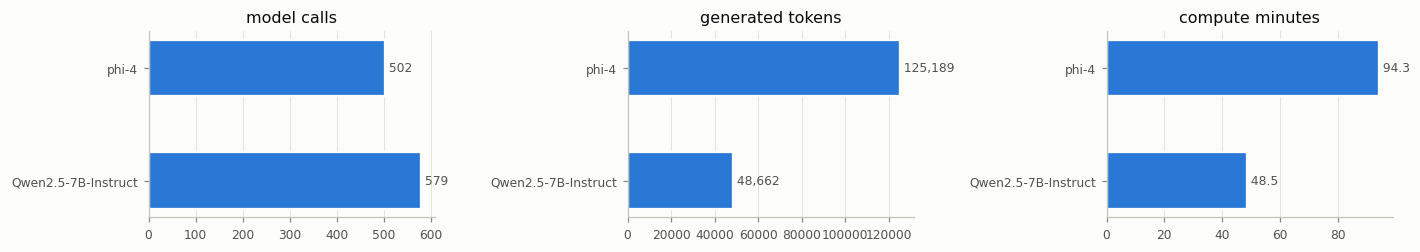

[checkpoint after final] /content/drive/MyDrive/FM/Final_Project/outputs/project_results.json (2.67 MB) | cache hits 135, misses 1148


,value
agent_calls,645
agent_gen_tokens,55885
agent_prompt_tokens,715202
agent_minutes,55.2
cache_hits,135
cache_misses,1148


In [ ]:
RESULTS["runs"] = {c: {k: {f: v for f, v in r.items() if f != "evidence"} for k, r in d.items()} for c, d in RUNS.items()}
RESULTS["queries"] = [dict(id=q["id"], q=q["q"], gold=q["gold"], source=q["source"]) for q in QUERIES]
RESULTS["tasks"] = [dict(id=t["id"], q=t["q"], multi=t["multi"], chain=[sorted(g) for g in t["chain"]], last=t["last"], gold=t["gold"]) for t in TASKS]
RESULTS["judge"] = dict(system=GROUND_SYSTEM, template=GROUND_TEMPLATE, retry=RETRY_SUFFIX, decoding="greedy", max_new=CFG["judge_max_new"],
                        retries_asked=JUDGE_STATE["asked"], retries_recovered=JUDGE_STATE["recovered"])
RESULTS["agent_prompts"] = dict(function_calling=FC_SYSTEM, react=REACT_SYSTEM, answer=ANSWER_SYSTEM, grounded=GROUNDED_SYSTEM)
RESULTS["cost"] = dict(agent_calls=AGENT.calls, agent_gen_tokens=AGENT.gen_tokens, agent_prompt_tokens=AGENT.prompt_tokens, agent_minutes=round(AGENT.seconds / 60, 1),
                       cache_hits=CACHE.hits, cache_misses=CACHE.misses)
budget = pd.DataFrame([dict(model=CACHE.data[k]["request"].get("model", "?"), prompt_tokens=CACHE.data[k]["response"].get("prompt_tokens", 0),
                             gen_tokens=CACHE.data[k]["response"].get("n_tokens", 0), seconds=CACHE.data[k]["response"].get("seconds", 0.0)) for k in CACHE.used])
by_model = budget.groupby("model").agg(calls=("model", "size"), prompt_tokens=("prompt_tokens", "sum"), gen_tokens=("gen_tokens", "sum"), minutes=("seconds", "sum"))
by_model["minutes"] = (by_model.minutes / 60).round(1)
display(by_model)
fig, ax = plt.subplots(1, 3, figsize=(13, 2.4))
for a, col, lab in zip(ax, ("calls", "gen_tokens", "minutes"), ("model calls", "generated tokens", "compute minutes")):
    a.barh(range(len(by_model)), by_model[col], color=PAL[0], edgecolor=SURFACE, linewidth=1.5, height=0.5)
    a.set_yticks(range(len(by_model)), [m.split("/")[-1] for m in by_model.index]); a.grid(axis="y", visible=False)
    for y, v in enumerate(by_model[col]):
        a.text(v, y, f" {v:,.0f}" if col != "minutes" else f" {v:.1f}", va="center", fontsize=8, color=INK2)
    a.set_title(lab)
finish(fig, "compute_budget")
RESULTS["cost"]["by_model"] = by_model.to_dict("index")
checkpoint("final")
display(pd.Series(RESULTS["cost"], name="value").drop("by_model").to_frame())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תקציב החישוב, על L4: סוכן (Qwen2.5-7B) 579 בקשות שונות, 648,107 טוקני פרומפט, 48,662 יצירה, 48.5 דקות. שופט (Phi-4) 502 בקשות שונות, 697,371 פרומפט, 125,189 יצירה, 94.3 דקות: פי 2 בזמן ופי 2.6 ביצירה, כי לכל פסק רשימת טענות ונימוק. הסוכן נקרא 645 פעמים: בטבלה העליונה בקשה זהה נספרת פעם אחת, וה-⁠55.2 בתחתונה סופר כל קריאה. ביומן 1,148 שורות ל-⁠1,081 בקשות שונות, כי בקשות שופט זהות באותו batch נרשמו יותר מפעם אחת: 31 פעמיים ו-⁠18 שלוש&nbsp;פעמים.</p>
</div>